# ECG-Derived Candidate Features Associated With Hemodynamic Instability in ICU Patients: A Patient-Level Exploratory Analysis of Ultra-Short Segments

## Notebook overview

This notebook documents a reproducible exploratory analysis pipeline for identifying ECG-derived candidate features associated with hemodynamic instability (HI) in critically ill ICU patients.

The study uses ultra-short 2-minute ECG segments extracted from a curated cohort of 20 ICU patients. Each patient contributes ECG segments from two broad clinical states:

* **Pre-HI:** ECG segments preceding hemodynamic instability.
* **During-HI:** ECG segments recorded during hemodynamic instability.

The primary objective of this notebook is not to build or validate a predictive model. Instead, the aim is to identify and rank ECG-derived candidate features that show consistent patient-level changes from Pre-HI to During-HI.

This analysis supports the manuscript:

**“ECG-Derived Candidate Features Associated With Hemodynamic Instability in ICU Patients: A Patient-Level Exploratory Analysis of Ultra-Short Segments.”**

---

## Rationale

Continuous ECG monitoring is widely available in ICU patients and may contain physiological information related to evolving hemodynamic instability. However, ECG-derived features can be strongly affected by patient-specific baseline differences, rhythm abnormalities, pacing, conduction disease, medications, signal quality, and clinical heterogeneity.

For this reason, this notebook uses a conservative patient-level analysis framework. The patient, not the ECG segment, is treated as the primary statistical unit.

For each feature, patient-level median values are computed separately for Pre-HI and During-HI segments. The primary comparison is then performed using paired patient-level differences:

**During-HI median − Pre-HI median**

This approach reduces the risk of overinterpreting large numbers of repeated 2-minute ECG windows as independent observations.

---

## Analysis design

The notebook proceeds through the following major steps:

1. **Data loading and integrity checks**
   The processed ECG feature dataset is loaded, and the structure, missingness, class labels, duplicated rows, and feature availability are audited.

2. **Feature definition and feature-family mapping**
   Numeric ECG-derived features are identified, non-informative constant features are removed, and retained features are grouped into families such as morphology, HRV, entropy, fractal, time-domain, spectral, and derived aggregate features.

3. **Clinical and signal-quality annotation**
   Patient-level clinical flags are added for important confounders, including pacing/ICD, atrial fibrillation, bundle branch block, antiarrhythmic exposure, mechanical support, atypical HI, and major HRV outlier behaviour. Segment-level signal-quality and physiological outlier flags are also generated.

4. **Cohort description**
   Patient-level and segment-level summaries are generated to describe Pre-HI and During-HI segment counts, clinical heterogeneity, missingness, and quality flags.

5. **Primary patient-level paired analysis**
   For each informative ECG feature, paired patient-level medians are compared between Pre-HI and During-HI using:

   * Wilcoxon signed-rank test,
   * matched-pairs rank-biserial effect size,
   * bootstrap confidence intervals for the median paired difference,
   * direction consistency across patients,
   * global and feature-family-level FDR correction.

6. **HRV-valid subgroup analysis**
   HRV features are evaluated separately after excluding patients with pacing/ICD, continuous atrial fibrillation, and a major HRV outlier. This analysis is used as the primary physiological interpretation for HRV features.

7. **Supportive mixed-effects modelling**
   Segment-level linear mixed-effects models are fitted as supportive analyses using the model:

   `feature_z ~ Class + (1 | Patient_id)`

   These models account for repeated ECG windows within patients but are not treated as the primary evidence because the cohort contains only 20 patients.

8. **Within-subject redundancy analysis**
   Features are centered within each patient before computing Spearman correlations. This reduces the influence of between-patient baseline differences. Highly correlated features are grouped into redundancy clusters, and representative features are selected for downstream prioritization.

9. **Sensitivity analyses**
   Candidate features are tested under clinically important alternative conditions, including:

   * exclusion of Patient 906,
   * exclusion of atypical HI patients,
   * clean sinus subgroup analysis,
   * signal-quality filtered analysis,
   * leave-one-patient-out analysis,
   * HRV-valid subset analysis,
   * supplementary exclusions for mechanical support, antiarrhythmic exposure, and BBB.

10. **Limited Episode_Label descriptive analysis**
    Detailed HI episode labels are grouped into broad categories and used descriptively only. Episode_Label is not used as a formal model term because later episode groups are sparse and unevenly distributed across patients.

11. **Candidate feature scoring and ranking**
    Evidence across analyses is integrated into a transparent scorecard. Features are categorized as:

    * strict candidates,
    * secondary candidates,
    * or not prioritized.

12. **Publication-ready outputs**
    Final tables, figures, scorecards, and manuscript-facing interpretation summaries are generated for use in the accompanying paper.

---

## Final analysis framing

This notebook should be interpreted as an exploratory feature-discovery analysis.

The results identify ECG-derived candidate features associated with HI, but they do not establish:

* clinical diagnostic validity,
* prospective predictive performance,
* causal physiological mechanisms,
* deployment readiness,
* or generalizability beyond this cohort.

All findings require validation in larger, independent cohorts.

---

## Key final findings

The final scorecard selected six ECG-derived candidate features.

### Strict candidates

| Feature    | Direction during HI | Interpretation                                 |
| ---------- | ------------------- | ---------------------------------------------- |
| `kurtosis` | Increased           | Leading patient-level distributional candidate |
| `QRS_mean` | Increased           | Leading morphology/conduction candidate        |

### Secondary candidates

| Feature                                 | Direction during HI | Interpretation                                |
| --------------------------------------- | ------------------- | --------------------------------------------- |
| `fuzzyEntropy`                          | Decreased           | Representative entropy/complexity candidate   |
| `fd_mean`                               | Decreased           | Fractal-dimension summary candidate           |
| `entropyProfiled_maximum_sampleEntropy` | Decreased           | Derived entropy-profile candidate             |
| `fd_median`                             | Decreased           | Secondary fractal-dimension summary candidate |

The strongest overall evidence was observed for increased `kurtosis` and increased `QRS_mean` during HI.

Entropy and fractal-dimension features provided secondary evidence suggesting reduced ECG signal complexity during HI.

HRV features were not prioritized as final candidate predictors because HRV-valid subgroup analysis weakened the apparent full-cohort HRV findings.

---

## Important interpretation cautions

Several important limitations should be kept in mind:

* The cohort contains only 20 patients.
* The analysis is retrospective and exploratory.
* The patients are clinically heterogeneous.
* ECG features may be influenced by rhythm abnormalities, pacing, conduction disease, medications, signal quality, and mechanical support.
* No external validation cohort is included.
* No prospective prediction model is developed.
* Episode_Label analyses are descriptive only.
* The final features should be considered candidate markers rather than validated biomarkers.

---

## Reproducibility note

This notebook is intended to support transparency and reproducibility. Intermediate tables and figures are saved throughout the workflow so that each stage of the analysis can be audited.


## Section 1 — Load data and set paths

**Input:** `data/20PatientsFinalData.xlsx`

**Outputs created:**
- `analysis_outputs/tables/01_loaded_dataset_summary.csv`


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User-configurable paths
# -----------------------------
INPUT_PATH = Path("data/processed/20PatientsFinalData.xlsx")

# If running this notebook inside ChatGPT/code-interpreter, use:
if not INPUT_PATH.exists():
    INPUT_PATH = Path("/mnt/data/20PatientsFinalData.xlsx")

OUTPUT_DIR = Path("analysis_outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input file: {INPUT_PATH}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Input file: data/processed/20PatientsFinalData.xlsx
Output directory: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/analysis_outputs


In [2]:
# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel(INPUT_PATH)

# Expected metadata columns
metadata_columns = [
    "Sl_No",
    "Segment_Number",
    "Patient_id",
    "Class",
    "Condition",
    "Episode_Label",
]

missing_metadata = [c for c in metadata_columns if c not in df.columns]

# Feature columns are numeric non-metadata columns.
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [c for c in numeric_columns if c not in metadata_columns]
non_numeric_non_metadata_columns = [
    c for c in df.columns
    if c not in metadata_columns and c not in feature_columns
]

loaded_summary = {
    "input_file": INPUT_PATH.name,
    "n_rows": len(df),
    "n_columns": df.shape[1],
    "n_patients": df["Patient_id"].nunique() if "Patient_id" in df.columns else np.nan,
    "n_metadata_columns_expected": len(metadata_columns),
    "n_metadata_columns_missing": len(missing_metadata),
    "missing_metadata_columns": ", ".join(missing_metadata) if missing_metadata else "",
    "n_numeric_feature_columns": len(feature_columns),
    "n_non_numeric_non_metadata_columns": len(non_numeric_non_metadata_columns),
    "non_numeric_non_metadata_columns": ", ".join(non_numeric_non_metadata_columns),
    "class_values": ", ".join(map(str, sorted(df["Class"].dropna().unique()))) if "Class" in df.columns else "",
    "condition_values": ", ".join(map(str, sorted(df["Condition"].dropna().astype(str).unique()))) if "Condition" in df.columns else "",
    "episode_label_values": ", ".join(map(str, sorted(df["Episode_Label"].dropna().astype(str).unique()))) if "Episode_Label" in df.columns else "",
    "n_prehi_rows_class0": int((df["Class"] == 0).sum()) if "Class" in df.columns else np.nan,
    "n_hi_rows_class1": int((df["Class"] == 1).sum()) if "Class" in df.columns else np.nan,
    "total_missing_cells": int(df.isna().sum().sum()),
    "total_missing_feature_cells": int(df[feature_columns].isna().sum().sum()) if feature_columns else np.nan,
    "duplicate_full_rows": int(df.duplicated().sum()),
}

loaded_summary_df = pd.DataFrame(
    [{"item": k, "value": v} for k, v in loaded_summary.items()]
)

loaded_summary_df.to_csv(TABLES_DIR / "01_loaded_dataset_summary.csv", index=False)

display(loaded_summary_df)
print(f"Feature columns identified: {len(feature_columns)}")

,item,value
0,input_file,20PatientsFinalData.xlsx
1,n_rows,1260
2,n_columns,62
3,n_patients,20
4,n_metadata_columns_expected,6
5,n_metadata_columns_missing,0
6,missing_metadata_columns,
7,n_numeric_feature_columns,56
8,n_non_numeric_non_metadata_columns,0
9,non_numeric_non_metadata_columns,


Feature columns identified: 56


## Section 2 — Data integrity audit

This section checks whether the dataset is suitable for the primary paired analysis.

**Required for paired analysis:**
- `Patient_id` exists.
- `Class` contains only 0 and 1.
- `Condition` is consistent with `Class`.
- Every patient has both Pre-HI and During-HI rows.
- Numeric feature columns are identified.
- Missing and constant features are documented.

**Outputs created:**
- `02_patient_class_counts.csv`
- `03_condition_class_consistency.csv`
- `04_missingness_by_feature.csv`
- `05_missingness_by_patient.csv`
- `06_constant_features.csv`
- `07_duplicate_rows_report.csv`
- `07b_duplicate_metadata_key_examples.csv`
- `08_episode_label_distribution.csv`


In [3]:
# -----------------------------
# 2.1 Patient-wise class counts
# -----------------------------
patient_class_counts = (
    df.groupby(["Patient_id", "Class"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "n_PreHI_Class0", 1: "n_HI_Class1"})
      .reset_index()
)

# Ensure both expected columns exist even if one class is absent.
for col in ["n_PreHI_Class0", "n_HI_Class1"]:
    if col not in patient_class_counts.columns:
        patient_class_counts[col] = 0

patient_class_counts["n_total"] = (
    patient_class_counts["n_PreHI_Class0"] + patient_class_counts["n_HI_Class1"]
)
patient_class_counts["has_both_classes"] = (
    (patient_class_counts["n_PreHI_Class0"] > 0)
    & (patient_class_counts["n_HI_Class1"] > 0)
)

patient_class_counts.to_csv(TABLES_DIR / "02_patient_class_counts.csv", index=False)

display(patient_class_counts)
print(
    "Patients with both classes:",
    int(patient_class_counts["has_both_classes"].sum()),
    "of",
    len(patient_class_counts)
)

Class,Patient_id,n_PreHI_Class0,n_HI_Class1,n_total,has_both_classes
0,491,30,30,60,True
1,638,24,36,60,True
2,906,30,28,58,True
3,1049,30,31,61,True
4,1855,29,32,61,True
5,8452,30,59,89,True
6,10013,30,30,60,True
7,26398,30,30,60,True
8,26502,30,58,88,True
9,27245,30,30,60,True


Patients with both classes: 20 of 20


In [4]:
# -----------------------------
# 2.2 Class-condition consistency
# -----------------------------
condition_class_consistency = (
    df.groupby(["Class", "Condition"])
      .size()
      .reset_index(name="n_rows")
      .sort_values(["Class", "Condition"])
)

condition_class_consistency.to_csv(
    TABLES_DIR / "03_condition_class_consistency.csv",
    index=False
)

display(condition_class_consistency)

# Helpful assert-style checks; these print warnings rather than stopping the notebook.
expected_mapping = {0: "PreHI", 1: "HI"}
for class_value, expected_condition in expected_mapping.items():
    observed_conditions = set(
        df.loc[df["Class"] == class_value, "Condition"].dropna().astype(str)
    )
    if observed_conditions != {expected_condition}:
        print(
            f"WARNING: Class {class_value} expected condition {expected_condition}, "
            f"but observed {observed_conditions}"
        )
    else:
        print(f"OK: Class {class_value} maps to {expected_condition}")

,Class,Condition,n_rows
0,0,PreHI,593
1,1,HI,667


OK: Class 0 maps to PreHI
OK: Class 1 maps to HI


In [5]:
# -----------------------------
# 2.3 Missingness by feature
# -----------------------------
missingness_by_feature = pd.DataFrame({
    "feature": feature_columns,
    "n_missing": df[feature_columns].isna().sum().values,
    "pct_missing": 100 * df[feature_columns].isna().mean().values,
    "n_unique_nonmissing": df[feature_columns].nunique(dropna=True).values,
    "dtype": [str(df[c].dtype) for c in feature_columns],
}).sort_values(["n_missing", "feature"], ascending=[False, True])

missingness_by_feature.to_csv(
    TABLES_DIR / "04_missingness_by_feature.csv",
    index=False
)

display(missingness_by_feature.head(20))

,feature,n_missing,pct_missing,n_unique_nonmissing,dtype
6,QRS_mean,5,0.396825,1232,float64
7,QRS_std,5,0.396825,1250,float64
0,HRV_MeanNN,1,0.079365,1202,float64
2,HRV_RMSSD,1,0.079365,1258,float64
1,HRV_SDNN,1,0.079365,1259,float64
3,HRV_pNN50,1,0.079365,1118,float64
4,R_amp_mean,1,0.079365,1259,float64
5,R_amp_std,1,0.079365,1259,float64
8,signal_energy,1,0.079365,1259,float64
21,approximateEntropy,0,0.000000,106,float64


In [6]:
# -----------------------------
# 2.4 Missingness by patient
# -----------------------------
missingness_by_patient = (
    df.groupby("Patient_id")[feature_columns]
      .apply(lambda x: x.isna().sum().sum())
      .reset_index(name="n_missing_feature_cells")
)

rows_by_patient = df.groupby("Patient_id").size().reset_index(name="n_rows")
missingness_by_patient = missingness_by_patient.merge(rows_by_patient, on="Patient_id")
missingness_by_patient["n_feature_cells"] = missingness_by_patient["n_rows"] * len(feature_columns)
missingness_by_patient["pct_missing_feature_cells"] = (
    100 * missingness_by_patient["n_missing_feature_cells"]
    / missingness_by_patient["n_feature_cells"]
)

missingness_by_patient.to_csv(
    TABLES_DIR / "05_missingness_by_patient.csv",
    index=False
)

display(missingness_by_patient.sort_values("n_missing_feature_cells", ascending=False))

,Patient_id,n_missing_feature_cells,n_rows,n_feature_cells,pct_missing_feature_cells
14,70447,9,72,4032,0.223214
11,30851,8,53,2968,0.269542
0,491,0,60,3360,0.000000
1,638,0,60,3360,0.000000
18,96305,0,59,3304,0.000000
17,90396,0,57,3192,0.000000
16,88503,0,60,3360,0.000000
15,80436,0,57,3192,0.000000
13,59285,0,62,3472,0.000000
12,57091,0,45,2520,0.000000


In [7]:
# -----------------------------
# 2.5 Constant / non-informative features
# -----------------------------
constant_features = missingness_by_feature[
    missingness_by_feature["n_unique_nonmissing"] <= 1
].copy()

constant_features.to_csv(TABLES_DIR / "06_constant_features.csv", index=False)

display(constant_features)

informative_feature_columns = [
    f for f in feature_columns
    if f not in constant_features["feature"].tolist()
]

print(f"Total numeric features: {len(feature_columns)}")
print(f"Constant/non-informative features: {len(constant_features)}")
print(f"Informative features retained for later analysis: {len(informative_feature_columns)}")

,feature,n_missing,pct_missing,n_unique_nonmissing,dtype
40,entropyProfiled_minimum_sampleEntropy,0,0.0,1,int64
11,mean,0,0.0,1,int64
19,positiveToNegativePeakRatio,0,0.0,1,int64
27,shannonEntropy,0,0.0,1,float64


Total numeric features: 56
Constant/non-informative features: 4
Informative features retained for later analysis: 52


In [8]:
# -----------------------------
# 2.6 Duplicate checks
# -----------------------------
duplicate_full_rows = df[df.duplicated(keep=False)].copy()

metadata_key_columns = [
    c for c in ["Patient_id", "Class", "Condition", "Episode_Label", "Segment_Number"]
    if c in df.columns
]

duplicate_metadata_key_rows = (
    df[df.duplicated(subset=metadata_key_columns, keep=False)]
    .sort_values(metadata_key_columns)
    .copy()
)

duplicate_rows_report = pd.DataFrame([
    {
        "check": "duplicate_full_rows",
        "n_rows_flagged": int(len(duplicate_full_rows)),
        "subset_columns": "ALL",
    },
    {
        "check": "duplicate_metadata_key_rows",
        "n_rows_flagged": int(len(duplicate_metadata_key_rows)),
        "subset_columns": " + ".join(metadata_key_columns),
    },
])

duplicate_rows_report.to_csv(TABLES_DIR / "07_duplicate_rows_report.csv", index=False)
duplicate_metadata_key_rows.head(100).to_csv(
    TABLES_DIR / "07b_duplicate_metadata_key_examples.csv",
    index=False
)

display(duplicate_rows_report)

if len(duplicate_metadata_key_rows) > 0:
    print("Example duplicate metadata-key rows:")
    display(duplicate_metadata_key_rows[metadata_key_columns].head(20))

,check,n_rows_flagged,subset_columns
0,duplicate_full_rows,0,ALL
1,duplicate_metadata_key_rows,0,Patient_id + Class + Condition + Episode_Label...


In [9]:
# -----------------------------
# 2.7 Episode label distribution
# -----------------------------
episode_label_distribution = (
    df.groupby(["Episode_Label", "Class", "Condition"])
      .size()
      .reset_index(name="n_rows")
      .sort_values(["Class", "Episode_Label"])
)

episode_label_distribution.to_csv(
    TABLES_DIR / "08_episode_label_distribution.csv",
    index=False
)

display(episode_label_distribution)

print(
    "Note: Episode_Label is audited for transparency, "
    "but it will not be used in the primary PreHI-vs-HI statistical analysis."
)

,Episode_Label,Class,Condition,n_rows
7,PreHI,0,PreHI,593
0,HI,1,HI,241
1,HI1,1,HI,130
2,HI2,1,HI,170
3,HI3,1,HI,72
4,HI4,1,HI,36
5,HI5,1,HI,11
6,HI6,1,HI,7


Note: Episode_Label is audited for transparency, but it will not be used in the primary PreHI-vs-HI statistical analysis.


In [10]:
# -----------------------------
# 2.8 Compact audit conclusion
# -----------------------------
audit_conclusion = {
    "all_expected_metadata_present": len(missing_metadata) == 0,
    "all_patients_have_both_classes": bool(patient_class_counts["has_both_classes"].all()),
    "class_values_valid": set(df["Class"].dropna().unique()).issubset({0, 1}),
    "condition_class_mapping_valid": (
        set(df.loc[df["Class"] == 0, "Condition"].dropna().astype(str)) == {"PreHI"}
        and set(df.loc[df["Class"] == 1, "Condition"].dropna().astype(str)) == {"HI"}
    ),
    "n_total_features": len(feature_columns),
    "n_constant_features": len(constant_features),
    "n_informative_features": len(informative_feature_columns),
    "n_missing_feature_cells": int(df[feature_columns].isna().sum().sum()),
    "n_duplicate_full_rows": int(len(duplicate_full_rows)),
    "n_duplicate_metadata_key_rows": int(len(duplicate_metadata_key_rows)),
}

audit_conclusion_df = pd.DataFrame(
    [{"check": k, "value": v} for k, v in audit_conclusion.items()]
)
audit_conclusion_df.to_csv(TABLES_DIR / "09_audit_conclusion.csv", index=False)

display(audit_conclusion_df)

,check,value
0,all_expected_metadata_present,True
1,all_patients_have_both_classes,True
2,class_values_valid,True
3,condition_class_mapping_valid,True
4,n_total_features,56
5,n_constant_features,4
6,n_informative_features,52
7,n_missing_feature_cells,17
8,n_duplicate_full_rows,0
9,n_duplicate_metadata_key_rows,0



# Section 3 — Define feature list and feature families

This section converts the loaded dataset into a reproducible feature dictionary.

**Goal:** identify the informative numeric feature columns that will be used for the primary paired PreHI-vs-HI analysis.

**Main decisions in this section**
- Metadata columns are excluded from feature testing.
- Constant/non-informative features are flagged and excluded from primary analysis.
- Each feature is assigned to a feature family so that later analyses can report both global FDR and family-level FDR.


In [11]:

# -----------------------------
# Section 3.1 Feature taxonomy
# -----------------------------

def assign_feature_family(feature: str) -> str:
    """Assign each ECG-derived feature to an interpretable feature family."""
    if feature.startswith("HRV_"):
        return "HRV"

    if feature in {
        "R_amp_mean", "R_amp_std", "QRS_mean", "QRS_std", "signal_energy"
    }:
        return "Morphology / signal quality"

    if feature in {
        "maximum", "minimum", "median", "standardDeviation", "variance",
        "kurtosis", "skewness", "numberOfZeroCrossing",
        "positiveToNegativeSampleRatio", "positiveToNegativePeakRatio",
        "meanAbsoluteValue", "mean"
    }:
        return "Time-domain statistics"

    if feature in {
        "approximateEntropy", "sampleEntropy", "permutationEntropy",
        "singularValueDecompositionEntropy", "fuzzyEntropy",
        "distributionEntropy", "shannonEntropy", "renyiEntropy",
        "lempelZivComplexity"
    }:
        return "Entropy / complexity"

    if feature in {
        "hjorthMobility", "hjorthComplexity", "fisherInfo",
        "petrosianFd", "katzFd", "higuchiFd", "detrendedFluctuation"
    }:
        return "Fractal / nonlinear"

    if feature.startswith("entropyProfiled_"):
        return "Entropy-profile aggregates"

    if feature.startswith("fd_"):
        return "FD-summary aggregates"

    if feature in {"spectralEntropy", "fd_bandPower"}:
        return "Spectral"

    return "Other"


# Re-identify feature columns from the loaded dataframe.
numeric_columns = [
    column for column in df.columns
    if pd.api.types.is_numeric_dtype(df[column])
]

feature_columns_all = [
    column for column in numeric_columns
    if column not in metadata_columns
]

constant_features = [
    column for column in feature_columns_all
    if df[column].nunique(dropna=True) <= 1
]

informative_features = [
    column for column in feature_columns_all
    if column not in constant_features
]


feature_dictionary = pd.DataFrame({
    "feature": feature_columns_all,
    "family": [assign_feature_family(column) for column in feature_columns_all],
    "n_non_missing": [int(df[column].notna().sum()) for column in feature_columns_all],
    "n_missing": [int(df[column].isna().sum()) for column in feature_columns_all],
    "missing_percent": [
        round(float(df[column].isna().mean() * 100), 3)
        for column in feature_columns_all
    ],
    "n_unique_non_missing": [
        int(df[column].nunique(dropna=True))
        for column in feature_columns_all
    ],
})

feature_dictionary["include_in_primary"] = (
    ~feature_dictionary["feature"].isin(constant_features)
).astype(int)

feature_dictionary["reason"] = np.where(
    feature_dictionary["include_in_primary"] == 1,
    "Informative numeric feature",
    "Constant/non-informative in this dataset",
)

informative_feature_list = feature_dictionary[
    feature_dictionary["include_in_primary"] == 1
].copy()

feature_family_summary = (
    feature_dictionary
    .groupby(["family", "include_in_primary"])
    .size()
    .reset_index(name="n_features")
    .sort_values(["family", "include_in_primary"])
)

feature_dictionary.to_csv(TABLES_DIR / "10_feature_dictionary.csv", index=False)
informative_feature_list.to_csv(TABLES_DIR / "11_informative_feature_list.csv", index=False)
feature_family_summary.to_csv(TABLES_DIR / "12_feature_family_summary.csv", index=False)

print(f"Total numeric candidate features: {len(feature_columns_all)}")
print(f"Constant/non-informative features excluded: {len(constant_features)}")
print(f"Informative features retained: {len(informative_features)}")
print("\nConstant/non-informative features:")
display(pd.DataFrame({"constant_feature": constant_features}))

print("\nFeature family summary:")
display(feature_family_summary)


Total numeric candidate features: 56
Constant/non-informative features excluded: 4
Informative features retained: 52

Constant/non-informative features:


,constant_feature
0,mean
1,positiveToNegativePeakRatio
2,shannonEntropy
3,entropyProfiled_minimum_sampleEntropy



Feature family summary:


,family,include_in_primary,n_features
0,Entropy / complexity,0,1
1,Entropy / complexity,1,8
2,Entropy-profile aggregates,0,1
3,Entropy-profile aggregates,1,8
4,FD-summary aggregates,1,9
5,Fractal / nonlinear,1,7
6,HRV,1,4
7,Morphology / signal quality,1,5
8,Spectral,1,1
9,Time-domain statistics,0,2



# Section 4 — Add patient-level clinical flags

This section creates a patient-level clinical metadata table based on the clinical review.

**Goal:** keep the full cohort for the primary analysis, while carrying forward clinically important flags for interpretation and sensitivity analyses.

The flags are not used to exclude patients globally at this stage. They will later support:
- HRV-valid analysis,
- clean sinus subgroup analysis,
- atypical-HI sensitivity analysis,
- interpretation of confounded features.


In [12]:

# -----------------------------
# Section 4.1 Clinical flag table
# -----------------------------

# These patient-level flags are derived from the clinical summary report.
# They are deliberately stored as a separate table and then joined onto
# the segment-level ECG feature dataframe.

clinical_flag_sets = {
    "is_paced_or_icd": {491, 638, 1049, 27245, 30851},
    "continuous_AF": {638, 26398, 90396},
    "intermittent_or_new_AF": {10013, 1049, 26502},
    "atypical_HI": {57091, 59285, 70447},
    "major_HRV_outlier": {906},
    "has_BBB": {638, 27245, 30851, 96879},
    "antiarrhythmic_exposure": {638, 26398, 30851, 1049, 96305},
    "mechanical_support": {1855, 88503, 96879},
    "clean_sinus_candidate": {8452, 30071, 80436, 88503},
}

clinical_note_summary = {
    491: "Permanent pacemaker; AF/flutter; severe valve disease/CHF",
    638: "Permanent pacemaker, continuous AF, digoxin toxicity, amiodarone",
    906: "Major HRV outlier; acute STEMI/cardiogenic shock",
    1049: "Temporary transvenous pacemaker; chronic AF/flutter; sotalol",
    1855: "Sinus rhythm with ECMO/IABP support; scattered HRV outliers",
    8452: "Sinus rhythm; ischemic cardiomyopathy/ESRD; clean sinus candidate",
    10013: "Rapid AF; preserved EF; sepsis/pneumonia mixed mechanism",
    26398: "Continuous AF with RVR; amiodarone exposure",
    26502: "New-onset AF; severe ischemic cardiomyopathy; VF/VT history",
    27245: "ICD/LBBB; low early PreHI signal energy",
    30071: "Sinus rhythm post-CABG; clean sinus candidate",
    30851: "Temporary pacemaker/new LBBB; amiodarone; hypokalemia",
    57091: "Atypical HI: respiratory failure/IPF; normal cardiac markers",
    59285: "Atypical HI: cirrhosis/hepatorenal syndrome",
    70447: "Atypical HI: aspiration pneumonia/acute cor pulmonale; signal loss segment",
    80436: "Sinus rhythm; ischemic MR/LVH; clean sinus candidate",
    88503: "Sinus rhythm; post-infarct VSD; Tandem/ECMO; clean sinus candidate",
    90396: "Continuous AF throughout segments; systematic HRV outlier",
    96305: "Post-VF arrest; lidocaine; therapeutic hypothermia",
    96879: "RBBB; ECMO/Tandem Heart; severe biventricular failure",
}

patient_ids = sorted(df["Patient_id"].dropna().astype(int).unique())

patient_clinical_flags = pd.DataFrame({"Patient_id": patient_ids})

for flag_name, flagged_ids in clinical_flag_sets.items():
    patient_clinical_flags[flag_name] = (
        patient_clinical_flags["Patient_id"].isin(flagged_ids).astype(int)
    )


def assign_rhythm_group(row: pd.Series) -> str:
    """Create one compact rhythm group for later descriptive summaries."""
    if row["is_paced_or_icd"] == 1:
        return "paced_or_icd"
    if row["continuous_AF"] == 1:
        return "continuous_AF"
    if row["intermittent_or_new_AF"] == 1:
        return "intermittent_or_new_AF"
    return "no_major_rhythm_flag"


def assign_shock_group(row: pd.Series) -> str:
    """Create a compact clinical grouping for later sensitivity analysis."""
    if row["atypical_HI"] == 1:
        return "atypical_or_non_primary_cardiogenic"
    if row["clean_sinus_candidate"] == 1:
        return "clean_sinus_candidate"
    return "cardiogenic_or_mixed_flagged"


patient_clinical_flags["rhythm_group"] = patient_clinical_flags.apply(
    assign_rhythm_group, axis=1
)

patient_clinical_flags["shock_group"] = patient_clinical_flags.apply(
    assign_shock_group, axis=1
)

patient_clinical_flags["clinical_note_summary"] = (
    patient_clinical_flags["Patient_id"]
    .map(clinical_note_summary)
    .fillna("")
)

data_with_clinical_flags = df.merge(
    patient_clinical_flags,
    on="Patient_id",
    how="left",
    validate="many_to_one",
)

flag_columns = list(clinical_flag_sets.keys())

clinical_flag_prevalence = pd.DataFrame({
    "flag": flag_columns,
    "n_patients": [
        int(patient_clinical_flags[column].sum())
        for column in flag_columns
    ],
    "patient_ids": [
        ", ".join(
            map(
                str,
                patient_clinical_flags.loc[
                    patient_clinical_flags[column] == 1,
                    "Patient_id"
                ].tolist()
            )
        )
        for column in flag_columns
    ],
})

clinical_flag_prevalence["percent_patients"] = (
    clinical_flag_prevalence["n_patients"]
    / patient_clinical_flags.shape[0]
    * 100
).round(1)

clinical_flag_segment_counts = pd.DataFrame({
    "flag": flag_columns,
    "n_patients_with_flag": [
        int(patient_clinical_flags[column].sum())
        for column in flag_columns
    ],
    "n_segments_with_flag": [
        int(data_with_clinical_flags.loc[
            data_with_clinical_flags[column] == 1
        ].shape[0])
        for column in flag_columns
    ],
})

clinical_flag_segment_counts["percent_segments"] = (
    clinical_flag_segment_counts["n_segments_with_flag"]
    / data_with_clinical_flags.shape[0]
    * 100
).round(1)

patient_clinical_flags.to_csv(
    TABLES_DIR / "13_patient_clinical_flags.csv",
    index=False,
)

data_with_clinical_flags.head(50).to_csv(
    TABLES_DIR / "14_data_with_clinical_flags_preview.csv",
    index=False,
)

clinical_flag_prevalence.to_csv(
    TABLES_DIR / "15_clinical_flag_prevalence.csv",
    index=False,
)

clinical_flag_segment_counts.to_csv(
    TABLES_DIR / "16_clinical_flag_segment_counts.csv",
    index=False,
)

print("Patient-level clinical flags:")
display(patient_clinical_flags)

print("\nClinical flag prevalence:")
display(clinical_flag_prevalence)

print("\nSegment counts affected by each clinical flag:")
display(clinical_flag_segment_counts)


Patient-level clinical flags:


,Patient_id,is_paced_or_icd,continuous_AF,intermittent_or_new_AF,atypical_HI,major_HRV_outlier,has_BBB,antiarrhythmic_exposure,mechanical_support,clean_sinus_candidate,rhythm_group,shock_group,clinical_note_summary
0,491,1,0,0,0,0,0,0,0,0,paced_or_icd,cardiogenic_or_mixed_flagged,Permanent pacemaker; AF/flutter; severe valve ...
1,638,1,1,0,0,0,1,1,0,0,paced_or_icd,cardiogenic_or_mixed_flagged,"Permanent pacemaker, continuous AF, digoxin to..."
2,906,0,0,0,0,1,0,0,0,0,no_major_rhythm_flag,cardiogenic_or_mixed_flagged,Major HRV outlier; acute STEMI/cardiogenic shock
3,1049,1,0,1,0,0,0,1,0,0,paced_or_icd,cardiogenic_or_mixed_flagged,Temporary transvenous pacemaker; chronic AF/fl...
4,1855,0,0,0,0,0,0,0,1,0,no_major_rhythm_flag,cardiogenic_or_mixed_flagged,Sinus rhythm with ECMO/IABP support; scattered...
5,8452,0,0,0,0,0,0,0,0,1,no_major_rhythm_flag,clean_sinus_candidate,Sinus rhythm; ischemic cardiomyopathy/ESRD; cl...
6,10013,0,0,1,0,0,0,0,0,0,intermittent_or_new_AF,cardiogenic_or_mixed_flagged,Rapid AF; preserved EF; sepsis/pneumonia mixed...
7,26398,0,1,0,0,0,0,1,0,0,continuous_AF,cardiogenic_or_mixed_flagged,Continuous AF with RVR; amiodarone exposure
8,26502,0,0,1,0,0,0,0,0,0,intermittent_or_new_AF,cardiogenic_or_mixed_flagged,New-onset AF; severe ischemic cardiomyopathy; ...
9,27245,1,0,0,0,0,1,0,0,0,paced_or_icd,cardiogenic_or_mixed_flagged,ICD/LBBB; low early PreHI signal energy



Clinical flag prevalence:


,flag,n_patients,patient_ids,percent_patients
0,is_paced_or_icd,5,"491, 638, 1049, 27245, 30851",25.0
1,continuous_AF,3,"638, 26398, 90396",15.0
2,intermittent_or_new_AF,3,"1049, 10013, 26502",15.0
3,atypical_HI,3,"57091, 59285, 70447",15.0
4,major_HRV_outlier,1,906,5.0
5,has_BBB,4,"638, 27245, 30851, 96879",20.0
6,antiarrhythmic_exposure,5,"638, 1049, 26398, 30851, 96305",25.0
7,mechanical_support,3,"1855, 88503, 96879",15.0
8,clean_sinus_candidate,4,"8452, 30071, 80436, 88503",20.0



Segment counts affected by each clinical flag:


,flag,n_patients_with_flag,n_segments_with_flag,percent_segments
0,is_paced_or_icd,5,294,23.3
1,continuous_AF,3,177,14.0
2,intermittent_or_new_AF,3,209,16.6
3,atypical_HI,3,179,14.2
4,major_HRV_outlier,1,58,4.6
5,has_BBB,4,232,18.4
6,antiarrhythmic_exposure,5,293,23.3
7,mechanical_support,3,180,14.3
8,clean_sinus_candidate,4,285,22.6


## Notebook Section 5 — Signal-quality and physiological outlier flags

This section creates transparent segment-level flags for physiologically implausible values and signal-quality concerns. No rows are deleted here. The flags will be used later for sensitivity analyses and interpretation.

Fixed threshold flags are based on the clinical review:

- `HRV_MeanNN > 1500`
- `HRV_SDNN > 500`
- `HRV_RMSSD > 500`
- `signal_energy < 10`
- `signal_energy > 50000`
- `QRS_std == 0`
- missing key HRV/morphology/signal features

In addition, a conservative feature-wise IQR outlier flag is computed using `k = 3` for every informative feature.


In [13]:
# -----------------------------
# Section 5 — Signal-quality and physiological outlier flags
# -----------------------------
# This cell continues from Sections 1–4. It uses:
#   - df: original loaded ECG segment dataframe from Section 1
#   - informative_features: final non-constant feature list from Section 3
#   - data_with_clinical_flags: ECG dataframe merged with patient-level clinical flags from Section 4
#   - TABLES_DIR: output directory defined in Section 1
#
# No rows are deleted in this section. We only create transparent flags that
# will later be used for descriptive summaries and sensitivity analyses.

# -----------------------------
# 5.1 Validate required objects from previous sections
# -----------------------------
required_previous_objects = [
    "df",
    "informative_features",
    "data_with_clinical_flags",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 5 expects Sections 1–4 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# Work from the clinically annotated dataframe produced in Section 4.
df_quality = data_with_clinical_flags.copy()

# Keep a copy of the clinically flagged dataset for reproducibility.
# This also makes the Section 4 -> Section 5 hand-off explicit in the outputs.
df_quality.to_csv(
    TABLES_DIR / "17_data_with_clinical_flags_full.csv",
    index=False,
)

# Ensure the informative feature list only contains columns present in df_quality.
informative_features = [
    feature for feature in informative_features
    if feature in df_quality.columns
]

# -----------------------------
# 5.2 Fixed physiological / signal-quality flags
# -----------------------------
# These thresholds come from the clinical review and are deliberately simple.
# They flag values that need caution; they do not automatically remove rows.

flag_specs = []


def add_boolean_flag(frame, flag_name, condition, description):
    """Add a Boolean flag column and record a compact summary row."""
    frame[flag_name] = condition.fillna(False).astype(bool)
    flag_specs.append({
        "flag": flag_name,
        "description": description,
        "n_flagged_segments": int(frame[flag_name].sum()),
        "percent_segments": round(float(100 * frame[flag_name].mean()), 2),
    })


add_boolean_flag(
    df_quality,
    "flag_HRV_MeanNN_high",
    df_quality["HRV_MeanNN"] > 1500,
    "HRV_MeanNN > 1500 ms; possible AF, heart block, or R-peak detection failure",
)

add_boolean_flag(
    df_quality,
    "flag_HRV_SDNN_high",
    df_quality["HRV_SDNN"] > 500,
    "HRV_SDNN > 500 ms; possible arrhythmia or artifact",
)

add_boolean_flag(
    df_quality,
    "flag_HRV_RMSSD_high",
    df_quality["HRV_RMSSD"] > 500,
    "HRV_RMSSD > 500 ms; possible arrhythmia or artifact",
)

add_boolean_flag(
    df_quality,
    "flag_signal_energy_low",
    df_quality["signal_energy"] < 10,
    "signal_energy < 10; possible lead disconnection or signal loss",
)

add_boolean_flag(
    df_quality,
    "flag_signal_energy_high",
    df_quality["signal_energy"] > 50000,
    "signal_energy > 50000; possible severe artifact or electrical noise",
)

add_boolean_flag(
    df_quality,
    "flag_QRS_std_zero",
    df_quality["QRS_std"] == 0,
    "QRS_std == 0; possible fixed pacing or processing artifact",
)

key_quality_features = [
    "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_pNN50",
    "R_amp_mean", "R_amp_std", "QRS_mean", "QRS_std", "signal_energy",
]

present_key_quality_features = [
    feature for feature in key_quality_features
    if feature in df_quality.columns
]

add_boolean_flag(
    df_quality,
    "flag_missing_key_quality_feature",
    df_quality[present_key_quality_features].isna().any(axis=1),
    "Missing at least one key HRV, morphology, or signal-quality feature",
)

fixed_flag_columns = [row["flag"] for row in flag_specs]

df_quality["n_fixed_quality_flags"] = df_quality[fixed_flag_columns].sum(axis=1)
df_quality["any_fixed_quality_flag"] = df_quality["n_fixed_quality_flags"] > 0

# -----------------------------
# 5.3 Conservative feature-wise IQR outlier flags
# -----------------------------
# IQR flags are descriptive. They are intentionally kept separate from the
# fixed physiological flags because broad IQR filtering can remove clinically
# meaningful ICU variability.

iqr_rows = []
iqr_flag_columns = []
IQR_K = 3

for feature in informative_features:
    values = pd.to_numeric(df_quality[feature], errors="coerce")
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        lower_bound = np.nan
        upper_bound = np.nan
        outlier_mask = pd.Series(False, index=df_quality.index)
    else:
        lower_bound = q1 - IQR_K * iqr
        upper_bound = q3 + IQR_K * iqr
        outlier_mask = (values < lower_bound) | (values > upper_bound)

    outlier_column = f"iqr_outlier__{feature}"
    df_quality[outlier_column] = outlier_mask.fillna(False).astype(bool)
    iqr_flag_columns.append(outlier_column)

    iqr_rows.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound_k3": lower_bound,
        "upper_bound_k3": upper_bound,
        "n_iqr_outliers": int(df_quality[outlier_column].sum()),
        "percent_iqr_outliers": round(float(100 * df_quality[outlier_column].mean()), 2),
        "n_missing": int(values.isna().sum()),
    })

df_quality["n_iqr_outlier_features"] = df_quality[iqr_flag_columns].sum(axis=1)
df_quality["any_iqr_outlier"] = df_quality["n_iqr_outlier_features"] > 0

# This combined flag is useful for broad description only.
# For the main signal-quality sensitivity analysis, prefer any_fixed_quality_flag.
df_quality["any_quality_or_iqr_flag"] = (
    df_quality["any_fixed_quality_flag"] | df_quality["any_iqr_outlier"]
)

# Backward-compatible alias for later cells if needed.
df_quality["any_signal_quality_flag"] = df_quality["any_quality_or_iqr_flag"]

# -----------------------------
# 5.4 Create summary tables
# -----------------------------
id_columns = [
    column for column in [
        "Sl_No", "Patient_id", "Class", "Condition", "Episode_Label", "Segment_Number",
        "rhythm_group", "shock_group",
    ]
    if column in df_quality.columns
]

segment_quality_columns = (
    id_columns
    + fixed_flag_columns
    + [
        "n_fixed_quality_flags",
        "any_fixed_quality_flag",
        "n_iqr_outlier_features",
        "any_iqr_outlier",
        "any_quality_or_iqr_flag",
        "any_signal_quality_flag",
    ]
)

segment_quality_flags = df_quality[segment_quality_columns].copy()
fixed_quality_summary = pd.DataFrame(flag_specs).sort_values(
    ["n_flagged_segments", "flag"],
    ascending=[False, True],
)

iqr_outlier_summary = (
    pd.DataFrame(iqr_rows)
    .sort_values(["n_iqr_outliers", "feature"], ascending=[False, True])
    .reset_index(drop=True)
)

quality_flag_summary_by_patient = (
    df_quality
    .groupby("Patient_id")
    .agg(
        n_segments=("Patient_id", "size"),
        n_fixed_quality_flag_segments=("any_fixed_quality_flag", "sum"),
        n_iqr_outlier_segments=("any_iqr_outlier", "sum"),
        n_any_quality_or_iqr_flag_segments=("any_quality_or_iqr_flag", "sum"),
    )
    .reset_index()
)

quality_flag_summary_by_patient["percent_fixed_quality_flag_segments"] = (
    100
    * quality_flag_summary_by_patient["n_fixed_quality_flag_segments"]
    / quality_flag_summary_by_patient["n_segments"]
).round(2)

quality_flag_summary_by_patient["percent_any_quality_or_iqr_flag_segments"] = (
    100
    * quality_flag_summary_by_patient["n_any_quality_or_iqr_flag_segments"]
    / quality_flag_summary_by_patient["n_segments"]
).round(2)

for flag_column in fixed_flag_columns:
    per_patient_counts = (
        df_quality
        .groupby("Patient_id")[flag_column]
        .sum()
        .rename(f"n_{flag_column}")
        .reset_index()
    )
    quality_flag_summary_by_patient = quality_flag_summary_by_patient.merge(
        per_patient_counts,
        on="Patient_id",
        how="left",
    )

fixed_quality_examples = df_quality.loc[
    df_quality["any_fixed_quality_flag"],
    id_columns + present_key_quality_features + fixed_flag_columns,
].copy()

section_5_summary = pd.DataFrame([
    {
        "item": "Total segments",
        "value": len(df_quality),
    },
    {
        "item": "Segments with any fixed physiological/signal-quality flag",
        "value": int(df_quality["any_fixed_quality_flag"].sum()),
    },
    {
        "item": "Segments with any IQR outlier flag",
        "value": int(df_quality["any_iqr_outlier"].sum()),
    },
    {
        "item": "Segments with any fixed flag or IQR outlier flag",
        "value": int(df_quality["any_quality_or_iqr_flag"].sum()),
    },
    {
        "item": "Informative features assessed for IQR outliers",
        "value": len(informative_features),
    },
    {
        "item": "Features with at least one IQR outlier",
        "value": int((iqr_outlier_summary["n_iqr_outliers"] > 0).sum()),
    },
])

# -----------------------------
# 5.5 Save outputs
# -----------------------------
segment_quality_flags.to_csv(
    TABLES_DIR / "19_segment_quality_flags.csv",
    index=False,
)

fixed_quality_summary.to_csv(
    TABLES_DIR / "20_fixed_quality_flag_summary.csv",
    index=False,
)

quality_flag_summary_by_patient.to_csv(
    TABLES_DIR / "21_quality_flag_summary_by_patient.csv",
    index=False,
)

iqr_outlier_summary.to_csv(
    TABLES_DIR / "22_iqr_outlier_summary_by_feature.csv",
    index=False,
)

fixed_quality_examples.to_csv(
    TABLES_DIR / "23_fixed_quality_flag_examples.csv",
    index=False,
)

df_quality.to_csv(
    TABLES_DIR / "24_data_with_quality_flags_full.csv",
    index=False,
)

section_5_summary.to_csv(
    TABLES_DIR / "25_section_5_summary.csv",
    index=False,
)

# -----------------------------
# 5.6 Display compact results
# -----------------------------
print("Section 5 complete: signal-quality and physiological outlier flags created.")
print("No rows were deleted in this section.")
print("Use any_fixed_quality_flag for the main signal-quality sensitivity analysis.")
print("Use any_iqr_outlier descriptively, because IQR filtering is broad in ICU ECG data.\n")

display(section_5_summary)
display(fixed_quality_summary)
display(iqr_outlier_summary.head(15))

Section 5 complete: signal-quality and physiological outlier flags created.
No rows were deleted in this section.
Use any_fixed_quality_flag for the main signal-quality sensitivity analysis.
Use any_iqr_outlier descriptively, because IQR filtering is broad in ICU ECG data.



,item,value
0,Total segments,1260
1,Segments with any fixed physiological/signal-q...,61
2,Segments with any IQR outlier flag,424
3,Segments with any fixed flag or IQR outlier flag,426
4,Informative features assessed for IQR outliers,52
5,Features with at least one IQR outlier,34


,flag,description,n_flagged_segments,percent_segments
0,flag_HRV_MeanNN_high,"HRV_MeanNN > 1500 ms; possible AF, heart block...",33,2.62
2,flag_HRV_RMSSD_high,HRV_RMSSD > 500 ms; possible arrhythmia or art...,23,1.83
1,flag_HRV_SDNN_high,HRV_SDNN > 500 ms; possible arrhythmia or arti...,19,1.51
5,flag_QRS_std_zero,QRS_std == 0; possible fixed pacing or process...,5,0.40
6,flag_missing_key_quality_feature,"Missing at least one key HRV, morphology, or s...",5,0.40
4,flag_signal_energy_high,signal_energy > 50000; possible severe artifac...,3,0.24
3,flag_signal_energy_low,signal_energy < 10; possible lead disconnectio...,1,0.08


,feature,q1,q3,iqr,lower_bound_k3,upper_bound_k3,n_iqr_outliers,percent_iqr_outliers,n_missing
0,lempelZivComplexity,2.000000,23.000000,21.000000,-61.000000,86.000000,111,8.81,0
1,hjorthComplexity,1.650000,2.270000,0.620000,-0.210000,4.130000,75,5.95,0
2,HRV_SDNN,39.612128,84.759943,45.147815,-95.831316,220.203387,62,4.92,1
3,fd_standardDeviation,14.077500,24.482500,10.405000,-17.137500,55.697500,52,4.13,0
4,fd_variance,198.272500,599.270000,400.997500,-1004.720000,1802.262500,52,4.13,0
5,meanAbsoluteValue,0.070000,0.140000,0.070000,-0.140000,0.350000,52,4.13,0
6,standardDeviation,0.130000,0.230000,0.100000,-0.170000,0.530000,52,4.13,0
7,variance,0.020000,0.050000,0.030000,-0.070000,0.140000,52,4.13,0
8,positiveToNegativeSampleRatio,0.810000,1.710000,0.900000,-1.890000,4.410000,49,3.89,0
9,HRV_RMSSD,62.375315,122.201119,59.825804,-117.102096,301.678530,47,3.73,1


# Section 6 — Cohort description tables and figures

This section creates descriptive summaries of the 20-patient ECG dataset before formal feature analysis.

The goal is to describe:
- How many Pre-HI and During-HI segments are available per patient.
- Whether class balance differs across patients.
- How Episode_Label values are distributed.
- How common the clinical flags are at patient level and segment level.
- How common fixed signal-quality flags are.
- Which features have missing values.

No statistical hypothesis testing is performed in this section.

The outputs from this section will be used for:
- Dataset description.
- Table 1 preparation.
- Data-quality reporting.
- Deciding whether the cohort is ready for the primary paired analysis.

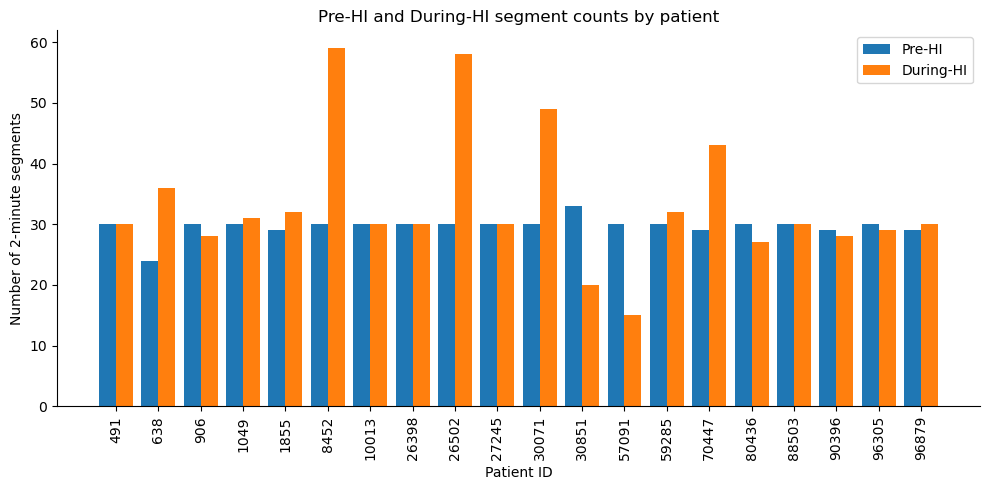

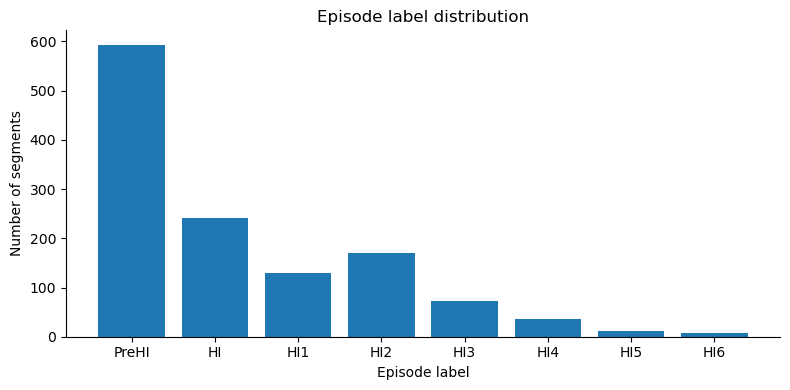

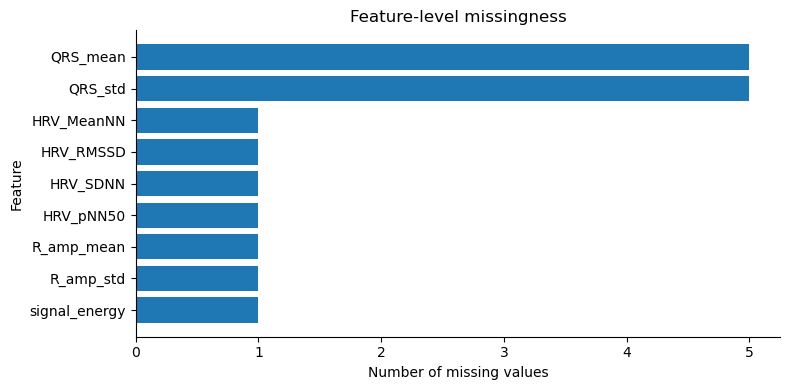

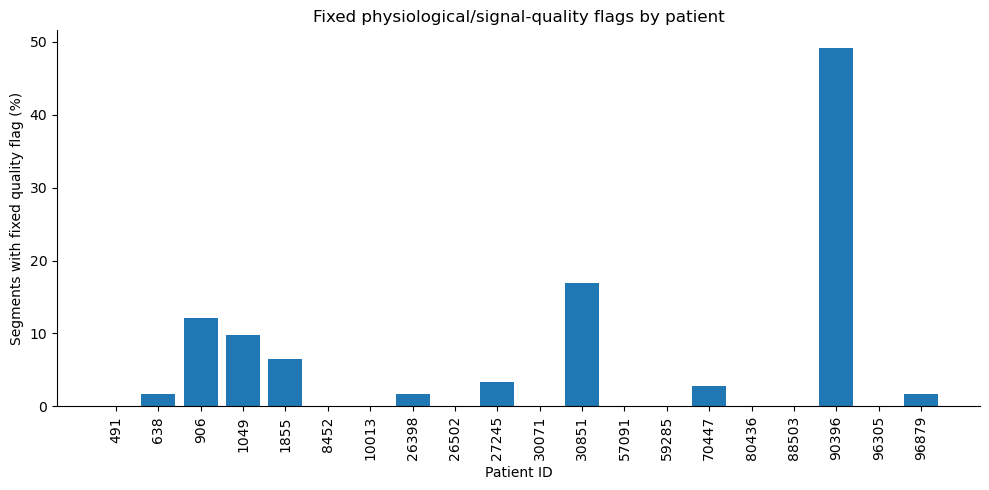

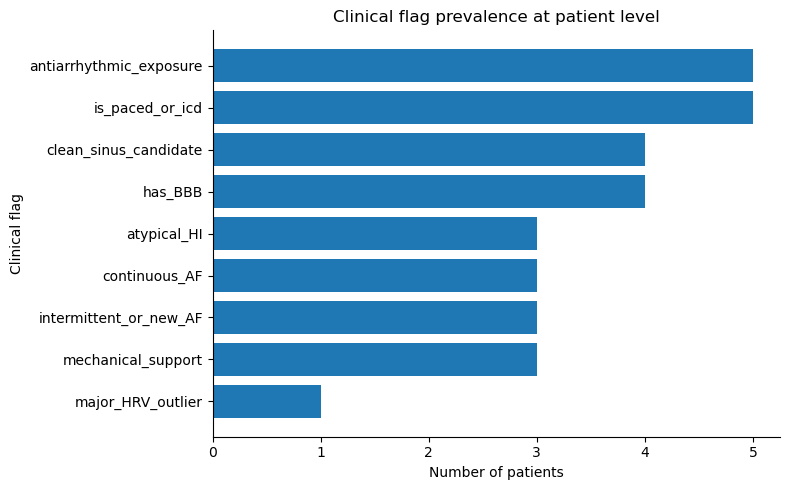

Section 6 complete: cohort description tables and figures created.
Tables saved to: analysis_outputs/tables
Figures saved to: analysis_outputs/figures



,item,value
0,Number of patients,20
1,Total ECG segments,1260
2,PreHI segments,593
3,During-HI segments,667
4,Informative features,52
5,Patients with both PreHI and HI,20
6,Patients with at least one fixed quality-flagg...,10
7,Features with missing values,9


,Patient_id,n_PreHI_segments,n_HI_segments,n_total_segments,percent_HI_segments,is_paced_or_icd,continuous_AF,intermittent_or_new_AF,atypical_HI,major_HRV_outlier,has_BBB,antiarrhythmic_exposure,mechanical_support,clean_sinus_candidate,n_fixed_quality_flag_segments,percent_fixed_quality_flag_segments,n_iqr_outlier_segments,percent_any_quality_or_iqr_flag_segments,n_missing_feature_cells,percent_missing_feature_cells
0,491,30,30,60,50.00,1,0,0,0,0,0,0,0,0,0,0.00,60,100.00,0,0.00
1,638,24,36,60,60.00,1,1,0,0,0,1,1,0,0,1,1.67,54,90.00,0,0.00
2,906,30,28,58,48.28,0,0,0,0,1,0,0,0,0,7,12.07,21,36.21,0,0.00
3,1049,30,31,61,50.82,1,0,1,0,0,0,1,0,0,6,9.84,16,26.23,0,0.00
4,1855,29,32,61,52.46,0,0,0,0,0,0,0,1,0,4,6.56,38,62.30,0,0.00
5,8452,30,59,89,66.29,0,0,0,0,0,0,0,0,1,0,0.00,16,17.98,0,0.00
6,10013,30,30,60,50.00,0,0,1,0,0,0,0,0,0,0,0.00,1,1.67,0,0.00
7,26398,30,30,60,50.00,0,1,0,0,0,0,1,0,0,1,1.67,2,3.33,0,0.00
8,26502,30,58,88,65.91,0,0,1,0,0,0,0,0,0,0,0.00,48,54.55,0,0.00
9,27245,30,30,60,50.00,1,0,0,0,0,1,0,0,0,2,3.33,60,100.00,0,0.00


,clinical_flag,n_patients_flagged,percent_patients_flagged
0,antiarrhythmic_exposure,5,25.0
1,is_paced_or_icd,5,25.0
2,clean_sinus_candidate,4,20.0
3,has_BBB,4,20.0
4,atypical_HI,3,15.0
5,continuous_AF,3,15.0
6,intermittent_or_new_AF,3,15.0
7,mechanical_support,3,15.0
8,major_HRV_outlier,1,5.0


,quality_flag,n_segments_flagged,percent_segments_flagged
0,flag_HRV_MeanNN_high,33,2.62
1,flag_HRV_RMSSD_high,23,1.83
2,flag_HRV_SDNN_high,19,1.51
3,flag_QRS_std_zero,5,0.40
4,flag_missing_key_quality_feature,5,0.40
5,flag_signal_energy_high,3,0.24
6,flag_signal_energy_low,1,0.08


,feature,n_missing,percent_missing
0,QRS_mean,5,0.397
1,QRS_std,5,0.397
2,HRV_MeanNN,1,0.079
3,HRV_RMSSD,1,0.079
4,HRV_SDNN,1,0.079
5,HRV_pNN50,1,0.079
6,R_amp_mean,1,0.079
7,R_amp_std,1,0.079
8,signal_energy,1,0.079
9,approximateEntropy,0,0.000


In [14]:
# -----------------------------
# Section 6 — Cohort description tables and figures
# -----------------------------
# This section continues from Sections 1–5. It uses:
#   - df_quality: dataframe with clinical and signal-quality flags from Section 5
#   - informative_features: final non-constant feature list from Section 3
#   - TABLES_DIR: output table directory
#   - FIGURES_DIR: output figure directory, created if not already present
#
# This section does not run statistical tests.
# It creates descriptive cohort tables and basic figures for manuscript reporting.

# -----------------------------
# 6.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "informative_features",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 6 expects Sections 1–5 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# Create FIGURES_DIR if it was not already defined in Section 1.
if "FIGURES_DIR" not in globals():
    FIGURES_DIR = TABLES_DIR.parent / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Work on a copy so that Section 6 does not accidentally modify df_quality.
df_desc = df_quality.copy()

# Ensure Patient_id is consistently treated as string for plotting and grouping.
df_desc["Patient_id"] = df_desc["Patient_id"].astype(str)

# -----------------------------
# 6.2 Patient-wise segment counts
# -----------------------------
patient_class_counts = (
    df_desc
    .groupby(["Patient_id", "Class"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure both class columns exist.
for class_value in [0, 1]:
    if class_value not in patient_class_counts.columns:
        patient_class_counts[class_value] = 0

patient_class_counts = patient_class_counts.rename(
    columns={
        0: "n_PreHI_segments",
        1: "n_HI_segments",
    }
)

patient_class_counts["n_total_segments"] = (
    patient_class_counts["n_PreHI_segments"]
    + patient_class_counts["n_HI_segments"]
)

patient_class_counts["percent_HI_segments"] = (
    100
    * patient_class_counts["n_HI_segments"]
    / patient_class_counts["n_total_segments"]
).round(2)

patient_class_counts = patient_class_counts.sort_values(
    "Patient_id",
    key=lambda s: s.astype(int)
).reset_index(drop=True)

# -----------------------------
# 6.3 Patient-level clinical flag summary
# -----------------------------
clinical_flag_columns = [
    "is_paced_or_icd",
    "continuous_AF",
    "intermittent_or_new_AF",
    "atypical_HI",
    "major_HRV_outlier",
    "has_BBB",
    "antiarrhythmic_exposure",
    "mechanical_support",
    "clean_sinus_candidate",
]

clinical_flag_columns = [
    column for column in clinical_flag_columns
    if column in df_desc.columns
]

patient_clinical_summary = (
    df_desc[["Patient_id"] + clinical_flag_columns]
    .drop_duplicates()
    .sort_values("Patient_id", key=lambda s: s.astype(int))
    .reset_index(drop=True)
)

clinical_flag_prevalence_patient_level = []

for flag in clinical_flag_columns:
    n_patients_flagged = int(patient_clinical_summary[flag].sum())
    clinical_flag_prevalence_patient_level.append({
        "clinical_flag": flag,
        "n_patients_flagged": n_patients_flagged,
        "percent_patients_flagged": round(
            100 * n_patients_flagged / patient_clinical_summary["Patient_id"].nunique(),
            2
        ),
    })

clinical_flag_prevalence_patient_level = pd.DataFrame(
    clinical_flag_prevalence_patient_level
).sort_values(
    ["n_patients_flagged", "clinical_flag"],
    ascending=[False, True],
).reset_index(drop=True)

clinical_flag_prevalence_segment_level = []

for flag in clinical_flag_columns:
    n_segments_flagged = int(df_desc[flag].sum())
    clinical_flag_prevalence_segment_level.append({
        "clinical_flag": flag,
        "n_segments_flagged": n_segments_flagged,
        "percent_segments_flagged": round(
            100 * n_segments_flagged / len(df_desc),
            2
        ),
    })

clinical_flag_prevalence_segment_level = pd.DataFrame(
    clinical_flag_prevalence_segment_level
).sort_values(
    ["n_segments_flagged", "clinical_flag"],
    ascending=[False, True],
).reset_index(drop=True)

# -----------------------------
# 6.4 Episode label distribution
# -----------------------------
if "Episode_Label" in df_desc.columns:
    episode_label_summary = (
        df_desc
        .groupby(["Episode_Label", "Class"])
        .size()
        .reset_index(name="n_segments")
        .sort_values(["Class", "Episode_Label"])
        .reset_index(drop=True)
    )

    episode_label_by_patient = (
        df_desc
        .groupby(["Patient_id", "Episode_Label"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    episode_label_by_patient = episode_label_by_patient.sort_values(
        "Patient_id",
        key=lambda s: s.astype(int)
    ).reset_index(drop=True)

else:
    episode_label_summary = pd.DataFrame()
    episode_label_by_patient = pd.DataFrame()

# -----------------------------
# 6.5 Missingness summary
# -----------------------------
feature_missingness_summary = []

for feature in informative_features:
    n_missing = int(df_desc[feature].isna().sum())
    feature_missingness_summary.append({
        "feature": feature,
        "n_missing": n_missing,
        "percent_missing": round(100 * n_missing / len(df_desc), 3),
    })

feature_missingness_summary = pd.DataFrame(
    feature_missingness_summary
).sort_values(
    ["n_missing", "feature"],
    ascending=[False, True],
).reset_index(drop=True)

patient_missingness_summary = (
    df_desc
    .groupby("Patient_id")[informative_features]
    .apply(lambda x: int(x.isna().sum().sum()))
    .reset_index(name="n_missing_feature_cells")
)

patient_missingness_summary["n_total_feature_cells"] = (
    df_desc.groupby("Patient_id").size().values * len(informative_features)
)

patient_missingness_summary["percent_missing_feature_cells"] = (
    100
    * patient_missingness_summary["n_missing_feature_cells"]
    / patient_missingness_summary["n_total_feature_cells"]
).round(3)

patient_missingness_summary = patient_missingness_summary.sort_values(
    "Patient_id",
    key=lambda s: s.astype(int)
).reset_index(drop=True)

# -----------------------------
# 6.6 Signal-quality flag summary
# -----------------------------
fixed_quality_columns = [
    "flag_HRV_MeanNN_high",
    "flag_HRV_SDNN_high",
    "flag_HRV_RMSSD_high",
    "flag_signal_energy_low",
    "flag_signal_energy_high",
    "flag_QRS_std_zero",
    "flag_missing_key_quality_feature",
]

fixed_quality_columns = [
    column for column in fixed_quality_columns
    if column in df_desc.columns
]

quality_summary_patient_level = (
    df_desc
    .groupby("Patient_id")
    .agg(
        n_segments=("Patient_id", "size"),
        n_fixed_quality_flag_segments=("any_fixed_quality_flag", "sum"),
        n_iqr_outlier_segments=("any_iqr_outlier", "sum"),
        n_any_quality_or_iqr_flag_segments=("any_quality_or_iqr_flag", "sum"),
    )
    .reset_index()
)

quality_summary_patient_level["percent_fixed_quality_flag_segments"] = (
    100
    * quality_summary_patient_level["n_fixed_quality_flag_segments"]
    / quality_summary_patient_level["n_segments"]
).round(2)

quality_summary_patient_level["percent_any_quality_or_iqr_flag_segments"] = (
    100
    * quality_summary_patient_level["n_any_quality_or_iqr_flag_segments"]
    / quality_summary_patient_level["n_segments"]
).round(2)

quality_summary_patient_level = quality_summary_patient_level.sort_values(
    "Patient_id",
    key=lambda s: s.astype(int)
).reset_index(drop=True)

quality_summary_flag_level = []

for flag in fixed_quality_columns:
    n_flagged = int(df_desc[flag].sum())
    quality_summary_flag_level.append({
        "quality_flag": flag,
        "n_segments_flagged": n_flagged,
        "percent_segments_flagged": round(100 * n_flagged / len(df_desc), 2),
    })

quality_summary_flag_level = pd.DataFrame(
    quality_summary_flag_level
).sort_values(
    ["n_segments_flagged", "quality_flag"],
    ascending=[False, True],
).reset_index(drop=True)

# -----------------------------
# 6.7 Combined Table 1-style patient summary
# -----------------------------
table1_patient_summary = patient_class_counts.merge(
    patient_clinical_summary,
    on="Patient_id",
    how="left",
).merge(
    quality_summary_patient_level[
        [
            "Patient_id",
            "n_fixed_quality_flag_segments",
            "percent_fixed_quality_flag_segments",
            "n_iqr_outlier_segments",
            "percent_any_quality_or_iqr_flag_segments",
        ]
    ],
    on="Patient_id",
    how="left",
).merge(
    patient_missingness_summary[
        [
            "Patient_id",
            "n_missing_feature_cells",
            "percent_missing_feature_cells",
        ]
    ],
    on="Patient_id",
    how="left",
)

# -----------------------------
# 6.8 Save descriptive tables
# -----------------------------
table1_patient_summary.to_csv(
    TABLES_DIR / "26_table1_patient_summary.csv",
    index=False,
)

patient_class_counts.to_csv(
    TABLES_DIR / "27_patient_class_counts_section6.csv",
    index=False,
)

clinical_flag_prevalence_patient_level.to_csv(
    TABLES_DIR / "28_clinical_flag_prevalence_patient_level.csv",
    index=False,
)

clinical_flag_prevalence_segment_level.to_csv(
    TABLES_DIR / "29_clinical_flag_prevalence_segment_level.csv",
    index=False,
)

episode_label_summary.to_csv(
    TABLES_DIR / "30_episode_label_summary_section6.csv",
    index=False,
)

episode_label_by_patient.to_csv(
    TABLES_DIR / "31_episode_label_by_patient.csv",
    index=False,
)

feature_missingness_summary.to_csv(
    TABLES_DIR / "32_feature_missingness_summary_section6.csv",
    index=False,
)

patient_missingness_summary.to_csv(
    TABLES_DIR / "33_patient_missingness_summary_section6.csv",
    index=False,
)

quality_summary_patient_level.to_csv(
    TABLES_DIR / "34_quality_summary_patient_level_section6.csv",
    index=False,
)

quality_summary_flag_level.to_csv(
    TABLES_DIR / "35_quality_summary_flag_level_section6.csv",
    index=False,
)

section_6_summary = pd.DataFrame([
    {
        "item": "Number of patients",
        "value": df_desc["Patient_id"].nunique(),
    },
    {
        "item": "Total ECG segments",
        "value": len(df_desc),
    },
    {
        "item": "PreHI segments",
        "value": int((df_desc["Class"] == 0).sum()),
    },
    {
        "item": "During-HI segments",
        "value": int((df_desc["Class"] == 1).sum()),
    },
    {
        "item": "Informative features",
        "value": len(informative_features),
    },
    {
        "item": "Patients with both PreHI and HI",
        "value": int(
            patient_class_counts[
                (patient_class_counts["n_PreHI_segments"] > 0)
                & (patient_class_counts["n_HI_segments"] > 0)
            ].shape[0]
        ),
    },
    {
        "item": "Patients with at least one fixed quality-flagged segment",
        "value": int(
            (quality_summary_patient_level["n_fixed_quality_flag_segments"] > 0).sum()
        ),
    },
    {
        "item": "Features with missing values",
        "value": int((feature_missingness_summary["n_missing"] > 0).sum()),
    },
])

section_6_summary.to_csv(
    TABLES_DIR / "36_section_6_summary.csv",
    index=False,
)

# -----------------------------
# 6.9 Create basic figures
# -----------------------------

# Figure 1: Patient-wise PreHI and HI segment counts
fig, ax = plt.subplots(figsize=(10, 5))

x_positions = np.arange(len(patient_class_counts))
bar_width = 0.4

ax.bar(
    x_positions - bar_width / 2,
    patient_class_counts["n_PreHI_segments"],
    width=bar_width,
    label="Pre-HI"
)

ax.bar(
    x_positions + bar_width / 2,
    patient_class_counts["n_HI_segments"],
    width=bar_width,
    label="During-HI"
)

ax.set_xticks(x_positions)
ax.set_xticklabels(patient_class_counts["Patient_id"], rotation=90)
ax.set_xlabel("Patient ID")
ax.set_ylabel("Number of 2-minute segments")
ax.set_title("Pre-HI and During-HI segment counts by patient")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "01_patient_class_counts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 2: Episode label distribution
if not episode_label_summary.empty:
    episode_plot_data = (
        df_desc["Episode_Label"]
        .value_counts()
        .rename_axis("Episode_Label")
        .reset_index(name="n_segments")
    )

    # Order labels manually where present.
    preferred_episode_order = [
        "PreHI", "HI", "HI1", "HI2", "HI3", "HI4", "HI5", "HI6"
    ]

    episode_plot_data["Episode_Label"] = pd.Categorical(
        episode_plot_data["Episode_Label"],
        categories=[
            label for label in preferred_episode_order
            if label in episode_plot_data["Episode_Label"].tolist()
        ],
        ordered=True,
    )

    episode_plot_data = episode_plot_data.sort_values("Episode_Label")

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(
        episode_plot_data["Episode_Label"].astype(str),
        episode_plot_data["n_segments"],
    )

    ax.set_xlabel("Episode label")
    ax.set_ylabel("Number of segments")
    ax.set_title("Episode label distribution")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    fig.savefig(
        FIGURES_DIR / "02_episode_label_distribution.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# Figure 3: Feature missingness
missing_features_to_plot = feature_missingness_summary[
    feature_missingness_summary["n_missing"] > 0
].copy()

if not missing_features_to_plot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.barh(
        missing_features_to_plot["feature"],
        missing_features_to_plot["n_missing"],
    )

    ax.set_xlabel("Number of missing values")
    ax.set_ylabel("Feature")
    ax.set_title("Feature-level missingness")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    fig.savefig(
        FIGURES_DIR / "03_feature_missingness.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# Figure 4: Patient-level fixed quality-flag percentages
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    quality_summary_patient_level["Patient_id"],
    quality_summary_patient_level["percent_fixed_quality_flag_segments"],
)

ax.set_xlabel("Patient ID")
ax.set_ylabel("Segments with fixed quality flag (%)")
ax.set_title("Fixed physiological/signal-quality flags by patient")
ax.tick_params(axis="x", rotation=90)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "04_fixed_quality_flags_by_patient.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 5: Clinical flag prevalence at patient level
if not clinical_flag_prevalence_patient_level.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(
        clinical_flag_prevalence_patient_level["clinical_flag"],
        clinical_flag_prevalence_patient_level["n_patients_flagged"],
    )

    ax.set_xlabel("Number of patients")
    ax.set_ylabel("Clinical flag")
    ax.set_title("Clinical flag prevalence at patient level")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    fig.savefig(
        FIGURES_DIR / "05_clinical_flag_prevalence_patient_level.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# -----------------------------
# 6.10 Display compact outputs
# -----------------------------
print("Section 6 complete: cohort description tables and figures created.")
print(f"Tables saved to: {TABLES_DIR}")
print(f"Figures saved to: {FIGURES_DIR}\n")

display(section_6_summary)
display(table1_patient_summary)
display(clinical_flag_prevalence_patient_level)
display(quality_summary_flag_level)
display(feature_missingness_summary.head(15))

## Section 6 — Cohort description: findings and interpretation

Section 6 confirms that the dataset is suitable for the planned patient-level paired analysis.

### 1. Segment distribution

The dataset contains **20 patients** and all patients have both Pre-HI and During-HI segments. This supports the planned paired within-patient analysis.

Across the cohort:

- Total ECG segments: **1,260**
- Pre-HI segments: **593**
- During-HI segments: **667**

Most patients have approximately balanced Pre-HI and HI segment counts. However, some patients have a higher proportion of HI segments, especially:

- Patient `8452`: 30 Pre-HI vs 59 HI segments
- Patient `26502`: 30 Pre-HI vs 58 HI segments
- Patient `30071`: 30 Pre-HI vs 49 HI segments

Some patients have fewer HI segments, such as:

- Patient `57091`: 30 Pre-HI vs 15 HI segments
- Patient `30851`: 33 Pre-HI vs 20 HI segments

This reinforces the decision to use **patient-level median aggregation** for the primary analysis, because it prevents patients with more segments from dominating the results.

### 2. Episode label distribution

Although `Episode_Label` is not used in the primary statistical analysis, the descriptive audit confirms that the labels are meaningful and consistent with class assignment.

Episode-label counts were:

| Episode label | Class | Segments |
|---|---:|---:|
| PreHI | 0 | 593 |
| HI | 1 | 241 |
| HI1 | 1 | 130 |
| HI2 | 1 | 170 |
| HI3 | 1 | 72 |
| HI4 | 1 | 36 |
| HI5 | 1 | 11 |
| HI6 | 1 | 7 |

The later fragmented episode labels, especially `HI5` and `HI6`, contain very few segments. This supports our decision **not to model episode order in the primary analysis**. Episode labels should remain descriptive or be used only in a limited sensitivity check for top features.

### 3. Clinical flag distribution

The cohort has substantial clinical heterogeneity.

At the patient level:

| Clinical flag | Patients flagged |
|---|---:|
| Antiarrhythmic exposure | 5 / 20 |
| Paced / ICD | 5 / 20 |
| Clean sinus candidate | 4 / 20 |
| Bundle branch block | 4 / 20 |
| Atypical HI | 3 / 20 |
| Continuous AF | 3 / 20 |
| Intermittent or new AF | 3 / 20 |
| Mechanical support | 3 / 20 |
| Major HRV outlier | 1 / 20 |

At the segment level, paced/ICD and antiarrhythmic exposure each account for approximately **23%** of all segments. Continuous AF accounts for approximately **14%** of all segments.

This confirms that clinical confounding is important, especially for HRV and morphology features. Therefore, clinical flags should not be ignored. However, they should mainly be used for **sensitivity analyses and interpretation**, rather than excluding patients from the full-cohort primary analysis.

### 4. Missingness

Missingness is very low.

Only 9 informative features have any missing values:

| Feature | Missing values |
|---|---:|
| QRS_mean | 5 |
| QRS_std | 5 |
| HRV_MeanNN | 1 |
| HRV_SDNN | 1 |
| HRV_RMSSD | 1 |
| HRV_pNN50 | 1 |
| R_amp_mean | 1 |
| R_amp_std | 1 |
| signal_energy | 1 |

At the patient level, missing feature cells occur only in:

- Patient `30851`: 8 missing feature cells
- Patient `70447`: 9 missing feature cells

All other patients have no missing feature cells.

This level of missingness is small and should not materially affect the primary analysis. Feature-wise complete-pair handling is appropriate.

### 5. Fixed physiological and signal-quality flags

The most common fixed signal-quality or physiological warning flags were:

| Flag | Segments flagged |
|---|---:|
| HRV_MeanNN > 1500 | 33 |
| HRV_RMSSD > 500 | 23 |
| HRV_SDNN > 500 | 19 |
| QRS_std = 0 | 5 |
| Missing key quality feature | 5 |
| signal_energy > 50000 | 3 |
| signal_energy < 10 | 1 |

Patient `90396` has the highest proportion of fixed quality-flagged segments, with **28 / 57 segments** flagged. This is consistent with its known continuous AF / HRV outlier profile and reinforces the need for an HRV-valid subgroup analysis.

Other patients with notable fixed quality-flagged segment proportions include:

- Patient `30851`: 9 / 53 segments
- Patient `906`: 7 / 58 segments
- Patient `1049`: 6 / 61 segments
- Patient `1855`: 4 / 61 segments

The fixed quality flags should be used for a signal-quality sensitivity analysis. They should not lead to automatic deletion from the primary full-cohort analysis.

### 6. IQR outlier flags

The IQR-based outlier flags are much broader than the fixed physiological flags. Some patients, such as `491`, `27245`, and `90396`, have IQR outliers in nearly all segments.

This likely reflects true patient-specific ECG morphology or rhythm differences rather than simple data error. Therefore, IQR outlier flags should be used descriptively and cautiously.

For the main sensitivity analysis, it is better to use the fixed physiological/signal-quality flags rather than removing all IQR outliers.

### 7. Overall interpretation

Section 6 supports the planned analysis strategy.

The dataset is suitable for the primary patient-level paired comparison because:

- All 20 patients have both Pre-HI and During-HI segments.
- Missingness is minimal.
- Class labels and episode labels are structurally consistent.
- Segment imbalance exists but is handled by patient-level median aggregation.

The cohort is clinically heterogeneous, with important rhythm, pacing, drug, mechanical-support, and shock-mechanism confounders. This means that final feature interpretation must include sensitivity analyses, especially for HRV-related features.

The next analysis step should be the **primary patient-level paired feature analysis**, using the 52 informative features and comparing each patient's median Pre-HI value against their median During-HI value.

# Section 7 — Primary patient-level paired feature analysis

This section performs the main statistical analysis of the study.

The primary comparison is:

- `Class 0` = Pre-HI
- `Class 1` = During-HI

The patient, not the ECG segment, is treated as the primary statistical unit. This is important because each patient contributes multiple 2-minute ECG segments, and these repeated segments are not independent observations.

For each patient and each informative ECG feature, the median feature value is calculated separately for:

- all Pre-HI segments from that patient
- all During-HI segments from that patient

The paired patient-level difference is then calculated as:

`During-HI median - Pre-HI median`

For each feature, this section reports:

- number of patients with valid paired data
- cohort median Pre-HI value
- cohort median During-HI value
- median paired difference
- median percentage change
- number of patients with increased values during HI
- number of patients with decreased values during HI
- number of patients with unchanged values
- direction consistency
- Wilcoxon signed-rank statistic and p-value
- matched-pairs rank-biserial effect size
- bootstrap 95% confidence interval for the median paired difference
- global Benjamini-Hochberg FDR-adjusted p-value
- feature-family Benjamini-Hochberg FDR-adjusted p-value

Bootstrap confidence intervals are included because this is a small cohort with 20 paired patients. The confidence intervals help show the uncertainty around the estimated patient-level median change, instead of relying only on p-values.

No patients are excluded in this primary full-cohort analysis. Clinical flags and signal-quality flags will be used later for sensitivity analyses.

In [15]:
# -----------------------------
# Section 7 — Primary patient-level paired feature analysis
# -----------------------------
# This section continues from Sections 1–6. It uses:
#   - df_quality: dataframe with clinical and quality flags from Section 5
#   - informative_features: final non-constant feature list from Section 3
#   - TABLES_DIR: output table directory
#   - feature_dictionary: feature-family table from Section 3, if available
#
# Primary statistical unit: Patient_id
# Primary comparison: Class 0 Pre-HI vs Class 1 During-HI
#
# No patients or rows are excluded in this primary full-cohort analysis.
# Missing values are handled feature-wise by requiring valid paired patient medians.

# -----------------------------
# 7.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "informative_features",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 7 expects Sections 1–6 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# Required packages for this section.
from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

# Work on a copy so the main dataframe is not modified unexpectedly.
df_primary = df_quality.copy()

# Standardize Patient_id and Class for grouping.
df_primary["Patient_id"] = df_primary["Patient_id"].astype(str)
df_primary["Class"] = pd.to_numeric(df_primary["Class"], errors="coerce")

# Keep only informative features that are present in the dataframe.
informative_features = [
    feature for feature in informative_features
    if feature in df_primary.columns
]

# -----------------------------
# 7.2 Get feature-family mapping
# -----------------------------
# Prefer the in-memory feature_dictionary from Section 3.
# If it is not available, read the saved table from Section 3.

if "feature_dictionary" in globals():
    feature_dictionary_for_section7 = feature_dictionary.copy()
else:
    feature_dictionary_path = TABLES_DIR / "10_feature_dictionary.csv"
    if feature_dictionary_path.exists():
        feature_dictionary_for_section7 = pd.read_csv(feature_dictionary_path)
    else:
        raise RuntimeError(
            "Feature dictionary not found. Run Section 3 first or ensure "
            "'10_feature_dictionary.csv' exists in TABLES_DIR."
        )

# Make the feature-family mapping robust to slightly different column names.
possible_feature_columns = ["feature", "Feature", "feature_name"]
possible_family_columns = ["family", "Feature_Family", "feature_family"]

feature_column_name = next(
    (column for column in possible_feature_columns if column in feature_dictionary_for_section7.columns),
    None,
)

family_column_name = next(
    (column for column in possible_family_columns if column in feature_dictionary_for_section7.columns),
    None,
)

if feature_column_name is None or family_column_name is None:
    raise RuntimeError(
        "Feature dictionary must contain a feature column and a family column."
    )

feature_to_family = (
    feature_dictionary_for_section7
    .set_index(feature_column_name)[family_column_name]
    .to_dict()
)

# -----------------------------
# 7.3 Define helper functions
# -----------------------------
def matched_rank_biserial(differences):
    """
    Matched-pairs rank-biserial correlation.

    Positive values indicate that the feature tends to be higher during HI.
    Negative values indicate that the feature tends to be lower during HI.
    """
    d = np.asarray(differences, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]

    if len(d) == 0:
        return np.nan

    ranks = rankdata(np.abs(d), method="average")
    total_rank_sum = ranks.sum()

    if total_rank_sum == 0:
        return np.nan

    positive_rank_sum = ranks[d > 0].sum()
    negative_rank_sum = ranks[d < 0].sum()

    return float((positive_rank_sum - negative_rank_sum) / total_rank_sum)


def bootstrap_ci_median_difference(differences, n_bootstrap=10000, ci=95, seed=2026):
    """
    Bootstrap confidence interval for the median paired difference.

    The resampling unit is the patient-level paired difference.
    """
    d = np.asarray(differences, dtype=float)
    d = d[np.isfinite(d)]

    if len(d) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    bootstrap_medians = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(d, size=len(d), replace=True)
        bootstrap_medians[i] = np.nanmedian(sample)

    alpha = 100 - ci
    lower = np.percentile(bootstrap_medians, alpha / 2)
    upper = np.percentile(bootstrap_medians, 100 - alpha / 2)

    return float(lower), float(upper)


def safe_wilcoxon(before_values, during_values):
    """
    Safe Wilcoxon signed-rank test for paired patient-level values.

    Returns statistic and p-value.
    If all non-missing paired differences are zero, p-value is set to 1.0.
    """
    before = np.asarray(before_values, dtype=float)
    during = np.asarray(during_values, dtype=float)

    valid_mask = np.isfinite(before) & np.isfinite(during)

    before = before[valid_mask]
    during = during[valid_mask]

    if len(before) == 0:
        return np.nan, np.nan

    differences = during - before
    nonzero_differences = differences[np.isfinite(differences) & (differences != 0)]

    if len(nonzero_differences) == 0:
        return 0.0, 1.0

    try:
        statistic, p_value = wilcoxon(
            during,
            before,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        )
        return float(statistic), float(p_value)

    except ValueError:
        return np.nan, np.nan


# -----------------------------
# 7.4 Aggregate segment-level data to patient-level medians
# -----------------------------
# One row per patient per class, with median feature values across all available
# segments in that patient and class.

subject_condition_medians = (
    df_primary
    .groupby(["Patient_id", "Class"], as_index=False)[informative_features]
    .median(numeric_only=True)
)

# Save the wide patient-condition median table.
subject_condition_medians.to_csv(
    TABLES_DIR / "37_subject_condition_feature_medians_wide.csv",
    index=False,
)

# -----------------------------
# 7.5 Feature-wise paired analysis
# -----------------------------
paired_results_rows = []
subject_level_rows = []

for feature in informative_features:
    feature_family = feature_to_family.get(feature, "Unassigned")

    # Convert patient-condition medians to paired wide format for this feature.
    paired_wide = (
        subject_condition_medians
        .pivot(
            index="Patient_id",
            columns="Class",
            values=feature,
        )
    )

    # Ensure both Class 0 and Class 1 columns exist.
    if 0 not in paired_wide.columns:
        paired_wide[0] = np.nan

    if 1 not in paired_wide.columns:
        paired_wide[1] = np.nan

    paired_wide = paired_wide[[0, 1]].rename(
        columns={
            0: "PreHI_median",
            1: "HI_median",
        }
    )

    paired_wide = paired_wide.dropna(
        subset=["PreHI_median", "HI_median"]
    ).copy()

    paired_wide["feature"] = feature
    paired_wide["feature_family"] = feature_family
    paired_wide["difference_HI_minus_PreHI"] = (
        paired_wide["HI_median"] - paired_wide["PreHI_median"]
    )

    # Percentage change is undefined when PreHI median is zero.
    valid_percent_change = (
        paired_wide["PreHI_median"].notna()
        & paired_wide["difference_HI_minus_PreHI"].notna()
        & (paired_wide["PreHI_median"].abs() > np.finfo(float).eps)
    )

    paired_wide["percent_change"] = np.nan
    paired_wide.loc[valid_percent_change, "percent_change"] = (
        100
        * paired_wide.loc[valid_percent_change, "difference_HI_minus_PreHI"]
        / paired_wide.loc[valid_percent_change, "PreHI_median"].abs()
    )

    # Store patient-level paired values in long table.
    subject_level_rows.append(
        paired_wide
        .reset_index()
        [
            [
                "Patient_id",
                "feature",
                "feature_family",
                "PreHI_median",
                "HI_median",
                "difference_HI_minus_PreHI",
                "percent_change",
            ]
        ]
    )

    before = paired_wide["PreHI_median"].to_numpy(dtype=float)
    during = paired_wide["HI_median"].to_numpy(dtype=float)
    differences = paired_wide["difference_HI_minus_PreHI"].to_numpy(dtype=float)
    percent_changes = paired_wide["percent_change"].to_numpy(dtype=float)

    n_subjects_available = int(len(paired_wide))

    n_increased = int(np.sum(differences > 0))
    n_decreased = int(np.sum(differences < 0))
    n_unchanged = int(np.sum(differences == 0))

    if n_subjects_available > 0:
        direction_consistency = max(
            n_increased,
            n_decreased,
        ) / n_subjects_available
    else:
        direction_consistency = np.nan

    if n_increased > n_decreased:
        dominant_direction = "increased_during_HI"
    elif n_decreased > n_increased:
        dominant_direction = "decreased_during_HI"
    elif n_subjects_available == 0:
        dominant_direction = "not_available"
    else:
        dominant_direction = "tied"

    wilcoxon_statistic, wilcoxon_p_value = safe_wilcoxon(
        before,
        during,
    )

    bootstrap_ci_low, bootstrap_ci_high = bootstrap_ci_median_difference(
        differences,
        n_bootstrap=10000,
        ci=95,
        seed=2026,
    )

    paired_results_rows.append({
        "feature": feature,
        "feature_family": feature_family,
        "n_subjects_available": n_subjects_available,
        "median_PreHI": (
            float(np.nanmedian(before))
            if np.any(np.isfinite(before))
            else np.nan
        ),
        "median_HI": (
            float(np.nanmedian(during))
            if np.any(np.isfinite(during))
            else np.nan
        ),
        "median_difference": (
            float(np.nanmedian(differences))
            if np.any(np.isfinite(differences))
            else np.nan
        ),
        "bootstrap_ci_95_low_median_difference": bootstrap_ci_low,
        "bootstrap_ci_95_high_median_difference": bootstrap_ci_high,
        "median_percentage_change": (
            float(np.nanmedian(percent_changes))
            if np.any(np.isfinite(percent_changes))
            else np.nan
        ),
        "n_increased": n_increased,
        "n_decreased": n_decreased,
        "n_unchanged": n_unchanged,
        "direction_consistency": direction_consistency,
        "dominant_direction": dominant_direction,
        "wilcoxon_statistic": wilcoxon_statistic,
        "wilcoxon_p_value": wilcoxon_p_value,
        "rank_biserial_effect_size": matched_rank_biserial(differences),
    })

# Combine patient-level feature-pair rows.
subject_level_feature_medians = pd.concat(
    subject_level_rows,
    ignore_index=True,
)

primary_paired_results = pd.DataFrame(paired_results_rows)

# -----------------------------
# 7.6 Multiple-comparison correction
# -----------------------------
# Global BH-FDR across all informative features.
primary_paired_results["global_bh_fdr_p_value"] = multipletests(
    primary_paired_results["wilcoxon_p_value"].fillna(1.0),
    alpha=0.05,
    method="fdr_bh",
)[1]

primary_paired_results["global_bh_fdr_significant"] = (
    primary_paired_results["global_bh_fdr_p_value"] < 0.05
)

# Feature-family BH-FDR within each feature family.
primary_paired_results["family_bh_fdr_p_value"] = np.nan
primary_paired_results["family_bh_fdr_significant"] = False

for family, family_df in primary_paired_results.groupby("feature_family"):
    family_indices = family_df.index

    adjusted_family_p_values = multipletests(
        family_df["wilcoxon_p_value"].fillna(1.0),
        alpha=0.05,
        method="fdr_bh",
    )[1]

    primary_paired_results.loc[
        family_indices,
        "family_bh_fdr_p_value",
    ] = adjusted_family_p_values

    primary_paired_results.loc[
        family_indices,
        "family_bh_fdr_significant",
    ] = adjusted_family_p_values < 0.05

# Add convenience columns for sorting and interpretation.
primary_paired_results["absolute_rank_biserial_effect_size"] = (
    primary_paired_results["rank_biserial_effect_size"].abs()
)

primary_paired_results["bootstrap_ci_excludes_zero"] = (
    (
        primary_paired_results["bootstrap_ci_95_low_median_difference"] > 0
    )
    | (
        primary_paired_results["bootstrap_ci_95_high_median_difference"] < 0
    )
)

primary_paired_results["n_subjects_expected"] = df_primary["Patient_id"].nunique()

primary_paired_results["complete_20_patient_pairs"] = (
    primary_paired_results["n_subjects_available"]
    == primary_paired_results["n_subjects_expected"]
)

# Sort results in a way that prioritizes consistency and effect size.
primary_paired_results = primary_paired_results.sort_values(
    by=[
        "family_bh_fdr_significant",
        "global_bh_fdr_significant",
        "direction_consistency",
        "absolute_rank_biserial_effect_size",
        "family_bh_fdr_p_value",
        "wilcoxon_p_value",
    ],
    ascending=[
        False,
        False,
        False,
        False,
        True,
        True,
    ],
).reset_index(drop=True)

# -----------------------------
# 7.7 Create compact summary tables
# -----------------------------
section_7_summary = pd.DataFrame([
    {
        "item": "Informative features analysed",
        "value": len(informative_features),
    },
    {
        "item": "Patients available in dataset",
        "value": df_primary["Patient_id"].nunique(),
    },
    {
        "item": "Features with complete 20-patient paired data",
        "value": int(primary_paired_results["complete_20_patient_pairs"].sum()),
    },
    {
        "item": "Features significant after global BH-FDR",
        "value": int(primary_paired_results["global_bh_fdr_significant"].sum()),
    },
    {
        "item": "Features significant after family-level BH-FDR",
        "value": int(primary_paired_results["family_bh_fdr_significant"].sum()),
    },
    {
        "item": "Features with bootstrap 95% CI excluding zero",
        "value": int(primary_paired_results["bootstrap_ci_excludes_zero"].sum()),
    },
    {
        "item": "Features with direction consistency >= 0.80",
        "value": int((primary_paired_results["direction_consistency"] >= 0.80).sum()),
    },
    {
        "item": "Features with direction consistency >= 0.85",
        "value": int((primary_paired_results["direction_consistency"] >= 0.85).sum()),
    },
])

top_consistency_features = (
    primary_paired_results
    .sort_values(
        by=[
            "direction_consistency",
            "absolute_rank_biserial_effect_size",
            "family_bh_fdr_p_value",
        ],
        ascending=[False, False, True],
    )
    .head(20)
    .reset_index(drop=True)
)

top_effect_size_features = (
    primary_paired_results
    .sort_values(
        by=[
            "absolute_rank_biserial_effect_size",
            "direction_consistency",
            "family_bh_fdr_p_value",
        ],
        ascending=[False, False, True],
    )
    .head(20)
    .reset_index(drop=True)
)

# -----------------------------
# 7.8 Save outputs
# -----------------------------
subject_level_feature_medians.to_csv(
    TABLES_DIR / "38_subject_level_feature_medians_long.csv",
    index=False,
)

primary_paired_results.to_csv(
    TABLES_DIR / "39_primary_paired_feature_results.csv",
    index=False,
)

section_7_summary.to_csv(
    TABLES_DIR / "40_section_7_summary.csv",
    index=False,
)

top_consistency_features.to_csv(
    TABLES_DIR / "41_top_features_by_direction_consistency.csv",
    index=False,
)

top_effect_size_features.to_csv(
    TABLES_DIR / "42_top_features_by_effect_size.csv",
    index=False,
)

# -----------------------------
# 7.9 Display compact outputs
# -----------------------------
print("Section 7 complete: primary patient-level paired feature analysis finished.")
print("Primary comparison: patient-level median Pre-HI vs patient-level median During-HI.")
print("No patients were excluded in this primary full-cohort analysis.")
print(f"Tables saved to: {TABLES_DIR}\n")

display(section_7_summary)

display(
    primary_paired_results[
        [
            "feature",
            "feature_family",
            "n_subjects_available",
            "median_PreHI",
            "median_HI",
            "median_difference",
            "bootstrap_ci_95_low_median_difference",
            "bootstrap_ci_95_high_median_difference",
            "median_percentage_change",
            "n_increased",
            "n_decreased",
            "n_unchanged",
            "direction_consistency",
            "dominant_direction",
            "wilcoxon_p_value",
            "global_bh_fdr_p_value",
            "family_bh_fdr_p_value",
            "rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero",
        ]
    ].head(25)
)

Section 7 complete: primary patient-level paired feature analysis finished.
Primary comparison: patient-level median Pre-HI vs patient-level median During-HI.
No patients were excluded in this primary full-cohort analysis.
Tables saved to: analysis_outputs/tables



,item,value
0,Informative features analysed,52
1,Patients available in dataset,20
2,Features with complete 20-patient paired data,52
3,Features significant after global BH-FDR,0
4,Features significant after family-level BH-FDR,0
5,Features with bootstrap 95% CI excluding zero,2
6,Features with direction consistency >= 0.80,0
7,Features with direction consistency >= 0.85,0


,feature,feature_family,n_subjects_available,median_PreHI,median_HI,median_difference,bootstrap_ci_95_low_median_difference,bootstrap_ci_95_high_median_difference,median_percentage_change,n_increased,n_decreased,n_unchanged,direction_consistency,dominant_direction,wilcoxon_p_value,global_bh_fdr_p_value,family_bh_fdr_p_value,rank_biserial_effect_size,bootstrap_ci_excludes_zero
0,kurtosis,Time-domain statistics,20,5.980000,5.885000,0.992500,0.327500,1.965000,24.686602,15,5,0,0.75,increased_during_HI,0.036234,0.433006,0.362339,0.533333,True
1,HRV_MeanNN,HRV,20,626.025792,642.407174,20.759494,1.633756,67.209649,3.971999,15,5,0,0.75,increased_during_HI,0.053169,0.433006,0.106339,0.495238,True
2,entropyProfiled_maximum_sampleEntropy,Entropy-profile aggregates,20,2.382500,2.342500,-0.255000,-0.615000,0.000000,-14.036859,5,13,2,0.65,decreased_during_HI,0.034670,0.433006,0.277360,-0.567251,False
3,HRV_pNN50,HRV,20,44.738295,30.966069,-11.345795,-16.897240,0.770115,-21.293145,7,13,0,0.65,decreased_during_HI,0.026642,0.433006,0.106339,-0.561905,False
4,fuzzyEntropy,Entropy / complexity,20,0.230000,0.237500,-0.020000,-0.080000,0.000000,-10.818713,5,13,2,0.65,decreased_during_HI,0.063996,0.433006,0.249298,-0.497076,False
5,sampleEntropy,Entropy / complexity,20,0.267500,0.285000,-0.035000,-0.102500,0.002500,-16.275362,6,13,1,0.65,decreased_during_HI,0.064069,0.433006,0.249298,-0.484211,False
6,fd_median,FD-summary aggregates,20,2.952500,1.860000,-0.162500,-0.685000,0.105000,-5.472895,7,13,0,0.65,decreased_during_HI,0.089695,0.452813,0.341961,-0.438095,False
7,fd_mean,FD-summary aggregates,20,7.952500,7.120000,-0.365000,-0.742500,0.152500,-4.860165,7,13,0,0.65,decreased_during_HI,0.113987,0.493944,0.341961,-0.409524,False
8,signal_energy,Morphology / signal quality,20,12857.312428,13373.787763,174.673025,-47.193775,433.022373,1.291686,13,7,0,0.65,increased_during_HI,0.189348,0.620335,0.473371,0.342857,False
9,QRS_mean,Morphology / signal quality,20,0.134478,0.151313,0.010358,-0.000832,0.029739,5.902620,12,8,0,0.60,increased_during_HI,0.023951,0.433006,0.119753,0.571429,False


## Section 7 — Primary paired feature analysis: interpretation

Section 7 performed the main patient-level paired analysis comparing each patient’s median Pre-HI feature value with their median During-HI feature value.

The analysis included:

- **52 informative ECG features**
- **20 patients**
- **20 valid paired observations for every feature**
- No patients excluded in this primary full-cohort analysis

This confirms that the primary paired analysis was complete for all informative features.

---

### 1. Overall statistical finding

No feature survived multiple-comparison correction.

| Result | Count |
|---|---:|
| Features analysed | 52 |
| Features with complete 20-patient paired data | 52 |
| Features significant after global BH-FDR | 0 |
| Features significant after family-level BH-FDR | 0 |
| Features with bootstrap 95% CI excluding zero | 2 |
| Features with direction consistency ≥ 0.80 | 0 |
| Features with direction consistency ≥ 0.85 | 0 |

This means that, in the full 20-patient cohort, there is **no statistically definitive feature-level difference between Pre-HI and During-HI after correction for multiple testing**.

This should not be interpreted as “no features are useful.” Rather, it means that with **20 clinically heterogeneous patients and 52 features**, the evidence is not strong enough for formal corrected statistical significance.

The results should therefore be interpreted as **exploratory feature prioritisation**, not confirmatory biomarker validation.

---

### 2. Features with the strongest uncorrected evidence

Four features had uncorrected Wilcoxon p-values below 0.05:

| Feature | Direction during HI | Direction consistency | Raw p-value | Global FDR | Family FDR | Rank-biserial effect |
|---|---|---:|---:|---:|---:|---:|
| `QRS_mean` | Increased | 12 / 20 | 0.0239 | 0.4330 | 0.1198 | 0.571 |
| `HRV_pNN50` | Decreased | 13 / 20 | 0.0266 | 0.4330 | 0.1063 | -0.562 |
| `entropyProfiled_maximum_sampleEntropy` | Decreased | 13 / 20 | 0.0347 | 0.4330 | 0.2774 | -0.567 |
| `kurtosis` | Increased | 15 / 20 | 0.0362 | 0.4330 | 0.3623 | 0.533 |

These features are not statistically significant after FDR correction, but they are useful for prioritisation.

Among these, `kurtosis` and `HRV_MeanNN` showed the strongest patient-level consistency, while `QRS_mean`, `HRV_pNN50`, and `entropyProfiled_maximum_sampleEntropy` showed relatively strong rank-biserial effect sizes.

---

### 3. Features with bootstrap confidence intervals excluding zero

Only two features had bootstrap 95% confidence intervals for the median paired difference that excluded zero:

| Feature | Direction during HI | Median difference | Bootstrap 95% CI | Direction consistency |
|---|---|---:|---:|---:|
| `kurtosis` | Increased | 0.9925 | 0.3275 to 1.9650 | 15 / 20 |
| `HRV_MeanNN` | Increased | 20.76 ms | 1.63 to 67.21 ms | 15 / 20 |

These are currently the strongest full-cohort candidates from the primary paired analysis because they combine:

- relatively high direction consistency,
- moderate effect size,
- bootstrap confidence interval excluding zero,
- complete paired data from all 20 patients.

However, neither survived FDR correction. Therefore, they should be described as **candidate features**, not validated biomarkers.

---

### 4. Direction consistency findings

No feature reached the predefined strong consistency thresholds:

- No feature had direction consistency ≥ 80%.
- No feature had direction consistency ≥ 85%.

The highest observed direction consistency was **75%**, seen in:

| Feature | Direction | Patients showing dominant direction |
|---|---|---:|
| `kurtosis` | Increased during HI | 15 / 20 |
| `HRV_MeanNN` | Increased during HI | 15 / 20 |

This is an important finding. It means the full cohort is heterogeneous: different patients do not all show the same physiological feature response during HI.

This is clinically plausible because the cohort includes patients with:

- paced rhythm,
- AF,
- bundle branch block,
- antiarrhythmic exposure,
- ECMO/Tandem Heart support,
- atypical/non-primary cardiogenic HI mechanisms,
- major HRV outlier patterns.

Therefore, sensitivity analyses are essential before selecting final candidate features.

---

### 5. Interpretation of the most relevant candidate features

#### `HRV_MeanNN`

`HRV_MeanNN` increased during HI in 15 of 20 patients.

- Median Pre-HI: 626.03 ms
- Median HI: 642.41 ms
- Median difference: +20.76 ms
- Median percentage change: +3.97%
- Bootstrap 95% CI: +1.63 to +67.21 ms
- Direction consistency: 75%
- Raw p-value: 0.0532
- Family FDR: 0.1063

This suggests a tendency toward longer RR intervals during HI in the full cohort. However, HRV features are strongly confounded by AF, pacing, and rhythm irregularity. Therefore, `HRV_MeanNN` should not be interpreted from the full cohort alone.

It must be re-analysed in the **HRV-valid subgroup**, excluding paced/ICD patients, continuous AF patients, and the major HRV outlier patient.

---

#### `HRV_pNN50`

`HRV_pNN50` decreased during HI in 13 of 20 patients.

- Median Pre-HI: 44.74
- Median HI: 30.97
- Median difference: -11.35
- Median percentage change: -21.29%
- Direction consistency: 65%
- Raw p-value: 0.0266
- Family FDR: 0.1063
- Rank-biserial effect size: -0.562

This is physiologically interesting because reduced pNN50 may reflect reduced beat-to-beat variability during HI. However, like `HRV_MeanNN`, this feature is highly sensitive to AF, pacing, and R-peak detection quality.

It should be treated as a **candidate HRV feature pending HRV-valid subgroup analysis**.

---

#### `QRS_mean`

`QRS_mean` increased during HI in 12 of 20 patients.

- Median Pre-HI: 0.1345 s
- Median HI: 0.1513 s
- Median difference: +0.0104 s
- Median percentage change: +5.90%
- Raw p-value: 0.0239
- Family FDR: 0.1198
- Rank-biserial effect size: 0.571

This is one of the strongest morphology-related findings. It suggests possible QRS widening during HI in some patients.

However, interpretation requires caution because QRS duration is affected by:

- paced rhythm,
- ICD pacing,
- bundle branch block,
- antiarrhythmic drugs,
- electrolyte abnormalities,
- post-MI conduction changes.

Therefore, `QRS_mean` should be carried forward, but it needs sensitivity analysis excluding or flagging paced/BBB patients.

---

#### `kurtosis`

`kurtosis` increased during HI in 15 of 20 patients.

- Median Pre-HI: 5.98
- Median HI: 5.89
- Median paired difference: +0.9925
- Median percentage change: +24.69%
- Bootstrap 95% CI: +0.3275 to +1.9650
- Direction consistency: 75%
- Raw p-value: 0.0362
- Family FDR: 0.3623
- Rank-biserial effect size: 0.533

Although the cohort-level median HI value is slightly lower than the cohort-level median Pre-HI value, the **paired median difference is positive**. This can happen because paired within-patient differences and unpaired cohort medians summarize different quantities.

The paired result is the more relevant result here.

Increased kurtosis may indicate changes in signal amplitude distribution, possibly reflecting sharper peaks, altered morphology, or artifact/noise concentration during HI. It is a promising candidate but requires signal-quality sensitivity analysis.

---

#### Entropy and complexity features

Several entropy-related features showed decreases during HI:

| Feature | Direction | Direction consistency | Raw p-value |
|---|---|---:|---:|
| `entropyProfiled_maximum_sampleEntropy` | Decreased | 13 / 20 | 0.0347 |
| `fuzzyEntropy` | Decreased | 13 / 20 | 0.0640 |
| `sampleEntropy` | Decreased | 13 / 20 | 0.0641 |
| `approximateEntropy` | Decreased | 11 / 20 | 0.0935 |

This pattern is biologically interesting because reduced entropy/complexity during instability may reflect reduced signal irregularity or reduced physiological adaptability.

However, none of these features survived FDR correction. Also, several entropy-profile features are likely mathematically related, so redundancy filtering will be important.

These features should be carried forward into correlation/redundancy analysis, but not interpreted individually yet.

---

### 6. Important caution about effect size ranking

Some features showed large absolute rank-biserial effect sizes but poor direction consistency.

For example:

- `fd_minimum` had the largest absolute rank-biserial effect size, but its direction consistency was only 35%, with 11 unchanged patients.
- This means it is not a strong candidate despite a large effect-size statistic.

This reinforces why feature selection should not rely on any single metric.

A strong candidate should ideally show:

- meaningful effect size,
- consistent direction across patients,
- interpretable biological meaning,
- robustness to clinical sensitivity analyses,
- low missingness,
- low redundancy with other features.

---

### 7. Main conclusion from Section 7

The primary full-cohort paired analysis does not identify any feature that is statistically significant after FDR correction.

However, it identifies several candidate features that deserve further evaluation:

#### Higher-priority candidates from full-cohort analysis

| Feature | Reason for carrying forward |
|---|---|
| `kurtosis` | Highest direction consistency, bootstrap CI excludes zero |
| `HRV_MeanNN` | High direction consistency, bootstrap CI excludes zero, physiologically relevant but rhythm-confounded |
| `HRV_pNN50` | Strong uncorrected p-value and effect size, physiologically relevant but rhythm-confounded |
| `QRS_mean` | Strong uncorrected p-value and effect size, morphology/conduction relevance |
| `entropyProfiled_maximum_sampleEntropy` | Strong uncorrected p-value and effect size, entropy-related candidate |
| `sampleEntropy` / `fuzzyEntropy` | Similar entropy-complexity pattern, likely redundancy needs checking |

These are not final features yet. They are preliminary candidates for the next stages.

---

### 8. Recommended next step

The next analysis should be the **HRV-valid analysis**.

This is necessary because HRV features are among the most interesting candidates, but full-cohort HRV results are confounded by:

- pacemaker/ICD patients,
- continuous AF patients,
- major HRV outlier patient 906.

Therefore, Section 8 should repeat the paired patient-level analysis for HRV features after excluding clinically invalid HRV patients.

After that, we should proceed to:

1. Supportive LMM analysis.
2. Redundancy/correlation analysis.
3. Sensitivity analyses.
4. Final candidate feature scoring.

# Section 8 — HRV-valid subgroup analysis

Section 8 repeats the paired patient-level analysis for HRV features only, after excluding patients in whom HRV interpretation is physiologically unreliable.

The HRV features analysed here are:

- `HRV_MeanNN`
- `HRV_SDNN`
- `HRV_RMSSD`
- `HRV_pNN50`

The following patients are excluded from this HRV-valid analysis:

**Pacemaker / ICD patients**

- 491
- 638
- 1049
- 27245
- 30851

**Continuous AF patients**

- 638
- 26398
- 90396

**Major HRV outlier patient**

- 906

These exclusions are predefined based on the clinical review. Paced rhythm and continuous AF can make HRV metrics physiologically misleading because RR interval variability may reflect device behaviour, AF conduction irregularity, or R-peak detection artefact rather than autonomic modulation.

This section therefore treats the HRV-valid result as the main physiological interpretation for HRV features.

The full-cohort HRV results from Section 7 remain useful as descriptive results, but they should not be used as the primary interpretation of HRV behaviour.

For each HRV feature, this section calculates:

- number of patients available
- median Pre-HI value
- median During-HI value
- median paired difference
- median percentage change
- number of patients with increased values during HI
- number of patients with decreased values during HI
- number of patients with unchanged values
- direction consistency
- Wilcoxon signed-rank statistic and p-value
- matched-pairs rank-biserial effect size
- bootstrap 95% confidence interval for median paired difference
- BH-FDR-adjusted p-value across the HRV features

Decision rule for interpretation:

- Full cohort HRV result = descriptive
- HRV-valid subgroup result = primary HRV interpretation

In [16]:
# -----------------------------
# Section 8 — HRV-valid subgroup analysis
# -----------------------------
# This section continues from Sections 1–7. It uses:
#   - df_quality: dataframe with clinical and quality flags from Section 5
#   - TABLES_DIR: output table directory
#   - helper functions from Section 7, if already defined:
#       matched_rank_biserial
#       bootstrap_ci_median_difference
#       safe_wilcoxon
#
# This section repeats the patient-level paired analysis for HRV features only,
# after excluding patients where HRV interpretation is physiologically unreliable.

# -----------------------------
# 8.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 8 expects Sections 1–7 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# Import required packages in case this section is run independently after Section 5.
from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

# -----------------------------
# 8.2 Define helper functions if Section 7 functions are not in memory
# -----------------------------
if "matched_rank_biserial" not in globals():
    def matched_rank_biserial(differences):
        """
        Matched-pairs rank-biserial correlation.

        Positive values indicate that the feature tends to be higher during HI.
        Negative values indicate that the feature tends to be lower during HI.
        """
        d = np.asarray(differences, dtype=float)
        d = d[np.isfinite(d)]
        d = d[d != 0]

        if len(d) == 0:
            return np.nan

        ranks = rankdata(np.abs(d), method="average")
        total_rank_sum = ranks.sum()

        if total_rank_sum == 0:
            return np.nan

        positive_rank_sum = ranks[d > 0].sum()
        negative_rank_sum = ranks[d < 0].sum()

        return float((positive_rank_sum - negative_rank_sum) / total_rank_sum)


if "bootstrap_ci_median_difference" not in globals():
    def bootstrap_ci_median_difference(differences, n_bootstrap=10000, ci=95, seed=2026):
        """
        Bootstrap confidence interval for the median paired difference.

        The resampling unit is the patient-level paired difference.
        """
        d = np.asarray(differences, dtype=float)
        d = d[np.isfinite(d)]

        if len(d) == 0:
            return np.nan, np.nan

        rng = np.random.default_rng(seed)
        bootstrap_medians = np.empty(n_bootstrap)

        for i in range(n_bootstrap):
            sample = rng.choice(d, size=len(d), replace=True)
            bootstrap_medians[i] = np.nanmedian(sample)

        alpha = 100 - ci
        lower = np.percentile(bootstrap_medians, alpha / 2)
        upper = np.percentile(bootstrap_medians, 100 - alpha / 2)

        return float(lower), float(upper)


if "safe_wilcoxon" not in globals():
    def safe_wilcoxon(before_values, during_values):
        """
        Safe Wilcoxon signed-rank test for paired patient-level values.

        Returns statistic and p-value.
        If all non-missing paired differences are zero, p-value is set to 1.0.
        """
        before = np.asarray(before_values, dtype=float)
        during = np.asarray(during_values, dtype=float)

        valid_mask = np.isfinite(before) & np.isfinite(during)

        before = before[valid_mask]
        during = during[valid_mask]

        if len(before) == 0:
            return np.nan, np.nan

        differences = during - before
        nonzero_differences = differences[
            np.isfinite(differences) & (differences != 0)
        ]

        if len(nonzero_differences) == 0:
            return 0.0, 1.0

        try:
            statistic, p_value = wilcoxon(
                during,
                before,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto",
            )
            return float(statistic), float(p_value)

        except ValueError:
            return np.nan, np.nan


# -----------------------------
# 8.3 Define HRV features and exclusion groups
# -----------------------------
hrv_features = [
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
]

hrv_features = [
    feature for feature in hrv_features
    if feature in df_quality.columns
]

paced_or_icd_patients = {
    "491", "638", "1049", "27245", "30851"
}

continuous_af_patients = {
    "638", "26398", "90396"
}

major_hrv_outlier_patients = {
    "906"
}

hrv_excluded_patients = (
    paced_or_icd_patients
    | continuous_af_patients
    | major_hrv_outlier_patients
)

# Work on a copy.
df_hrv = df_quality.copy()
df_hrv["Patient_id"] = df_hrv["Patient_id"].astype(str)
df_hrv["Class"] = pd.to_numeric(df_hrv["Class"], errors="coerce")

all_patients = sorted(
    df_hrv["Patient_id"].unique(),
    key=lambda x: int(x)
)

hrv_valid_patients = [
    patient for patient in all_patients
    if patient not in hrv_excluded_patients
]

df_hrv_valid = df_hrv[
    df_hrv["Patient_id"].isin(hrv_valid_patients)
].copy()

# -----------------------------
# 8.4 Create HRV-valid patient inclusion/exclusion table
# -----------------------------
hrv_patient_rows = []

for patient in all_patients:
    exclusion_reasons = []

    if patient in paced_or_icd_patients:
        exclusion_reasons.append("paced_or_icd")

    if patient in continuous_af_patients:
        exclusion_reasons.append("continuous_AF")

    if patient in major_hrv_outlier_patients:
        exclusion_reasons.append("major_HRV_outlier")

    hrv_patient_rows.append({
        "Patient_id": patient,
        "included_in_HRV_valid_analysis": patient not in hrv_excluded_patients,
        "excluded_from_HRV_valid_analysis": patient in hrv_excluded_patients,
        "exclusion_reason": "; ".join(exclusion_reasons) if exclusion_reasons else "",
        "n_PreHI_segments": int(
            (
                (df_hrv["Patient_id"] == patient)
                & (df_hrv["Class"] == 0)
            ).sum()
        ),
        "n_HI_segments": int(
            (
                (df_hrv["Patient_id"] == patient)
                & (df_hrv["Class"] == 1)
            ).sum()
        ),
    })

hrv_valid_patient_table = pd.DataFrame(hrv_patient_rows)

# -----------------------------
# 8.5 Aggregate HRV-valid data to patient-level medians
# -----------------------------
hrv_subject_condition_medians = (
    df_hrv_valid
    .groupby(["Patient_id", "Class"], as_index=False)[hrv_features]
    .median(numeric_only=True)
)

# -----------------------------
# 8.6 Run paired analysis for HRV features
# -----------------------------
hrv_paired_rows = []
hrv_subject_level_rows = []

for feature in hrv_features:

    paired_wide = (
        hrv_subject_condition_medians
        .pivot(
            index="Patient_id",
            columns="Class",
            values=feature,
        )
    )

    if 0 not in paired_wide.columns:
        paired_wide[0] = np.nan

    if 1 not in paired_wide.columns:
        paired_wide[1] = np.nan

    paired_wide = paired_wide[[0, 1]].rename(
        columns={
            0: "PreHI_median",
            1: "HI_median",
        }
    )

    paired_wide = paired_wide.dropna(
        subset=["PreHI_median", "HI_median"]
    ).copy()

    paired_wide["feature"] = feature
    paired_wide["feature_family"] = "HRV"
    paired_wide["difference_HI_minus_PreHI"] = (
        paired_wide["HI_median"] - paired_wide["PreHI_median"]
    )

    valid_percent_change = (
        paired_wide["PreHI_median"].notna()
        & paired_wide["difference_HI_minus_PreHI"].notna()
        & (paired_wide["PreHI_median"].abs() > np.finfo(float).eps)
    )

    paired_wide["percent_change"] = np.nan
    paired_wide.loc[valid_percent_change, "percent_change"] = (
        100
        * paired_wide.loc[valid_percent_change, "difference_HI_minus_PreHI"]
        / paired_wide.loc[valid_percent_change, "PreHI_median"].abs()
    )

    hrv_subject_level_rows.append(
        paired_wide
        .reset_index()
        [
            [
                "Patient_id",
                "feature",
                "feature_family",
                "PreHI_median",
                "HI_median",
                "difference_HI_minus_PreHI",
                "percent_change",
            ]
        ]
    )

    before = paired_wide["PreHI_median"].to_numpy(dtype=float)
    during = paired_wide["HI_median"].to_numpy(dtype=float)
    differences = paired_wide["difference_HI_minus_PreHI"].to_numpy(dtype=float)
    percent_changes = paired_wide["percent_change"].to_numpy(dtype=float)

    n_subjects_available = int(len(paired_wide))

    n_increased = int(np.sum(differences > 0))
    n_decreased = int(np.sum(differences < 0))
    n_unchanged = int(np.sum(differences == 0))

    if n_subjects_available > 0:
        direction_consistency = max(
            n_increased,
            n_decreased,
        ) / n_subjects_available
    else:
        direction_consistency = np.nan

    if n_increased > n_decreased:
        dominant_direction = "increased_during_HI"
    elif n_decreased > n_increased:
        dominant_direction = "decreased_during_HI"
    elif n_subjects_available == 0:
        dominant_direction = "not_available"
    else:
        dominant_direction = "tied"

    wilcoxon_statistic, wilcoxon_p_value = safe_wilcoxon(
        before,
        during,
    )

    bootstrap_ci_low, bootstrap_ci_high = bootstrap_ci_median_difference(
        differences,
        n_bootstrap=10000,
        ci=95,
        seed=2026,
    )

    hrv_paired_rows.append({
        "feature": feature,
        "feature_family": "HRV",
        "analysis_cohort": "HRV_valid",
        "n_subjects_available": n_subjects_available,
        "median_PreHI": (
            float(np.nanmedian(before))
            if np.any(np.isfinite(before))
            else np.nan
        ),
        "median_HI": (
            float(np.nanmedian(during))
            if np.any(np.isfinite(during))
            else np.nan
        ),
        "median_difference": (
            float(np.nanmedian(differences))
            if np.any(np.isfinite(differences))
            else np.nan
        ),
        "bootstrap_ci_95_low_median_difference": bootstrap_ci_low,
        "bootstrap_ci_95_high_median_difference": bootstrap_ci_high,
        "median_percentage_change": (
            float(np.nanmedian(percent_changes))
            if np.any(np.isfinite(percent_changes))
            else np.nan
        ),
        "n_increased": n_increased,
        "n_decreased": n_decreased,
        "n_unchanged": n_unchanged,
        "direction_consistency": direction_consistency,
        "dominant_direction": dominant_direction,
        "wilcoxon_statistic": wilcoxon_statistic,
        "wilcoxon_p_value": wilcoxon_p_value,
        "rank_biserial_effect_size": matched_rank_biserial(differences),
    })

hrv_valid_subject_level_medians = pd.concat(
    hrv_subject_level_rows,
    ignore_index=True,
)

hrv_valid_paired_results = pd.DataFrame(hrv_paired_rows)

# -----------------------------
# 8.7 Multiple-comparison correction across HRV features
# -----------------------------
hrv_valid_paired_results["hrv_bh_fdr_p_value"] = multipletests(
    hrv_valid_paired_results["wilcoxon_p_value"].fillna(1.0),
    alpha=0.05,
    method="fdr_bh",
)[1]

hrv_valid_paired_results["hrv_bh_fdr_significant"] = (
    hrv_valid_paired_results["hrv_bh_fdr_p_value"] < 0.05
)

hrv_valid_paired_results["absolute_rank_biserial_effect_size"] = (
    hrv_valid_paired_results["rank_biserial_effect_size"].abs()
)

hrv_valid_paired_results["bootstrap_ci_excludes_zero"] = (
    (
        hrv_valid_paired_results["bootstrap_ci_95_low_median_difference"] > 0
    )
    | (
        hrv_valid_paired_results["bootstrap_ci_95_high_median_difference"] < 0
    )
)

# Sort HRV results for interpretation.
hrv_valid_paired_results = hrv_valid_paired_results.sort_values(
    by=[
        "hrv_bh_fdr_significant",
        "direction_consistency",
        "absolute_rank_biserial_effect_size",
        "hrv_bh_fdr_p_value",
        "wilcoxon_p_value",
    ],
    ascending=[
        False,
        False,
        False,
        True,
        True,
    ],
).reset_index(drop=True)

# -----------------------------
# 8.8 Compare HRV-valid results against full-cohort Section 7 results
# -----------------------------
# This comparison is useful because HRV-valid analysis is the main physiological
# interpretation, while the full-cohort HRV result is descriptive.

if "primary_paired_results" in globals():
    full_cohort_hrv_results = primary_paired_results[
        primary_paired_results["feature"].isin(hrv_features)
    ].copy()
else:
    full_cohort_path = TABLES_DIR / "39_primary_paired_feature_results.csv"
    if full_cohort_path.exists():
        full_cohort_hrv_results = pd.read_csv(full_cohort_path)
        full_cohort_hrv_results = full_cohort_hrv_results[
            full_cohort_hrv_results["feature"].isin(hrv_features)
        ].copy()
    else:
        full_cohort_hrv_results = pd.DataFrame()

if not full_cohort_hrv_results.empty:
    full_hrv_compact = full_cohort_hrv_results[
        [
            "feature",
            "n_subjects_available",
            "median_difference",
            "median_percentage_change",
            "n_increased",
            "n_decreased",
            "direction_consistency",
            "dominant_direction",
            "wilcoxon_p_value",
            "family_bh_fdr_p_value",
            "rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero",
        ]
    ].copy()

    full_hrv_compact = full_hrv_compact.rename(
        columns={
            "n_subjects_available": "full_n_subjects_available",
            "median_difference": "full_median_difference",
            "median_percentage_change": "full_median_percentage_change",
            "n_increased": "full_n_increased",
            "n_decreased": "full_n_decreased",
            "direction_consistency": "full_direction_consistency",
            "dominant_direction": "full_dominant_direction",
            "wilcoxon_p_value": "full_wilcoxon_p_value",
            "family_bh_fdr_p_value": "full_family_bh_fdr_p_value",
            "rank_biserial_effect_size": "full_rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero": "full_bootstrap_ci_excludes_zero",
        }
    )

    hrv_valid_compact = hrv_valid_paired_results[
        [
            "feature",
            "n_subjects_available",
            "median_difference",
            "median_percentage_change",
            "n_increased",
            "n_decreased",
            "direction_consistency",
            "dominant_direction",
            "wilcoxon_p_value",
            "hrv_bh_fdr_p_value",
            "rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero",
        ]
    ].copy()

    hrv_valid_compact = hrv_valid_compact.rename(
        columns={
            "n_subjects_available": "hrv_valid_n_subjects_available",
            "median_difference": "hrv_valid_median_difference",
            "median_percentage_change": "hrv_valid_median_percentage_change",
            "n_increased": "hrv_valid_n_increased",
            "n_decreased": "hrv_valid_n_decreased",
            "direction_consistency": "hrv_valid_direction_consistency",
            "dominant_direction": "hrv_valid_dominant_direction",
            "wilcoxon_p_value": "hrv_valid_wilcoxon_p_value",
            "hrv_bh_fdr_p_value": "hrv_valid_bh_fdr_p_value",
            "rank_biserial_effect_size": "hrv_valid_rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero": "hrv_valid_bootstrap_ci_excludes_zero",
        }
    )

    hrv_full_vs_valid_comparison = full_hrv_compact.merge(
        hrv_valid_compact,
        on="feature",
        how="outer",
    )

    hrv_full_vs_valid_comparison["direction_agrees_full_vs_hrv_valid"] = (
        hrv_full_vs_valid_comparison["full_dominant_direction"]
        == hrv_full_vs_valid_comparison["hrv_valid_dominant_direction"]
    )

else:
    hrv_full_vs_valid_comparison = pd.DataFrame()

# -----------------------------
# 8.9 Create summary table
# -----------------------------
section_8_summary = pd.DataFrame([
    {
        "item": "HRV features analysed",
        "value": len(hrv_features),
    },
    {
        "item": "Total patients in full dataset",
        "value": len(all_patients),
    },
    {
        "item": "Patients excluded from HRV-valid analysis",
        "value": len(hrv_excluded_patients),
    },
    {
        "item": "Patients included in HRV-valid analysis",
        "value": len(hrv_valid_patients),
    },
    {
        "item": "HRV-valid patients with paired PreHI/HI data",
        "value": int(
            hrv_valid_paired_results["n_subjects_available"].min()
            if not hrv_valid_paired_results.empty
            else 0
        ),
    },
    {
        "item": "HRV features significant after HRV BH-FDR",
        "value": int(hrv_valid_paired_results["hrv_bh_fdr_significant"].sum()),
    },
    {
        "item": "HRV features with bootstrap 95% CI excluding zero",
        "value": int(hrv_valid_paired_results["bootstrap_ci_excludes_zero"].sum()),
    },
    {
        "item": "HRV features with direction consistency >= 0.80",
        "value": int(
            (hrv_valid_paired_results["direction_consistency"] >= 0.80).sum()
        ),
    },
])

# -----------------------------
# 8.10 Save outputs
# -----------------------------
hrv_valid_patient_table.to_csv(
    TABLES_DIR / "43_hrv_valid_patient_inclusion_table.csv",
    index=False,
)

hrv_subject_condition_medians.to_csv(
    TABLES_DIR / "44_hrv_valid_subject_condition_medians.csv",
    index=False,
)

hrv_valid_subject_level_medians.to_csv(
    TABLES_DIR / "45_hrv_valid_subject_level_feature_medians_long.csv",
    index=False,
)

hrv_valid_paired_results.to_csv(
    TABLES_DIR / "46_hrv_valid_paired_results.csv",
    index=False,
)

hrv_full_vs_valid_comparison.to_csv(
    TABLES_DIR / "47_hrv_full_vs_valid_comparison.csv",
    index=False,
)

section_8_summary.to_csv(
    TABLES_DIR / "48_section_8_summary.csv",
    index=False,
)

# -----------------------------
# 8.11 Display compact outputs
# -----------------------------
print("Section 8 complete: HRV-valid subgroup analysis finished.")
print("Full cohort HRV result = descriptive.")
print("HRV-valid subgroup result = primary HRV interpretation.")
print(f"HRV-valid patients retained: {len(hrv_valid_patients)} / {len(all_patients)}")
print(f"Excluded patients: {sorted(hrv_excluded_patients, key=lambda x: int(x))}")
print(f"Tables saved to: {TABLES_DIR}\n")

display(section_8_summary)

display(hrv_valid_patient_table)

display(
    hrv_valid_paired_results[
        [
            "feature",
            "analysis_cohort",
            "n_subjects_available",
            "median_PreHI",
            "median_HI",
            "median_difference",
            "bootstrap_ci_95_low_median_difference",
            "bootstrap_ci_95_high_median_difference",
            "median_percentage_change",
            "n_increased",
            "n_decreased",
            "n_unchanged",
            "direction_consistency",
            "dominant_direction",
            "wilcoxon_p_value",
            "hrv_bh_fdr_p_value",
            "rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero",
        ]
    ]
)

if not hrv_full_vs_valid_comparison.empty:
    display(hrv_full_vs_valid_comparison)

Section 8 complete: HRV-valid subgroup analysis finished.
Full cohort HRV result = descriptive.
HRV-valid subgroup result = primary HRV interpretation.
HRV-valid patients retained: 12 / 20
Excluded patients: ['491', '638', '906', '1049', '26398', '27245', '30851', '90396']
Tables saved to: analysis_outputs/tables



,item,value
0,HRV features analysed,4
1,Total patients in full dataset,20
2,Patients excluded from HRV-valid analysis,8
3,Patients included in HRV-valid analysis,12
4,HRV-valid patients with paired PreHI/HI data,12
5,HRV features significant after HRV BH-FDR,0
6,HRV features with bootstrap 95% CI excluding zero,0
7,HRV features with direction consistency >= 0.80,0


,Patient_id,included_in_HRV_valid_analysis,excluded_from_HRV_valid_analysis,exclusion_reason,n_PreHI_segments,n_HI_segments
0,491,False,True,paced_or_icd,30,30
1,638,False,True,paced_or_icd; continuous_AF,24,36
2,906,False,True,major_HRV_outlier,30,28
3,1049,False,True,paced_or_icd,30,31
4,1855,True,False,,29,32
5,8452,True,False,,30,59
6,10013,True,False,,30,30
7,26398,False,True,continuous_AF,30,30
8,26502,True,False,,30,58
9,27245,False,True,paced_or_icd,30,30


,feature,analysis_cohort,n_subjects_available,median_PreHI,median_HI,median_difference,bootstrap_ci_95_low_median_difference,bootstrap_ci_95_high_median_difference,median_percentage_change,n_increased,n_decreased,n_unchanged,direction_consistency,dominant_direction,wilcoxon_p_value,hrv_bh_fdr_p_value,rank_biserial_effect_size,bootstrap_ci_excludes_zero
0,HRV_MeanNN,HRV_valid,12,622.388660,598.183588,39.342518,-10.961323,75.836229,6.384279,9,3,0,0.750000,increased_during_HI,0.233398,0.678711,0.410256,False
1,HRV_pNN50,HRV_valid,12,44.738295,50.549348,-1.116000,-16.041088,6.115067,-6.721534,5,7,0,0.583333,decreased_during_HI,0.339355,0.678711,-0.333333,False
2,HRV_SDNN,HRV_valid,12,45.340595,49.503299,1.091529,-15.150617,6.649853,1.305232,7,5,0,0.583333,increased_during_HI,0.909668,0.909668,-0.051282,False
3,HRV_RMSSD,HRV_valid,12,75.515998,74.823191,1.893837,-23.241323,4.917082,2.365252,7,5,0,0.583333,increased_during_HI,0.909668,0.909668,-0.051282,False


,feature,full_n_subjects_available,full_median_difference,full_median_percentage_change,full_n_increased,full_n_decreased,full_direction_consistency,full_dominant_direction,full_wilcoxon_p_value,full_family_bh_fdr_p_value,...,hrv_valid_median_percentage_change,hrv_valid_n_increased,hrv_valid_n_decreased,hrv_valid_direction_consistency,hrv_valid_dominant_direction,hrv_valid_wilcoxon_p_value,hrv_valid_bh_fdr_p_value,hrv_valid_rank_biserial_effect_size,hrv_valid_bootstrap_ci_excludes_zero,direction_agrees_full_vs_hrv_valid
0,HRV_MeanNN,20,20.759494,3.971999,15,5,0.75,increased_during_HI,0.053169,0.106339,...,6.384279,9,3,0.750000,increased_during_HI,0.233398,0.678711,0.410256,False,True
1,HRV_RMSSD,20,0.445870,0.814353,10,10,0.50,tied,0.647655,0.647655,...,2.365252,7,5,0.583333,increased_during_HI,0.909668,0.909668,-0.051282,False,False
2,HRV_SDNN,20,-1.676269,-4.035841,9,11,0.55,decreased_during_HI,0.570597,0.647655,...,1.305232,7,5,0.583333,increased_during_HI,0.909668,0.909668,-0.051282,False,False
3,HRV_pNN50,20,-11.345795,-21.293145,7,13,0.65,decreased_during_HI,0.026642,0.106339,...,-6.721534,5,7,0.583333,decreased_during_HI,0.339355,0.678711,-0.333333,False,True


## Section 8 — HRV-valid subgroup analysis: findings and interpretation

### 1. Overall HRV-valid result

Section 8 repeated the paired patient-level analysis for the four HRV features after excluding patients in whom HRV interpretation is physiologically unreliable because of pacing, continuous AF, or major HRV outlier behaviour.

The HRV-valid analysis included:

- 4 HRV features
- 12 patients retained
- 8 patients excluded
- 12 valid paired Pre-HI / During-HI observations for each HRV feature

The excluded patients were:

| Patient ID | Reason for exclusion |
|---|---|
| 491 | Paced / ICD |
| 638 | Paced / ICD and continuous AF |
| 906 | Major HRV outlier |
| 1049 | Paced / ICD |
| 26398 | Continuous AF |
| 27245 | Paced / ICD |
| 30851 | Paced / ICD |
| 90396 | Continuous AF |

The retained HRV-valid patients were:

1855, 8452, 10013, 26502, 30071, 57091, 59285, 70447, 80436, 88503, 96305, 96879

No HRV feature was statistically significant after HRV-family BH-FDR correction.

| Result | Count |
|---|---:|
| HRV features analysed | 4 |
| Patients included | 12 |
| HRV features significant after BH-FDR | 0 |
| HRV features with bootstrap 95% CI excluding zero | 0 |
| HRV features with direction consistency ≥ 0.80 | 0 |

This means that, after removing patients where HRV is physiologically unreliable, there is no strong patient-consistent HRV feature change between Pre-HI and During-HI.

This is important because it changes the interpretation of the full-cohort HRV results from Section 7.

---

### 2. HRV-valid feature results

| Feature | Dominant direction | Patients in dominant direction | Median difference | Raw p-value | HRV FDR p-value | Bootstrap 95% CI |
|---|---|---:|---:|---:|---:|---|
| HRV_MeanNN | Increased during HI | 9 / 12 | +39.34 ms | 0.2334 | 0.6787 | -10.96 to +75.84 |
| HRV_pNN50 | Decreased during HI | 7 / 12 | -1.12 | 0.3394 | 0.6787 | -16.04 to +6.12 |
| HRV_SDNN | Increased during HI | 7 / 12 | +1.09 | 0.9097 | 0.9097 | -15.15 to +6.65 |
| HRV_RMSSD | Increased during HI | 7 / 12 | +1.89 | 0.9097 | 0.9097 | -23.24 to +4.92 |

The strongest HRV-valid direction consistency was observed for HRV_MeanNN, which increased in 9 of 12 patients. However, its bootstrap confidence interval crossed zero and the Wilcoxon p-value was not significant.

Therefore, HRV_MeanNN remains a possible exploratory signal, but it is not a strong HRV biomarker in this cohort.

---

### 3. Comparison with full-cohort HRV results

The HRV-valid analysis substantially weakens the apparent HRV findings from the full cohort.

#### HRV_MeanNN

In the full cohort:

- Increased in 15 / 20 patients
- Median difference: +20.76 ms
- Raw p-value: 0.0532
- Bootstrap CI excluded zero

In the HRV-valid subgroup:

- Increased in 9 / 12 patients
- Median difference: +39.34 ms
- Raw p-value: 0.2334
- Bootstrap CI no longer excluded zero

Interpretation:

HRV_MeanNN still trends upward during HI in the HRV-valid subgroup, but the evidence becomes weaker after excluding rhythm-confounded patients. The direction is preserved, but uncertainty is larger because the subgroup has only 12 patients.

#### HRV_pNN50

In the full cohort:

- Decreased in 13 / 20 patients
- Median difference: -11.35
- Raw p-value: 0.0266
- Family FDR: 0.1063

In the HRV-valid subgroup:

- Decreased in 7 / 12 patients
- Median difference: -1.12
- Raw p-value: 0.3394
- HRV FDR: 0.6787

Interpretation:

The apparent full-cohort decrease in HRV_pNN50 is not preserved strongly after excluding paced, continuous AF, and major HRV outlier patients. This suggests that the full-cohort HRV_pNN50 result may be influenced by rhythm-confounded patients.

#### HRV_SDNN and HRV_RMSSD

Both HRV_SDNN and HRV_RMSSD showed weak and inconsistent results in the HRV-valid subgroup.

Neither showed:

- strong direction consistency
- significant Wilcoxon p-value
- FDR significance
- bootstrap CI excluding zero

These features should not be prioritized based on the current HRV-valid analysis.

---

### 4. Main interpretation

The HRV-valid subgroup analysis shows that HRV features are not robust primary candidates in this 20-patient cohort.

The most important conclusion is:

> HRV findings observed in the full cohort should be treated as descriptive only. The HRV-valid subgroup analysis does not provide strong evidence that HRV features consistently distinguish Pre-HI from During-HI.

This supports our predefined interpretation rule:

- Full cohort HRV result = descriptive
- HRV-valid subgroup result = primary HRV interpretation

---

### 5. Implication for candidate feature selection

Based on Section 8:

- HRV_MeanNN may be retained as a secondary exploratory candidate because its direction of change is preserved in the HRV-valid subgroup.
- HRV_pNN50 should be downgraded because its full-cohort signal weakens substantially in the HRV-valid subgroup.
- HRV_SDNN and HRV_RMSSD should not be prioritized at this stage.

Overall, the feature-prioritization focus should now shift more strongly toward:

- morphology features such as QRS_mean
- time-domain distribution features such as kurtosis
- entropy / complexity features
- later sensitivity and redundancy analyses

# Section 9 — Supportive segment-level mixed-effects model analysis

Section 9 performs supportive segment-level Linear Mixed-Effects Model analysis.

The primary analysis in this notebook remains the patient-level paired median analysis from Section 7. However, because each patient contributes multiple 2-minute ECG segments, it is also useful to run a segment-level model that accounts for repeated measurements within patients.

For each informative ECG feature, the main mixed-effects model is:

`feature_z ~ Class + (1 | Patient_id)`

where:

- `feature_z` is the z-standardized feature value.
- `Class` is the fixed effect of interest.
  - `Class = 0`: Pre-HI
  - `Class = 1`: During-HI
- `(1 | Patient_id)` is a patient-specific random intercept.

The Class coefficient estimates whether the feature tends to be higher or lower during HI after accounting for repeated segments within the same patient.

For each feature, this section reports:

- standardized beta coefficient for Class
- standard error
- 95% confidence interval
- p-value
- model convergence status
- model warnings/errors
- BH-FDR-adjusted p-value across all informative features
- whether the LMM direction agrees with the patient-level paired analysis

This LMM analysis is supportive, not primary. It should not override the patient-level paired analysis, because the segment-level model still depends on modelling assumptions and the cohort has only 20 patients.

Optional adjusted models are also fitted for top candidate features only:

- `feature_z ~ Class + rhythm_group + (1 | Patient_id)`
- `feature_z ~ Class + atypical_HI + (1 | Patient_id)`
- `feature_z ~ Class + mechanical_support + (1 | Patient_id)`

These adjusted models are exploratory and should be interpreted cautiously because the number of patients is small.

In [17]:
# -----------------------------
# Section 9 — Supportive segment-level mixed-effects model analysis
# -----------------------------
# This section continues from Sections 1–8. It uses:
#   - df_quality: dataframe with clinical and quality flags from Section 5
#   - informative_features: final non-constant feature list from Section 3
#   - primary_paired_results: patient-level paired results from Section 7, if available
#   - TABLES_DIR: output table directory
#
# Main supportive LMM:
#   feature_z ~ Class + (1 | Patient_id)
#
# Optional adjusted LMMs for top features only:
#   feature_z ~ Class + rhythm_group + (1 | Patient_id)
#   feature_z ~ Class + atypical_HI + (1 | Patient_id)
#   feature_z ~ Class + mechanical_support + (1 | Patient_id)

# -----------------------------
# 9.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "informative_features",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 9 expects Sections 1–8 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

import warnings
import re
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Work on a copy.
df_lmm = df_quality.copy()

df_lmm["Patient_id"] = df_lmm["Patient_id"].astype(str)
df_lmm["Class"] = pd.to_numeric(df_lmm["Class"], errors="coerce")

# Ensure informative features exist in the dataframe.
informative_features = [
    feature for feature in informative_features
    if feature in df_lmm.columns
]

# -----------------------------
# 9.2 Load Section 7 paired results if needed
# -----------------------------
if "primary_paired_results" in globals():
    primary_paired_for_lmm = primary_paired_results.copy()
else:
    primary_paired_path = TABLES_DIR / "39_primary_paired_feature_results.csv"
    if primary_paired_path.exists():
        primary_paired_for_lmm = pd.read_csv(primary_paired_path)
    else:
        primary_paired_for_lmm = pd.DataFrame()

# -----------------------------
# 9.3 Create compact clinical grouping variables for optional adjusted models
# -----------------------------
# rhythm_group is created from patient-level rhythm-related flags.
# This is deliberately simple and patient-level, not segment-level rhythm adjudication.

if "rhythm_group" not in df_lmm.columns:
    df_lmm["rhythm_group"] = "sinus_or_no_major_rhythm_flag"

    if "continuous_AF" in df_lmm.columns:
        df_lmm.loc[df_lmm["continuous_AF"] == 1, "rhythm_group"] = "continuous_AF"

    if "intermittent_or_new_AF" in df_lmm.columns:
        df_lmm.loc[
            df_lmm["intermittent_or_new_AF"] == 1,
            "rhythm_group"
        ] = "intermittent_or_new_AF"

    if "is_paced_or_icd" in df_lmm.columns:
        df_lmm.loc[df_lmm["is_paced_or_icd"] == 1, "rhythm_group"] = "paced_or_icd"

if "shock_group" not in df_lmm.columns:
    df_lmm["shock_group"] = "typical_or_primary_cardiogenic_HI"

    if "atypical_HI" in df_lmm.columns:
        df_lmm.loc[
            df_lmm["atypical_HI"] == 1,
            "shock_group"
        ] = "atypical_or_non_primary_cardiogenic_HI"

# Ensure categorical columns are strings.
df_lmm["rhythm_group"] = df_lmm["rhythm_group"].astype(str)
df_lmm["shock_group"] = df_lmm["shock_group"].astype(str)

if "mechanical_support" in df_lmm.columns:
    df_lmm["mechanical_support"] = pd.to_numeric(
        df_lmm["mechanical_support"],
        errors="coerce"
    ).fillna(0).astype(int)

if "atypical_HI" in df_lmm.columns:
    df_lmm["atypical_HI"] = pd.to_numeric(
        df_lmm["atypical_HI"],
        errors="coerce"
    ).fillna(0).astype(int)

# -----------------------------
# 9.4 Helper functions for LMM
# -----------------------------
def make_safe_column_name(name):
    """
    Convert a feature name into a formula-safe temporary column name.
    """
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = f"feature_{safe}"
    return safe


def fit_single_lmm(
    data,
    feature,
    formula_type="main",
    class_column="Class",
    patient_column="Patient_id",
):
    """
    Fit a mixed-effects model for one feature.

    Main model:
        feature_z ~ Class + (1 | Patient_id)

    Adjusted exploratory models:
        feature_z ~ Class + C(rhythm_group) + (1 | Patient_id)
        feature_z ~ Class + atypical_HI + (1 | Patient_id)
        feature_z ~ Class + mechanical_support + (1 | Patient_id)

    Returns a dictionary with the Class coefficient and diagnostics.
    """
    safe_feature_name = make_safe_column_name(feature)
    z_col = f"z__{safe_feature_name}"

    model_columns = [patient_column, class_column, feature]

    if formula_type == "rhythm_adjusted":
        model_columns.append("rhythm_group")

    elif formula_type == "atypical_HI_adjusted":
        model_columns.append("atypical_HI")

    elif formula_type == "mechanical_support_adjusted":
        model_columns.append("mechanical_support")

    tmp = data[model_columns].copy()
    tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
    tmp[class_column] = pd.to_numeric(tmp[class_column], errors="coerce")
    tmp = tmp.dropna()

    n_segments = int(len(tmp))
    n_patients = int(tmp[patient_column].nunique())

    if n_segments == 0 or n_patients < 2:
        return {
            "feature": feature,
            "model_type": formula_type,
            "n_segments": n_segments,
            "n_patients": n_patients,
            "beta_Class": np.nan,
            "se_Class": np.nan,
            "ci_low_Class": np.nan,
            "ci_high_Class": np.nan,
            "p_value_Class": np.nan,
            "converged": False,
            "warning": "insufficient_data",
        }

    # Need both classes present.
    if tmp[class_column].nunique() < 2:
        return {
            "feature": feature,
            "model_type": formula_type,
            "n_segments": n_segments,
            "n_patients": n_patients,
            "beta_Class": np.nan,
            "se_Class": np.nan,
            "ci_low_Class": np.nan,
            "ci_high_Class": np.nan,
            "p_value_Class": np.nan,
            "converged": False,
            "warning": "only_one_class_present",
        }

    # Need non-constant feature values.
    feature_sd = tmp[feature].std(ddof=0)

    if not np.isfinite(feature_sd) or feature_sd == 0:
        return {
            "feature": feature,
            "model_type": formula_type,
            "n_segments": n_segments,
            "n_patients": n_patients,
            "beta_Class": np.nan,
            "se_Class": np.nan,
            "ci_low_Class": np.nan,
            "ci_high_Class": np.nan,
            "p_value_Class": np.nan,
            "converged": False,
            "warning": "constant_or_invalid_feature",
        }

    tmp[z_col] = (tmp[feature] - tmp[feature].mean()) / feature_sd

    if formula_type == "main":
        formula = f"{z_col} ~ {class_column}"

    elif formula_type == "rhythm_adjusted":
        if tmp["rhythm_group"].nunique() < 2:
            return {
                "feature": feature,
                "model_type": formula_type,
                "n_segments": n_segments,
                "n_patients": n_patients,
                "beta_Class": np.nan,
                "se_Class": np.nan,
                "ci_low_Class": np.nan,
                "ci_high_Class": np.nan,
                "p_value_Class": np.nan,
                "converged": False,
                "warning": "rhythm_group_has_one_level",
            }
        formula = f"{z_col} ~ {class_column} + C(rhythm_group)"

    elif formula_type == "atypical_HI_adjusted":
        if "atypical_HI" not in tmp.columns or tmp["atypical_HI"].nunique() < 2:
            return {
                "feature": feature,
                "model_type": formula_type,
                "n_segments": n_segments,
                "n_patients": n_patients,
                "beta_Class": np.nan,
                "se_Class": np.nan,
                "ci_low_Class": np.nan,
                "ci_high_Class": np.nan,
                "p_value_Class": np.nan,
                "converged": False,
                "warning": "atypical_HI_has_one_level",
            }
        formula = f"{z_col} ~ {class_column} + atypical_HI"

    elif formula_type == "mechanical_support_adjusted":
        if "mechanical_support" not in tmp.columns or tmp["mechanical_support"].nunique() < 2:
            return {
                "feature": feature,
                "model_type": formula_type,
                "n_segments": n_segments,
                "n_patients": n_patients,
                "beta_Class": np.nan,
                "se_Class": np.nan,
                "ci_low_Class": np.nan,
                "ci_high_Class": np.nan,
                "p_value_Class": np.nan,
                "converged": False,
                "warning": "mechanical_support_has_one_level",
            }
        formula = f"{z_col} ~ {class_column} + mechanical_support"

    else:
        raise ValueError(f"Unknown formula_type: {formula_type}")

    warning_text = ""
    converged = False

    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")

            model = smf.mixedlm(
                formula=formula,
                data=tmp,
                groups=tmp[patient_column],
                re_formula="1",
            )

            fit = model.fit(
                reml=False,
                method="lbfgs",
                maxiter=500,
                disp=False,
            )

            warning_text = " | ".join(
                str(w.message) for w in caught
            )

        beta = fit.params.get(class_column, np.nan)
        se = fit.bse.get(class_column, np.nan)

        if class_column in fit.conf_int().index:
            ci_low, ci_high = fit.conf_int().loc[class_column].to_numpy()
        else:
            ci_low, ci_high = np.nan, np.nan

        p_value = fit.pvalues.get(class_column, np.nan)
        converged = bool(getattr(fit, "converged", False))

        return {
            "feature": feature,
            "model_type": formula_type,
            "formula": formula,
            "n_segments": n_segments,
            "n_patients": n_patients,
            "beta_Class": float(beta) if np.isfinite(beta) else np.nan,
            "se_Class": float(se) if np.isfinite(se) else np.nan,
            "ci_low_Class": float(ci_low) if np.isfinite(ci_low) else np.nan,
            "ci_high_Class": float(ci_high) if np.isfinite(ci_high) else np.nan,
            "p_value_Class": float(p_value) if np.isfinite(p_value) else np.nan,
            "converged": converged,
            "warning": warning_text,
        }

    except Exception as exc:
        return {
            "feature": feature,
            "model_type": formula_type,
            "formula": formula,
            "n_segments": n_segments,
            "n_patients": n_patients,
            "beta_Class": np.nan,
            "se_Class": np.nan,
            "ci_low_Class": np.nan,
            "ci_high_Class": np.nan,
            "p_value_Class": np.nan,
            "converged": False,
            "warning": repr(exc),
        }


# -----------------------------
# 9.5 Fit main LMM for all informative features
# -----------------------------
main_lmm_rows = []

for feature in informative_features:
    main_lmm_rows.append(
        fit_single_lmm(
            data=df_lmm,
            feature=feature,
            formula_type="main",
            class_column="Class",
            patient_column="Patient_id",
        )
    )

lmm_full_cohort_results = pd.DataFrame(main_lmm_rows)

# Apply BH-FDR across all informative features.
lmm_full_cohort_results["lmm_global_bh_fdr_p_value"] = multipletests(
    lmm_full_cohort_results["p_value_Class"].fillna(1.0),
    alpha=0.05,
    method="fdr_bh",
)[1]

lmm_full_cohort_results["lmm_global_bh_fdr_significant"] = (
    lmm_full_cohort_results["lmm_global_bh_fdr_p_value"] < 0.05
)

lmm_full_cohort_results["absolute_beta_Class"] = (
    lmm_full_cohort_results["beta_Class"].abs()
)

# -----------------------------
# 9.6 Add agreement with Section 7 patient-level paired results
# -----------------------------
if not primary_paired_for_lmm.empty:
    paired_compact_for_lmm = primary_paired_for_lmm[
        [
            "feature",
            "median_difference",
            "dominant_direction",
            "wilcoxon_p_value",
            "global_bh_fdr_p_value",
            "family_bh_fdr_p_value",
            "rank_biserial_effect_size",
            "direction_consistency",
        ]
    ].copy()

    paired_compact_for_lmm = paired_compact_for_lmm.rename(
        columns={
            "median_difference": "paired_median_difference",
            "dominant_direction": "paired_dominant_direction",
            "wilcoxon_p_value": "paired_wilcoxon_p_value",
            "global_bh_fdr_p_value": "paired_global_bh_fdr_p_value",
            "family_bh_fdr_p_value": "paired_family_bh_fdr_p_value",
            "rank_biserial_effect_size": "paired_rank_biserial_effect_size",
            "direction_consistency": "paired_direction_consistency",
        }
    )

    lmm_full_cohort_results = lmm_full_cohort_results.merge(
        paired_compact_for_lmm,
        on="feature",
        how="left",
    )

    lmm_full_cohort_results["paired_direction_from_median_difference"] = np.where(
        lmm_full_cohort_results["paired_median_difference"] > 0,
        "increased_during_HI",
        np.where(
            lmm_full_cohort_results["paired_median_difference"] < 0,
            "decreased_during_HI",
            "no_change"
        )
    )

    lmm_full_cohort_results["lmm_direction_from_beta"] = np.where(
        lmm_full_cohort_results["beta_Class"] > 0,
        "increased_during_HI",
        np.where(
            lmm_full_cohort_results["beta_Class"] < 0,
            "decreased_during_HI",
            "no_change_or_unavailable"
        )
    )

    lmm_full_cohort_results["lmm_agrees_with_paired_direction"] = (
        lmm_full_cohort_results["paired_direction_from_median_difference"]
        == lmm_full_cohort_results["lmm_direction_from_beta"]
    )

else:
    lmm_full_cohort_results["paired_median_difference"] = np.nan
    lmm_full_cohort_results["paired_dominant_direction"] = np.nan
    lmm_full_cohort_results["paired_wilcoxon_p_value"] = np.nan
    lmm_full_cohort_results["paired_global_bh_fdr_p_value"] = np.nan
    lmm_full_cohort_results["paired_family_bh_fdr_p_value"] = np.nan
    lmm_full_cohort_results["paired_rank_biserial_effect_size"] = np.nan
    lmm_full_cohort_results["paired_direction_consistency"] = np.nan
    lmm_full_cohort_results["paired_direction_from_median_difference"] = np.nan
    lmm_full_cohort_results["lmm_direction_from_beta"] = np.where(
        lmm_full_cohort_results["beta_Class"] > 0,
        "increased_during_HI",
        np.where(
            lmm_full_cohort_results["beta_Class"] < 0,
            "decreased_during_HI",
            "no_change_or_unavailable"
        )
    )
    lmm_full_cohort_results["lmm_agrees_with_paired_direction"] = np.nan

# Sort main LMM results.
lmm_full_cohort_results = lmm_full_cohort_results.sort_values(
    by=[
        "lmm_global_bh_fdr_significant",
        "p_value_Class",
        "absolute_beta_Class",
    ],
    ascending=[
        False,
        True,
        False,
    ],
).reset_index(drop=True)

# -----------------------------
# 9.7 Select top features for optional adjusted LMMs
# -----------------------------
# Use Section 7 candidates if available. Otherwise, use top LMM features.

if not primary_paired_for_lmm.empty:
    candidate_pool = primary_paired_for_lmm.copy()

    candidate_pool["absolute_rank_biserial_effect_size"] = (
        candidate_pool["rank_biserial_effect_size"].abs()
    )

    # Practical candidate definition for adjusted models:
    # - top direction consistency and/or
    # - top effect size and/or
    # - bootstrap CI excluding zero
    candidate_pool = candidate_pool.sort_values(
        by=[
            "bootstrap_ci_excludes_zero",
            "direction_consistency",
            "absolute_rank_biserial_effect_size",
            "wilcoxon_p_value",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
    )

    top_features_for_adjusted_lmm = (
        candidate_pool["feature"]
        .head(8)
        .tolist()
    )

else:
    top_features_for_adjusted_lmm = (
        lmm_full_cohort_results["feature"]
        .head(8)
        .tolist()
    )

# Ensure features exist and are unique.
top_features_for_adjusted_lmm = [
    feature for feature in dict.fromkeys(top_features_for_adjusted_lmm)
    if feature in informative_features
]

# -----------------------------
# 9.8 Fit optional adjusted LMMs for top features only
# -----------------------------
adjusted_lmm_rows = []

adjusted_model_types = [
    "rhythm_adjusted",
    "atypical_HI_adjusted",
    "mechanical_support_adjusted",
]

for feature in top_features_for_adjusted_lmm:
    for model_type in adjusted_model_types:
        adjusted_lmm_rows.append(
            fit_single_lmm(
                data=df_lmm,
                feature=feature,
                formula_type=model_type,
                class_column="Class",
                patient_column="Patient_id",
            )
        )

lmm_top_feature_adjusted_models = pd.DataFrame(adjusted_lmm_rows)

# Add main LMM beta for comparison.
main_lmm_compact = lmm_full_cohort_results[
    [
        "feature",
        "beta_Class",
        "p_value_Class",
        "lmm_global_bh_fdr_p_value",
        "converged",
    ]
].rename(
    columns={
        "beta_Class": "main_lmm_beta_Class",
        "p_value_Class": "main_lmm_p_value_Class",
        "lmm_global_bh_fdr_p_value": "main_lmm_global_bh_fdr_p_value",
        "converged": "main_lmm_converged",
    }
)

lmm_top_feature_adjusted_models = lmm_top_feature_adjusted_models.merge(
    main_lmm_compact,
    on="feature",
    how="left",
)

lmm_top_feature_adjusted_models["adjusted_direction_agrees_with_main_lmm"] = (
    np.sign(lmm_top_feature_adjusted_models["beta_Class"])
    == np.sign(lmm_top_feature_adjusted_models["main_lmm_beta_Class"])
)

# -----------------------------
# 9.9 Save outputs
# -----------------------------
lmm_full_cohort_results.to_csv(
    TABLES_DIR / "49_lmm_full_cohort_results.csv",
    index=False,
)

pd.DataFrame({
    "top_features_for_adjusted_lmm": top_features_for_adjusted_lmm,
}).to_csv(
    TABLES_DIR / "50_top_features_for_adjusted_lmm.csv",
    index=False,
)

lmm_top_feature_adjusted_models.to_csv(
    TABLES_DIR / "51_lmm_top_feature_adjusted_models.csv",
    index=False,
)

section_9_summary = pd.DataFrame([
    {
        "item": "Informative features attempted in main LMM",
        "value": len(informative_features),
    },
    {
        "item": "Main LMMs converged",
        "value": int(lmm_full_cohort_results["converged"].sum()),
    },
    {
        "item": "Main LMMs not converged or failed",
        "value": int((~lmm_full_cohort_results["converged"]).sum()),
    },
    {
        "item": "Main LMM features with raw p < 0.05",
        "value": int((lmm_full_cohort_results["p_value_Class"] < 0.05).sum()),
    },
    {
        "item": "Main LMM features significant after global BH-FDR",
        "value": int(lmm_full_cohort_results["lmm_global_bh_fdr_significant"].sum()),
    },
    {
        "item": "Main LMM features directionally agreeing with paired analysis",
        "value": int(lmm_full_cohort_results["lmm_agrees_with_paired_direction"].sum())
        if "lmm_agrees_with_paired_direction" in lmm_full_cohort_results.columns
        else np.nan,
    },
    {
        "item": "Top features used for optional adjusted LMM",
        "value": len(top_features_for_adjusted_lmm),
    },
    {
        "item": "Adjusted LMMs attempted",
        "value": len(lmm_top_feature_adjusted_models),
    },
    {
        "item": "Adjusted LMMs converged",
        "value": int(lmm_top_feature_adjusted_models["converged"].sum())
        if not lmm_top_feature_adjusted_models.empty
        else 0,
    },
])

section_9_summary.to_csv(
    TABLES_DIR / "52_section_9_summary.csv",
    index=False,
)

# -----------------------------
# 9.10 Display compact outputs
# -----------------------------
print("Section 9 complete: supportive LMM analysis finished.")
print("Main model: feature_z ~ Class + (1 | Patient_id)")
print("Adjusted models are exploratory and fitted only for top features.")
print(f"Tables saved to: {TABLES_DIR}\n")

display(section_9_summary)

display(
    lmm_full_cohort_results[
        [
            "feature",
            "model_type",
            "n_segments",
            "n_patients",
            "beta_Class",
            "se_Class",
            "ci_low_Class",
            "ci_high_Class",
            "p_value_Class",
            "lmm_global_bh_fdr_p_value",
            "lmm_global_bh_fdr_significant",
            "converged",
            "lmm_direction_from_beta",
            "paired_median_difference",
            "paired_direction_consistency",
            "lmm_agrees_with_paired_direction",
            "warning",
        ]
    ].head(25)
)

display(
    lmm_top_feature_adjusted_models[
        [
            "feature",
            "model_type",
            "n_segments",
            "n_patients",
            "beta_Class",
            "se_Class",
            "ci_low_Class",
            "ci_high_Class",
            "p_value_Class",
            "converged",
            "main_lmm_beta_Class",
            "main_lmm_p_value_Class",
            "adjusted_direction_agrees_with_main_lmm",
            "warning",
        ]
    ]
)

Section 9 complete: supportive LMM analysis finished.
Main model: feature_z ~ Class + (1 | Patient_id)
Adjusted models are exploratory and fitted only for top features.
Tables saved to: analysis_outputs/tables



,item,value
0,Informative features attempted in main LMM,52
1,Main LMMs converged,52
2,Main LMMs not converged or failed,0
3,Main LMM features with raw p < 0.05,36
4,Main LMM features significant after global BH-FDR,35
5,Main LMM features directionally agreeing with ...,27
6,Top features used for optional adjusted LMM,8
7,Adjusted LMMs attempted,24
8,Adjusted LMMs converged,24


,feature,model_type,n_segments,n_patients,beta_Class,se_Class,ci_low_Class,ci_high_Class,p_value_Class,lmm_global_bh_fdr_p_value,lmm_global_bh_fdr_significant,converged,lmm_direction_from_beta,paired_median_difference,paired_direction_consistency,lmm_agrees_with_paired_direction,warning
0,QRS_mean,main,1255,20,0.488148,0.032792,0.423877,0.552418,4.044845e-50,2.103320e-48,True,True,increased_during_HI,0.010358,0.60,True,
1,approximateEntropy,main,1260,20,-0.404319,0.034968,-0.472855,-0.335783,6.381337e-31,1.659148e-29,True,True,decreased_during_HI,-0.032500,0.55,True,
2,sampleEntropy,main,1260,20,-0.363689,0.033089,-0.428543,-0.298835,4.217735e-28,7.310742e-27,True,True,decreased_during_HI,-0.035000,0.65,True,
3,HRV_pNN50,main,1259,20,-0.379827,0.034805,-0.448043,-0.311610,9.989891e-28,1.298686e-26,True,True,decreased_during_HI,-11.345795,0.65,True,
4,fuzzyEntropy,main,1260,20,-0.355312,0.033206,-0.420395,-0.290229,1.015985e-26,1.056624e-25,True,True,decreased_during_HI,-0.020000,0.65,True,
5,entropyProfiled_maximum_sampleEntropy,main,1260,20,-0.262280,0.031290,-0.323608,-0.200952,5.197976e-17,4.504912e-16,True,True,decreased_during_HI,-0.255000,0.65,True,
6,singularValueDecompositionEntropy,main,1260,20,-0.185650,0.022718,-0.230176,-0.141123,3.034130e-16,2.253925e-15,True,True,decreased_during_HI,0.000000,0.50,False,
7,entropyProfiled_variance_sampleEntropy,main,1260,20,-0.318908,0.039663,-0.396647,-0.241170,8.953010e-16,5.819456e-15,True,True,decreased_during_HI,0.000000,0.40,False,
8,entropyProfiled_standardDeviation_sampleEntropy,main,1260,20,-0.285414,0.036216,-0.356396,-0.214432,3.250313e-15,1.877959e-14,True,True,decreased_during_HI,-0.015000,0.55,True,
9,fd_mean,main,1260,20,-0.210031,0.027195,-0.263332,-0.156730,1.134430e-14,5.899035e-14,True,True,decreased_during_HI,-0.365000,0.65,True,


,feature,model_type,n_segments,n_patients,beta_Class,se_Class,ci_low_Class,ci_high_Class,p_value_Class,converged,main_lmm_beta_Class,main_lmm_p_value_Class,adjusted_direction_agrees_with_main_lmm,warning
0,kurtosis,rhythm_adjusted,1260,20,0.011772,0.054392,-0.094835,0.118378,8.286574e-01,True,0.011691,8.298022e-01,True,Random effects covariance is singular
1,kurtosis,atypical_HI_adjusted,1260,20,0.011243,0.054386,-0.095351,0.117838,8.362200e-01,True,0.011691,8.298022e-01,True,Random effects covariance is singular
2,kurtosis,mechanical_support_adjusted,1260,20,0.011719,0.054388,-0.094880,0.118317,8.294052e-01,True,0.011691,8.298022e-01,True,Random effects covariance is singular
3,HRV_MeanNN,rhythm_adjusted,1259,20,0.153218,0.051099,0.053067,0.253370,2.713346e-03,True,0.152569,2.828722e-03,True,Random effects covariance is singular
4,HRV_MeanNN,atypical_HI_adjusted,1259,20,0.151634,0.051095,0.051489,0.251778,3.000586e-03,True,0.152569,2.828722e-03,True,Random effects covariance is singular
5,HRV_MeanNN,mechanical_support_adjusted,1259,20,0.152593,0.051099,0.052441,0.252744,2.824310e-03,True,0.152569,2.828722e-03,True,Random effects covariance is singular
6,entropyProfiled_maximum_sampleEntropy,rhythm_adjusted,1260,20,-0.262235,0.031290,-0.323562,-0.200908,5.254660e-17,True,-0.262280,5.197976e-17,True,
7,entropyProfiled_maximum_sampleEntropy,atypical_HI_adjusted,1260,20,-0.262295,0.031290,-0.323623,-0.200966,5.178374e-17,True,-0.262280,5.197976e-17,True,
8,entropyProfiled_maximum_sampleEntropy,mechanical_support_adjusted,1260,20,-0.262274,0.031290,-0.323602,-0.200946,5.206158e-17,True,-0.262280,5.197976e-17,True,
9,HRV_pNN50,rhythm_adjusted,1259,20,-0.379995,0.034805,-0.448210,-0.311779,9.457642e-28,True,-0.379827,9.989891e-28,True,


## Section 9 — Supportive mixed-effects model analysis: findings and interpretation

Section 9 fitted supportive segment-level Linear Mixed-Effects Models for all 52 informative ECG features.

The main model was:

`feature_z ~ Class + (1 | Patient_id)`

where `Class = 0` represents Pre-HI and `Class = 1` represents During-HI.

This model evaluates whether each standardized ECG feature changes during HI while accounting for repeated 2-minute ECG segments from the same patient using a patient-level random intercept.

---

### 1. Overall LMM model performance

All 52 main LMMs converged successfully.

| Result | Count |
|---|---:|
| Informative features attempted in main LMM | 52 |
| Main LMMs converged | 52 |
| Main LMMs failed or did not converge | 0 |
| Features with raw LMM p < 0.05 | 36 |
| Features significant after global BH-FDR | 35 |
| Features directionally agreeing with paired analysis | 27 / 52 |

This shows that the LMM detected many segment-level differences between Pre-HI and During-HI.

However, this should be interpreted cautiously because the LMM uses all 1,260 segment rows. Although it accounts for patient-level clustering using a random intercept, it still has much greater apparent statistical power than the patient-level paired analysis. Therefore, the LMM should be treated as supportive evidence, not as the primary basis for feature selection.

---

### 2. Strongest LMM findings

The strongest LMM effects were observed for:

| Feature | LMM beta for Class | Direction during HI | LMM FDR p-value | Agreement with paired analysis |
|---|---:|---|---:|---|
| QRS_mean | +0.488 | Increased | 2.10e-48 | Yes |
| approximateEntropy | -0.404 | Decreased | 1.66e-29 | Yes |
| HRV_pNN50 | -0.380 | Decreased | 1.30e-26 | Yes |
| sampleEntropy | -0.364 | Decreased | 7.31e-27 | Yes |
| fuzzyEntropy | -0.355 | Decreased | 1.06e-25 | Yes |
| entropyProfiled_maximum_sampleEntropy | -0.262 | Decreased | 4.50e-16 | Yes |
| fd_mean | -0.210 | Decreased | 5.90e-14 | Yes |
| fd_median | -0.219 | Decreased | 1.78e-11 | Yes |

These LMM results support several signals already seen in the patient-level paired analysis, especially:

- QRS_mean increased during HI
- entropy and complexity features decreased during HI
- HRV_pNN50 decreased during HI in the full cohort
- fractal-dimension summary features such as fd_mean and fd_median decreased during HI

Among these, QRS_mean and entropy/complexity features appear more robust than HRV features because the HRV-valid analysis in Section 8 weakened the HRV interpretation.

---

### 3. Relationship between LMM and paired analysis

Only 27 of 52 features had the same direction in the LMM and the patient-level paired analysis.

This is an important finding.

It means the LMM and paired analysis do not always tell the same story. This can happen because:

- the paired analysis gives each patient equal weight,
- the LMM uses all segment rows and is influenced by the number of segments per patient,
- patients with more HI segments may contribute more segment-level information,
- segment-level variability can differ from patient-level median change,
- some features may show within-patient segment-level differences without consistent patient-level median shifts.

Therefore, the strongest candidates should be those where the LMM agrees with the paired patient-level analysis, rather than features that are significant only in the LMM.

---

### 4. Features where LMM findings should be treated cautiously

Some features were highly significant in the LMM but had weak or inconsistent patient-level paired support.

Examples include:

| Feature | LMM direction | Paired median difference | Paired direction consistency |
|---|---|---:|---:|
| singularValueDecompositionEntropy | Decreased | 0.000 | 50% |
| entropyProfiled_variance_sampleEntropy | Decreased | 0.000 | 40% |
| fisherInfo | Decreased | 0.000 | 45% |
| lempelZivComplexity | Decreased | 0.000 | 30% |
| entropyProfiled_average_sampleEntropy | Decreased | 0.000 | 25% |
| fd_minimum | Decreased | 0.000 | 35% |

These should not be prioritized based only on LMM significance.

The most likely interpretation is that the segment-level model is detecting distributional or repeated-measure differences that are not strong enough to produce consistent patient-level median changes.

For this study, such features should be considered secondary or exploratory unless they also show:

- patient-level direction consistency,
- meaningful paired median difference,
- robustness in sensitivity analyses,
- and low redundancy with stronger features.

---

### 5. Interpretation of selected important features

#### QRS_mean

QRS_mean showed the strongest LMM result.

- LMM beta: +0.488
- Direction: increased during HI
- FDR p-value: 2.10e-48
- Direction agreed with paired analysis

This supports QRS_mean as a major morphology candidate. The patient-level paired analysis also showed QRS_mean increasing during HI with one of the strongest uncorrected Wilcoxon results.

However, QRS_mean remains clinically confounded by paced rhythm, bundle branch block, antiarrhythmic exposure, and conduction disease. It should be carried forward into sensitivity analysis.

#### Entropy and complexity features

Several entropy/complexity features decreased during HI in the LMM and agreed with paired analysis:

- approximateEntropy
- sampleEntropy
- fuzzyEntropy
- entropyProfiled_maximum_sampleEntropy
- spectralEntropy

This supports the hypothesis that ECG signal complexity may decrease during HI. However, these features are likely correlated with each other, so redundancy analysis is essential before selecting final candidates.

#### HRV_pNN50

HRV_pNN50 showed a strong LMM decrease during HI and agreed with the full-cohort paired analysis.

However, Section 8 showed that HRV_pNN50 weakened substantially in the HRV-valid subgroup. Therefore, HRV_pNN50 should not be treated as a robust primary feature at this stage. It may remain an exploratory HRV feature, but its interpretation is rhythm-confounded.

#### HRV_MeanNN

HRV_MeanNN was selected for adjusted LMMs and showed a positive LMM beta with significant p-values in adjusted models.

However, the HRV-valid subgroup showed only weak evidence, with the bootstrap confidence interval crossing zero. Therefore, HRV_MeanNN should be retained only as a secondary exploratory HRV feature.

#### Kurtosis

Kurtosis was one of the strongest features in the patient-level paired analysis, with high direction consistency and a bootstrap confidence interval excluding zero.

However, the LMM result for kurtosis was weak:

- Main LMM beta: +0.0117
- Main LMM p-value: 0.8298
- Adjusted LMM p-values also non-significant

This means kurtosis shows a patient-level median change pattern but not a strong segment-level mean shift after standardization. It should remain a candidate because the patient-level paired analysis is primary, but it needs sensitivity and robustness evaluation.

---

### 6. Optional adjusted LMM results for top features

Eight top features were selected for exploratory adjusted LMMs:

- kurtosis
- HRV_MeanNN
- entropyProfiled_maximum_sampleEntropy
- HRV_pNN50
- fuzzyEntropy
- sampleEntropy
- fd_median
- fd_mean

For each of these, three adjusted models were fitted:

- rhythm-adjusted model
- atypical-HI-adjusted model
- mechanical-support-adjusted model

All 24 adjusted models converged.

| Adjusted model type | Models fitted | Models converged | Raw p < 0.05 | Direction agreement with main LMM |
|---|---:|---:|---:|---:|
| rhythm-adjusted | 8 | 8 | 7 | 8 / 8 |
| atypical-HI-adjusted | 8 | 8 | 7 | 8 / 8 |
| mechanical-support-adjusted | 8 | 8 | 7 | 8 / 8 |

The adjusted models did not materially change the LMM direction for any of the top features.

This suggests that, within the limitations of this small cohort, the main LMM directions for the selected top features are not obviously reversed by broad rhythm group, atypical HI status, or mechanical support status.

However, these adjusted models should be interpreted cautiously because the covariates are patient-level flags, not segment-level clinical annotations, and the number of patients is small.

---

### 7. Model warnings

Some LMMs produced warnings such as:

- Random effects covariance is singular
- The maximum likelihood estimate may be on the boundary of the parameter space

These warnings occurred despite model convergence.

This usually suggests that, for some features, the patient-level random intercept variance may be estimated as very small or unstable. This does not automatically invalidate the results, but it reinforces the decision to treat the LMM as supportive rather than primary evidence.

---

### 8. Main conclusion from Section 9

The LMM analysis provides strong supportive evidence that several ECG features differ between Pre-HI and During-HI at the segment level.

The most promising LMM-supported feature groups are:

- QRS morphology, especially QRS_mean
- entropy and complexity features, especially approximateEntropy, sampleEntropy, fuzzyEntropy, and entropyProfiled_maximum_sampleEntropy
- fractal-dimension summary features, especially fd_mean and fd_median

However, the LMM detects many more significant features than the patient-level paired analysis. Therefore, feature prioritization should not be based on LMM p-values alone.

The strongest candidate features should be those that satisfy multiple criteria:

- support from patient-level paired analysis,
- agreement in LMM direction,
- reasonable effect size,
- patient-level direction consistency,
- robustness to clinical sensitivity analyses,
- and low redundancy with related features.

The next step should be redundancy and correlation analysis to determine whether the entropy, complexity, and fractal features represent independent signals or overlapping measures of the same underlying ECG change.

# Section 10 — Within-subject centered Spearman correlation and redundancy analysis

Section 10 examines redundancy between ECG features.

The aim is not to perform hypothesis testing. Instead, this section identifies groups of features that carry highly overlapping information, so that the final candidate feature list is not dominated by multiple mathematically similar features.

A standard pooled correlation matrix can be misleading in repeated-measures ICU data because it may be dominated by between-patient baseline differences. For example, one patient may have consistently higher QRS amplitude or higher entropy than another patient across both Pre-HI and During-HI states. This between-patient baseline difference can inflate ordinary correlations.

To focus more on within-patient feature co-variation, this section performs within-subject centering:

1. For each feature, subtract the patient-specific mean.
2. Compute the Spearman correlation matrix using the centered feature values.
3. Identify highly correlated feature pairs.
4. Build redundancy clusters using high absolute correlation thresholds.
5. Select a representative feature from each cluster.

Two thresholds are examined:

- `|rho| >= 0.85`: moderate-to-strong redundancy threshold
- `|rho| >= 0.90`: strict redundancy threshold

Feature clustering here is used for feature prioritization only. It is not formal statistical inference.

Representative features are selected using a transparent ranking rule based on:

- higher direction consistency in the paired analysis,
- larger absolute paired effect size,
- lower missingness,
- stronger LMM support,
- bootstrap support,
- clinical/signal-processing interpretability,
- and avoidance of known artefact-prone or overly redundant derived features.

The output of this section will guide the final candidate feature scorecard by reducing groups of highly correlated features to a smaller number of interpretable representative candidates.

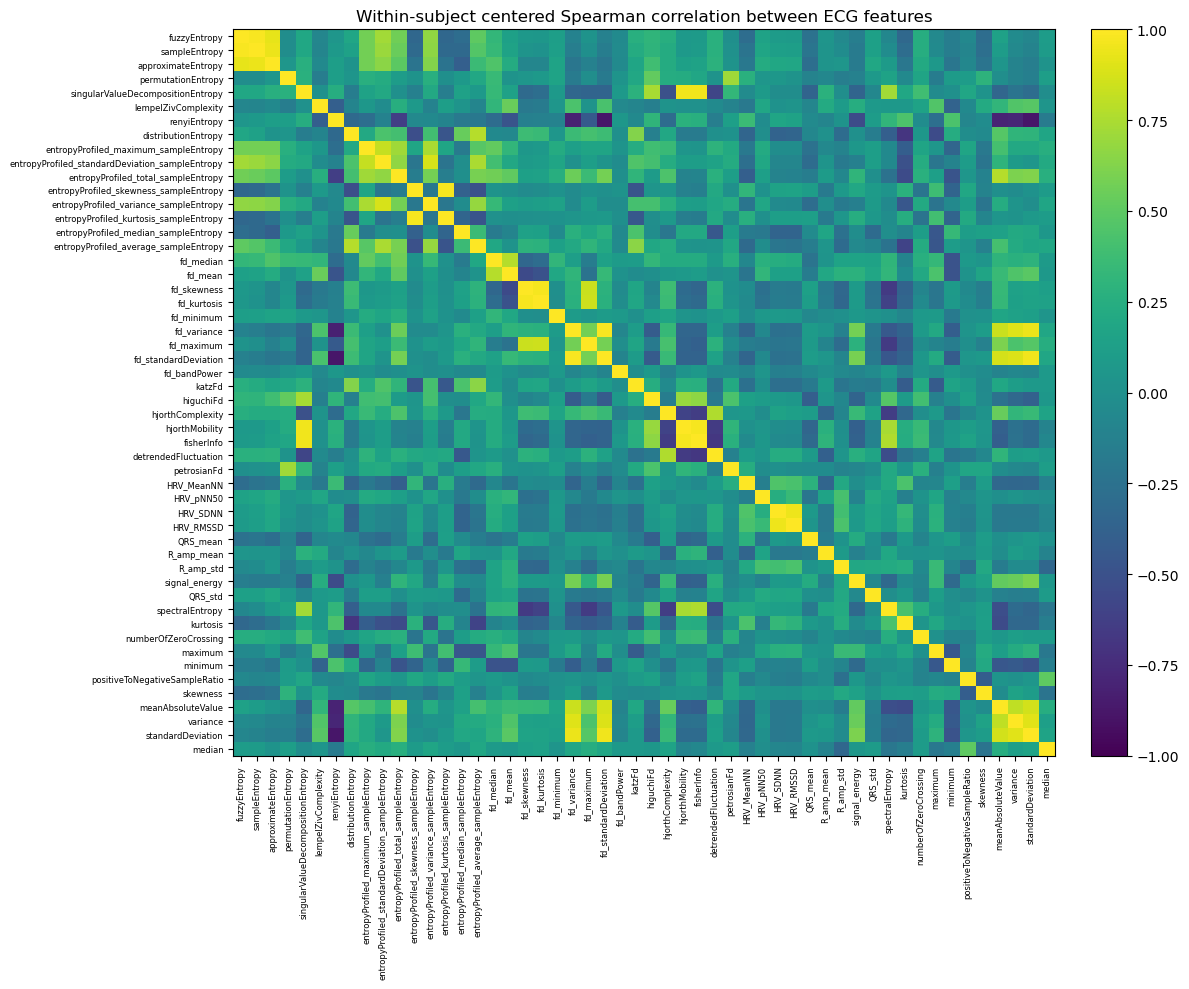

Section 10 complete: within-subject centered correlation and redundancy analysis finished.
This section is descriptive and is used for redundancy filtering, not formal inference.
Tables saved to: analysis_outputs/tables
Figure saved to: analysis_outputs/figures/06_within_subject_spearman_correlation_heatmap.png



,item,value
0,Informative features included in correlation a...,52
1,High-correlation pairs with |rho| >= 0.85,20
2,High-correlation pairs with |rho| >= 0.90,13
3,Redundancy clusters at |rho| >= 0.85,7
4,Redundancy clusters at |rho| >= 0.90,6
5,Features retained after rho 0.90 redundancy fi...,42
6,Features removed by rho 0.90 redundancy filtering,10


Top high-correlation pairs at |rho| >= 0.90:


,feature_a,feature_b,spearman_rho,absolute_spearman_rho,threshold
0,sampleEntropy,fuzzyEntropy,0.981641,0.981641,0.9
1,fd_standardDeviation,fd_variance,0.979982,0.979982,0.9
2,hjorthMobility,fisherInfo,0.974053,0.974053,0.9
3,entropyProfiled_kurtosis_sampleEntropy,entropyProfiled_skewness_sampleEntropy,0.973683,0.973683,0.9
4,fd_kurtosis,fd_skewness,0.969020,0.969020,0.9
5,standardDeviation,fd_standardDeviation,0.958816,0.958816,0.9
6,singularValueDecompositionEntropy,fisherInfo,0.957568,0.957568,0.9
7,singularValueDecompositionEntropy,hjorthMobility,0.953753,0.953753,0.9
8,HRV_SDNN,HRV_RMSSD,0.952446,0.952446,0.9
9,approximateEntropy,sampleEntropy,0.940304,0.940304,0.9


Redundancy clusters:


,threshold,cluster_id,n_features_in_cluster,features_in_cluster
0,0.85,rho_085_cluster_01,2,HRV_RMSSD; HRV_SDNN
1,0.85,rho_085_cluster_02,3,approximateEntropy; fuzzyEntropy; sampleEntropy
2,0.85,rho_085_cluster_03,2,entropyProfiled_kurtosis_sampleEntropy; entrop...
3,0.85,rho_085_cluster_04,2,entropyProfiled_standardDeviation_sampleEntrop...
4,0.85,rho_085_cluster_05,2,fd_kurtosis; fd_skewness
5,0.85,rho_085_cluster_06,6,fd_standardDeviation; fd_variance; meanAbsolut...
6,0.85,rho_085_cluster_07,3,fisherInfo; hjorthMobility; singularValueDecom...
7,0.90,rho_09_cluster_01,2,HRV_RMSSD; HRV_SDNN
8,0.90,rho_09_cluster_02,3,approximateEntropy; fuzzyEntropy; sampleEntropy
9,0.90,rho_09_cluster_03,2,entropyProfiled_kurtosis_sampleEntropy; entrop...


Cluster representatives:


,threshold,cluster_id,n_features_in_cluster,representative_feature,representative_feature_family,representative_priority_score,representative_direction_consistency,representative_absolute_rank_biserial_effect_size,representative_lmm_agrees_with_paired_direction,representative_lmm_fdr_significant,features_in_cluster
0,0.85,rho_085_cluster_01,2,HRV_SDNN,HRV,4.953972,0.55,0.152381,True,True,HRV_SDNN; HRV_RMSSD
1,0.85,rho_085_cluster_02,3,fuzzyEntropy,Entropy / complexity,6.444152,0.65,0.497076,True,True,fuzzyEntropy; sampleEntropy; approximateEntropy
2,0.85,rho_085_cluster_03,2,entropyProfiled_skewness_sampleEntropy,Entropy-profile aggregates,3.409524,0.60,0.304762,True,False,entropyProfiled_skewness_sampleEntropy; entrop...
3,0.85,rho_085_cluster_04,2,entropyProfiled_standardDeviation_sampleEntropy,Entropy-profile aggregates,4.659524,0.55,0.504762,True,True,entropyProfiled_standardDeviation_sampleEntrop...
4,0.85,rho_085_cluster_05,2,fd_skewness,FD-summary aggregates,3.576190,0.50,0.038095,True,True,fd_skewness; fd_kurtosis
5,0.85,rho_085_cluster_06,6,fd_variance,FD-summary aggregates,2.971429,0.60,0.085714,False,True,fd_variance; renyiEntropy; meanAbsoluteValue; ...
6,0.85,rho_085_cluster_07,3,singularValueDecompositionEntropy,Entropy / complexity,3.871429,0.50,0.185714,False,True,singularValueDecompositionEntropy; hjorthMobil...
7,0.90,rho_09_cluster_01,2,HRV_SDNN,HRV,4.953972,0.55,0.152381,True,True,HRV_SDNN; HRV_RMSSD
8,0.90,rho_09_cluster_02,3,fuzzyEntropy,Entropy / complexity,6.444152,0.65,0.497076,True,True,fuzzyEntropy; sampleEntropy; approximateEntropy
9,0.90,rho_09_cluster_03,2,entropyProfiled_skewness_sampleEntropy,Entropy-profile aggregates,3.409524,0.60,0.304762,True,False,entropyProfiled_skewness_sampleEntropy; entrop...


Top redundancy-filtered features using |rho| >= 0.90:


,feature,feature_family,selected_reason,representative_priority_score,direction_consistency,absolute_rank_biserial_effect_size,lmm_agrees_with_paired_direction,lmm_global_bh_fdr_significant,bootstrap_ci_excludes_zero,known_artifact_or_rhythm_sensitive,highly_derived_aggregate
0,HRV_MeanNN,HRV,not_in_rho_0_90_cluster,7.239686,0.75,0.495238,True,True,True,True,False
1,kurtosis,Time-domain statistics,not_in_rho_0_90_cluster,6.816667,0.75,0.533333,True,False,True,False,False
2,fuzzyEntropy,Entropy / complexity,representative_of_rho_0_90_cluster,6.444152,0.65,0.497076,True,True,False,False,False
3,HRV_pNN50,HRV,not_in_rho_0_90_cluster,6.073020,0.65,0.561905,True,True,False,True,False
4,QRS_mean,Morphology / signal quality,not_in_rho_0_90_cluster,5.938887,0.60,0.571429,True,True,False,True,False
5,spectralEntropy,Spectral,not_in_rho_0_90_cluster,5.485714,0.50,0.242857,True,True,False,False,False
6,katzFd,Fractal / nonlinear,not_in_rho_0_90_cluster,5.484211,0.60,0.342105,True,True,False,False,False
7,numberOfZeroCrossing,Time-domain statistics,not_in_rho_0_90_cluster,5.409524,0.60,0.304762,True,True,False,False,False
8,maximum,Time-domain statistics,not_in_rho_0_90_cluster,5.400000,0.60,0.300000,True,True,False,False,False
9,R_amp_mean,Morphology / signal quality,not_in_rho_0_90_cluster,5.332543,0.60,0.266667,True,True,False,True,False


In [18]:
# -----------------------------
# Section 10 — Within-subject centered Spearman correlation and redundancy analysis
# -----------------------------
# This section continues from Sections 1–9. It uses:
#   - df_quality: dataframe with clinical and quality flags from Section 5
#   - informative_features: final non-constant feature list from Section 3
#   - primary_paired_results: paired patient-level results from Section 7, if available
#   - lmm_full_cohort_results: supportive LMM results from Section 9, if available
#   - TABLES_DIR: output table directory
#   - FIGURES_DIR: output figure directory
#
# Goal:
#   Identify redundant feature groups using within-subject centered Spearman correlation.
#
# Important:
#   This is descriptive redundancy mapping, not formal inference.

# -----------------------------
# 10.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "informative_features",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 10 expects Sections 1–9 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# Create FIGURES_DIR if it was not already defined.
if "FIGURES_DIR" not in globals():
    FIGURES_DIR = TABLES_DIR.parent / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Optional plotting imports.
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict, deque

# Work on a copy.
df_corr = df_quality.copy()
df_corr["Patient_id"] = df_corr["Patient_id"].astype(str)

# Keep only informative features that are available.
informative_features = [
    feature for feature in informative_features
    if feature in df_corr.columns
]

# -----------------------------
# 10.2 Load supporting result tables if they are not already in memory
# -----------------------------
if "primary_paired_results" in globals():
    paired_for_redundancy = primary_paired_results.copy()
else:
    paired_path = TABLES_DIR / "39_primary_paired_feature_results.csv"
    if paired_path.exists():
        paired_for_redundancy = pd.read_csv(paired_path)
    else:
        paired_for_redundancy = pd.DataFrame()

if "lmm_full_cohort_results" in globals():
    lmm_for_redundancy = lmm_full_cohort_results.copy()
else:
    lmm_path = TABLES_DIR / "49_lmm_full_cohort_results.csv"
    if lmm_path.exists():
        lmm_for_redundancy = pd.read_csv(lmm_path)
    else:
        lmm_for_redundancy = pd.DataFrame()

if "feature_dictionary" in globals():
    feature_dictionary_for_redundancy = feature_dictionary.copy()
else:
    feature_dictionary_path = TABLES_DIR / "10_feature_dictionary.csv"
    if feature_dictionary_path.exists():
        feature_dictionary_for_redundancy = pd.read_csv(feature_dictionary_path)
    else:
        feature_dictionary_for_redundancy = pd.DataFrame()

# -----------------------------
# 10.3 Create within-subject centered feature matrix
# -----------------------------
# Convert features to numeric.
feature_matrix = df_corr[informative_features].apply(
    pd.to_numeric,
    errors="coerce"
)

# Subtract each patient's feature-specific mean.
patient_feature_means = (
    feature_matrix
    .groupby(df_corr["Patient_id"])
    .transform("mean")
)

centered_feature_matrix = feature_matrix - patient_feature_means

# Save centered feature matrix with identifiers for traceability.
id_columns_for_centered = [
    column for column in [
        "Sl_No", "Patient_id", "Class", "Condition", "Episode_Label", "Segment_Number"
    ]
    if column in df_corr.columns
]

centered_feature_matrix_with_ids = pd.concat(
    [
        df_corr[id_columns_for_centered].reset_index(drop=True),
        centered_feature_matrix.reset_index(drop=True),
    ],
    axis=1,
)

# -----------------------------
# 10.4 Compute within-subject centered Spearman correlation matrix
# -----------------------------
within_subject_spearman_corr = centered_feature_matrix.corr(
    method="spearman",
    min_periods=10,
)

# -----------------------------
# 10.5 Identify highly correlated feature pairs
# -----------------------------
def get_high_correlation_pairs(corr_matrix, thresholds=(0.85, 0.90)):
    """
    Return high-correlation feature pairs for specified absolute rho thresholds.
    """
    rows = []
    features = corr_matrix.columns.tolist()

    for feature_a, feature_b in itertools.combinations(features, 2):
        rho = corr_matrix.loc[feature_a, feature_b]

        if pd.isna(rho):
            continue

        abs_rho = abs(rho)

        for threshold in thresholds:
            if abs_rho >= threshold:
                rows.append({
                    "feature_a": feature_a,
                    "feature_b": feature_b,
                    "spearman_rho": float(rho),
                    "absolute_spearman_rho": float(abs_rho),
                    "threshold": threshold,
                })

    return pd.DataFrame(rows)


high_correlation_pairs_all_thresholds = get_high_correlation_pairs(
    within_subject_spearman_corr,
    thresholds=(0.85, 0.90),
)

high_correlation_pairs_085 = (
    high_correlation_pairs_all_thresholds[
        high_correlation_pairs_all_thresholds["threshold"] == 0.85
    ]
    .sort_values(
        ["absolute_spearman_rho", "feature_a", "feature_b"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)

high_correlation_pairs_090 = (
    high_correlation_pairs_all_thresholds[
        high_correlation_pairs_all_thresholds["threshold"] == 0.90
    ]
    .sort_values(
        ["absolute_spearman_rho", "feature_a", "feature_b"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)

# -----------------------------
# 10.6 Build redundancy clusters from high-correlation pairs
# -----------------------------
def build_correlation_clusters(high_pairs, threshold):
    """
    Build connected components from high-correlation feature pairs.

    A cluster means features are connected by one or more pairwise correlations
    above the specified threshold.
    """
    pairs = high_pairs[high_pairs["threshold"] == threshold].copy()

    graph = defaultdict(set)

    for _, row in pairs.iterrows():
        a = row["feature_a"]
        b = row["feature_b"]
        graph[a].add(b)
        graph[b].add(a)

    visited = set()
    clusters = []

    for feature in sorted(graph.keys()):
        if feature in visited:
            continue

        queue = deque([feature])
        visited.add(feature)
        component = []

        while queue:
            current = queue.popleft()
            component.append(current)

            for neighbor in graph[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)

        clusters.append(sorted(component))

    cluster_rows = []

    for i, cluster_features in enumerate(clusters, start=1):
        cluster_rows.append({
            "threshold": threshold,
            "cluster_id": f"rho_{str(threshold).replace('.', '')}_cluster_{i:02d}",
            "n_features_in_cluster": len(cluster_features),
            "features_in_cluster": "; ".join(cluster_features),
        })

    return pd.DataFrame(cluster_rows)


clusters_085 = build_correlation_clusters(
    high_correlation_pairs_all_thresholds,
    threshold=0.85,
)

clusters_090 = build_correlation_clusters(
    high_correlation_pairs_all_thresholds,
    threshold=0.90,
)

redundancy_clusters = pd.concat(
    [clusters_085, clusters_090],
    ignore_index=True,
)

# -----------------------------
# 10.7 Create feature prioritization table for representative selection
# -----------------------------
feature_priority = pd.DataFrame({
    "feature": informative_features,
})

# Add feature family.
if not feature_dictionary_for_redundancy.empty:
    possible_feature_columns = ["feature", "Feature", "feature_name"]
    possible_family_columns = ["family", "Feature_Family", "feature_family"]

    feature_col = next(
        (col for col in possible_feature_columns if col in feature_dictionary_for_redundancy.columns),
        None,
    )

    family_col = next(
        (col for col in possible_family_columns if col in feature_dictionary_for_redundancy.columns),
        None,
    )

    if feature_col is not None and family_col is not None:
        feature_priority = feature_priority.merge(
            feature_dictionary_for_redundancy[[feature_col, family_col]].rename(
                columns={
                    feature_col: "feature",
                    family_col: "feature_family",
                }
            ),
            on="feature",
            how="left",
        )
    else:
        feature_priority["feature_family"] = "Unassigned"
else:
    feature_priority["feature_family"] = "Unassigned"

# Add paired-analysis metrics.
if not paired_for_redundancy.empty:
    paired_columns_to_keep = [
        column for column in [
            "feature",
            "direction_consistency",
            "rank_biserial_effect_size",
            "absolute_rank_biserial_effect_size",
            "wilcoxon_p_value",
            "global_bh_fdr_p_value",
            "family_bh_fdr_p_value",
            "bootstrap_ci_excludes_zero",
            "median_difference",
            "dominant_direction",
            "n_subjects_available",
        ]
        if column in paired_for_redundancy.columns
    ]

    paired_subset = paired_for_redundancy[paired_columns_to_keep].copy()

    if "absolute_rank_biserial_effect_size" not in paired_subset.columns:
        paired_subset["absolute_rank_biserial_effect_size"] = (
            paired_subset["rank_biserial_effect_size"].abs()
        )

    feature_priority = feature_priority.merge(
        paired_subset,
        on="feature",
        how="left",
    )

else:
    feature_priority["direction_consistency"] = np.nan
    feature_priority["rank_biserial_effect_size"] = np.nan
    feature_priority["absolute_rank_biserial_effect_size"] = np.nan
    feature_priority["wilcoxon_p_value"] = np.nan
    feature_priority["global_bh_fdr_p_value"] = np.nan
    feature_priority["family_bh_fdr_p_value"] = np.nan
    feature_priority["bootstrap_ci_excludes_zero"] = False
    feature_priority["median_difference"] = np.nan
    feature_priority["dominant_direction"] = np.nan
    feature_priority["n_subjects_available"] = np.nan

# Add LMM metrics.
if not lmm_for_redundancy.empty:
    lmm_columns_to_keep = [
        column for column in [
            "feature",
            "beta_Class",
            "p_value_Class",
            "lmm_global_bh_fdr_p_value",
            "lmm_global_bh_fdr_significant",
            "lmm_agrees_with_paired_direction",
            "converged",
        ]
        if column in lmm_for_redundancy.columns
    ]

    lmm_subset = lmm_for_redundancy[lmm_columns_to_keep].copy()

    lmm_subset = lmm_subset.rename(
        columns={
            "beta_Class": "lmm_beta_Class",
            "p_value_Class": "lmm_p_value_Class",
            "converged": "lmm_converged",
        }
    )

    feature_priority = feature_priority.merge(
        lmm_subset,
        on="feature",
        how="left",
    )

else:
    feature_priority["lmm_beta_Class"] = np.nan
    feature_priority["lmm_p_value_Class"] = np.nan
    feature_priority["lmm_global_bh_fdr_p_value"] = np.nan
    feature_priority["lmm_global_bh_fdr_significant"] = False
    feature_priority["lmm_agrees_with_paired_direction"] = np.nan
    feature_priority["lmm_converged"] = np.nan

# Add feature-level missingness.
feature_missingness_for_priority = []

for feature in informative_features:
    feature_missingness_for_priority.append({
        "feature": feature,
        "n_missing": int(df_corr[feature].isna().sum()),
        "percent_missing": round(100 * df_corr[feature].isna().mean(), 3),
    })

feature_missingness_for_priority = pd.DataFrame(feature_missingness_for_priority)

feature_priority = feature_priority.merge(
    feature_missingness_for_priority,
    on="feature",
    how="left",
)

# Add interpretability and artefact-prone flags.
# These are transparent heuristic flags for representative selection.
artefact_prone_features = {
    "signal_energy",
    "R_amp_mean",
    "R_amp_std",
    "QRS_mean",
    "QRS_std",
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
}

highly_derived_or_aggregate_keywords = [
    "entropyProfiled_",
    "fd_",
]

feature_priority["known_artifact_or_rhythm_sensitive"] = (
    feature_priority["feature"].isin(artefact_prone_features)
)

feature_priority["highly_derived_aggregate"] = feature_priority["feature"].apply(
    lambda x: any(keyword in x for keyword in highly_derived_or_aggregate_keywords)
)

# Clinical/signal-processing interpretability heuristic.
# Higher values are preferred when selecting cluster representatives.
def interpretability_score(feature, feature_family):
    """
    Transparent heuristic score for feature interpretability.

    This is not a statistical score. It helps choose a representative feature
    when multiple highly correlated features are essentially redundant.
    """
    primary_interpretable_features = {
        "QRS_mean",
        "QRS_std",
        "R_amp_mean",
        "R_amp_std",
        "signal_energy",
        "HRV_MeanNN",
        "HRV_SDNN",
        "HRV_RMSSD",
        "HRV_pNN50",
        "sampleEntropy",
        "approximateEntropy",
        "fuzzyEntropy",
        "spectralEntropy",
        "kurtosis",
        "skewness",
        "standardDeviation",
        "variance",
    }

    if feature in primary_interpretable_features:
        return 3

    if isinstance(feature_family, str) and feature_family in [
        "Entropy / complexity",
        "Fractal / nonlinear",
        "Morphology / signal quality",
        "Time-domain statistics",
        "HRV",
        "Spectral",
    ]:
        return 2

    return 1


feature_priority["interpretability_score"] = feature_priority.apply(
    lambda row: interpretability_score(
        row["feature"],
        row.get("feature_family", "Unassigned"),
    ),
    axis=1,
)

# Representative score.
# This is intentionally simple and auditable.
feature_priority["representative_priority_score"] = (
    3.0 * feature_priority["direction_consistency"].fillna(0)
    + 2.0 * feature_priority["absolute_rank_biserial_effect_size"].fillna(0)
    + 1.0 * feature_priority["bootstrap_ci_excludes_zero"].fillna(False).astype(int)
    + 1.0 * feature_priority["lmm_agrees_with_paired_direction"].fillna(False).astype(int)
    + 1.0 * feature_priority["lmm_global_bh_fdr_significant"].fillna(False).astype(int)
    + 0.5 * feature_priority["interpretability_score"].fillna(0)
    - 0.5 * feature_priority["highly_derived_aggregate"].fillna(False).astype(int)
    - 0.5 * feature_priority["known_artifact_or_rhythm_sensitive"].fillna(False).astype(int)
    - 0.01 * feature_priority["percent_missing"].fillna(0)
)

feature_priority = feature_priority.sort_values(
    [
        "representative_priority_score",
        "direction_consistency",
        "absolute_rank_biserial_effect_size",
        "interpretability_score",
        "feature",
    ],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

# -----------------------------
# 10.8 Select representative features from each cluster
# -----------------------------
def expand_clusters_to_members(cluster_table):
    """
    Convert cluster table with semicolon-separated features into one row per feature.
    """
    rows = []

    for _, row in cluster_table.iterrows():
        features = [
            item.strip()
            for item in row["features_in_cluster"].split(";")
            if item.strip()
        ]

        for feature in features:
            rows.append({
                "threshold": row["threshold"],
                "cluster_id": row["cluster_id"],
                "n_features_in_cluster": row["n_features_in_cluster"],
                "feature": feature,
            })

    return pd.DataFrame(rows)


cluster_members = expand_clusters_to_members(redundancy_clusters)

if not cluster_members.empty:
    cluster_members_with_priority = cluster_members.merge(
        feature_priority,
        on="feature",
        how="left",
    )

    representative_rows = []

    for (threshold, cluster_id), group in cluster_members_with_priority.groupby(
        ["threshold", "cluster_id"]
    ):
        group_sorted = group.sort_values(
            [
                "representative_priority_score",
                "direction_consistency",
                "absolute_rank_biserial_effect_size",
                "interpretability_score",
                "feature",
            ],
            ascending=[False, False, False, False, True],
        )

        representative = group_sorted.iloc[0]

        representative_rows.append({
            "threshold": threshold,
            "cluster_id": cluster_id,
            "n_features_in_cluster": int(representative["n_features_in_cluster"]),
            "representative_feature": representative["feature"],
            "representative_feature_family": representative.get("feature_family", "Unassigned"),
            "representative_priority_score": representative.get("representative_priority_score", np.nan),
            "representative_direction_consistency": representative.get("direction_consistency", np.nan),
            "representative_absolute_rank_biserial_effect_size": representative.get("absolute_rank_biserial_effect_size", np.nan),
            "representative_lmm_agrees_with_paired_direction": representative.get("lmm_agrees_with_paired_direction", np.nan),
            "representative_lmm_fdr_significant": representative.get("lmm_global_bh_fdr_significant", np.nan),
            "features_in_cluster": "; ".join(group_sorted["feature"].tolist()),
        })

    cluster_representatives = pd.DataFrame(representative_rows)

else:
    cluster_members_with_priority = pd.DataFrame()
    cluster_representatives = pd.DataFrame()

# -----------------------------
# 10.9 Identify non-clustered features and create redundancy-filtered list
# -----------------------------
clustered_features_090 = set()

if not cluster_members.empty:
    clustered_features_090 = set(
        cluster_members.loc[
            cluster_members["threshold"] == 0.90,
            "feature"
        ].tolist()
    )

representatives_090 = set()

if not cluster_representatives.empty:
    representatives_090 = set(
        cluster_representatives.loc[
            cluster_representatives["threshold"] == 0.90,
            "representative_feature"
        ].tolist()
    )

nonclustered_features_090 = [
    feature for feature in informative_features
    if feature not in clustered_features_090
]

redundancy_filtered_features_090 = sorted(
    list(representatives_090) + nonclustered_features_090
)

redundancy_filtered_feature_table_090 = pd.DataFrame({
    "feature": redundancy_filtered_features_090,
})

redundancy_filtered_feature_table_090 = redundancy_filtered_feature_table_090.merge(
    feature_priority,
    on="feature",
    how="left",
)

redundancy_filtered_feature_table_090["selected_reason"] = np.where(
    redundancy_filtered_feature_table_090["feature"].isin(representatives_090),
    "representative_of_rho_0_90_cluster",
    "not_in_rho_0_90_cluster",
)

redundancy_filtered_feature_table_090 = redundancy_filtered_feature_table_090.sort_values(
    [
        "representative_priority_score",
        "direction_consistency",
        "absolute_rank_biserial_effect_size",
        "feature",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

# -----------------------------
# 10.10 Save outputs
# -----------------------------
centered_feature_matrix_with_ids.to_csv(
    TABLES_DIR / "53_within_subject_centered_feature_matrix.csv",
    index=False,
)

within_subject_spearman_corr.to_csv(
    TABLES_DIR / "54_within_subject_spearman_correlation_matrix.csv",
)

high_correlation_pairs_all_thresholds.to_csv(
    TABLES_DIR / "55_high_correlation_pairs_all_thresholds.csv",
    index=False,
)

high_correlation_pairs_085.to_csv(
    TABLES_DIR / "56_high_correlation_pairs_rho_085.csv",
    index=False,
)

high_correlation_pairs_090.to_csv(
    TABLES_DIR / "57_high_correlation_pairs_rho_090.csv",
    index=False,
)

redundancy_clusters.to_csv(
    TABLES_DIR / "58_redundancy_clusters.csv",
    index=False,
)

cluster_members_with_priority.to_csv(
    TABLES_DIR / "59_cluster_members_with_priority.csv",
    index=False,
)

cluster_representatives.to_csv(
    TABLES_DIR / "60_cluster_representatives.csv",
    index=False,
)

feature_priority.to_csv(
    TABLES_DIR / "61_feature_priority_for_representative_selection.csv",
    index=False,
)

redundancy_filtered_feature_table_090.to_csv(
    TABLES_DIR / "62_redundancy_filtered_features_rho_090.csv",
    index=False,
)

section_10_summary = pd.DataFrame([
    {
        "item": "Informative features included in correlation analysis",
        "value": len(informative_features),
    },
    {
        "item": "High-correlation pairs with |rho| >= 0.85",
        "value": len(high_correlation_pairs_085),
    },
    {
        "item": "High-correlation pairs with |rho| >= 0.90",
        "value": len(high_correlation_pairs_090),
    },
    {
        "item": "Redundancy clusters at |rho| >= 0.85",
        "value": int((redundancy_clusters["threshold"] == 0.85).sum())
        if not redundancy_clusters.empty
        else 0,
    },
    {
        "item": "Redundancy clusters at |rho| >= 0.90",
        "value": int((redundancy_clusters["threshold"] == 0.90).sum())
        if not redundancy_clusters.empty
        else 0,
    },
    {
        "item": "Features retained after rho 0.90 redundancy filtering",
        "value": len(redundancy_filtered_feature_table_090),
    },
    {
        "item": "Features removed by rho 0.90 redundancy filtering",
        "value": len(informative_features) - len(redundancy_filtered_feature_table_090),
    },
])

section_10_summary.to_csv(
    TABLES_DIR / "63_section_10_summary.csv",
    index=False,
)

# -----------------------------
# 10.11 Create correlation heatmap figure
# -----------------------------
# Keep the heatmap readable by ordering features by family if available.

heatmap_order_table = feature_priority[
    ["feature", "feature_family", "representative_priority_score"]
].copy()

heatmap_order_table["feature_family"] = heatmap_order_table["feature_family"].fillna("Unassigned")

heatmap_order_table = heatmap_order_table.sort_values(
    ["feature_family", "representative_priority_score", "feature"],
    ascending=[True, False, True],
)

ordered_features_for_heatmap = [
    feature for feature in heatmap_order_table["feature"].tolist()
    if feature in within_subject_spearman_corr.columns
]

ordered_corr = within_subject_spearman_corr.loc[
    ordered_features_for_heatmap,
    ordered_features_for_heatmap,
]

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    ordered_corr,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(np.arange(len(ordered_features_for_heatmap)))
ax.set_yticks(np.arange(len(ordered_features_for_heatmap)))

ax.set_xticklabels(
    ordered_features_for_heatmap,
    rotation=90,
    fontsize=6,
)

ax.set_yticklabels(
    ordered_features_for_heatmap,
    fontsize=6,
)

ax.set_title("Within-subject centered Spearman correlation between ECG features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "06_within_subject_spearman_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# -----------------------------
# 10.12 Display compact outputs
# -----------------------------
print("Section 10 complete: within-subject centered correlation and redundancy analysis finished.")
print("This section is descriptive and is used for redundancy filtering, not formal inference.")
print(f"Tables saved to: {TABLES_DIR}")
print(f"Figure saved to: {FIGURES_DIR / '06_within_subject_spearman_correlation_heatmap.png'}\n")

display(section_10_summary)

print("Top high-correlation pairs at |rho| >= 0.90:")
display(high_correlation_pairs_090.head(25))

print("Redundancy clusters:")
display(redundancy_clusters)

print("Cluster representatives:")
display(cluster_representatives)

print("Top redundancy-filtered features using |rho| >= 0.90:")
display(
    redundancy_filtered_feature_table_090[
        [
            "feature",
            "feature_family",
            "selected_reason",
            "representative_priority_score",
            "direction_consistency",
            "absolute_rank_biserial_effect_size",
            "lmm_agrees_with_paired_direction",
            "lmm_global_bh_fdr_significant",
            "bootstrap_ci_excludes_zero",
            "known_artifact_or_rhythm_sensitive",
            "highly_derived_aggregate",
        ]
    ].head(25)
)

## Section 10 — Within-subject centered correlation and redundancy analysis: findings and interpretation

Section 10 examined redundancy among the 52 informative ECG features using within-subject centered Spearman correlation.

This analysis was descriptive. Its purpose was not to test whether features differ between Pre-HI and During-HI, but to identify groups of features that carry overlapping information. This helps avoid selecting multiple highly correlated versions of the same underlying signal as final candidate features.

---

### 1. Overall redundancy summary

| Result | Count |
|---|---:|
| Informative features included | 52 |
| High-correlation pairs with absolute rho ≥ 0.85 | 20 |
| High-correlation pairs with absolute rho ≥ 0.90 | 13 |
| Redundancy clusters at absolute rho ≥ 0.85 | 7 |
| Redundancy clusters at absolute rho ≥ 0.90 | 6 |
| Features retained after rho 0.90 redundancy filtering | 42 |
| Features removed by rho 0.90 redundancy filtering | 10 |

This shows that the expanded 52-feature set contains meaningful redundancy, but it is not completely dominated by duplicate features. Using the stricter absolute rho ≥ 0.90 threshold reduces the feature set from 52 to 42 features.

The rho ≥ 0.90 threshold is a reasonable primary redundancy-filtering threshold because it removes only very highly overlapping features while preserving most of the feature diversity.

---

### 2. Strongest high-correlation pairs

The strongest within-subject centered correlations were:

| Feature pair | Spearman rho |
|---|---:|
| sampleEntropy — fuzzyEntropy | 0.982 |
| fd_standardDeviation — fd_variance | 0.980 |
| hjorthMobility — fisherInfo | 0.974 |
| entropyProfiled_kurtosis_sampleEntropy — entropyProfiled_skewness_sampleEntropy | 0.974 |
| fd_kurtosis — fd_skewness | 0.969 |
| standardDeviation — fd_standardDeviation | 0.959 |
| singularValueDecompositionEntropy — fisherInfo | 0.958 |
| singularValueDecompositionEntropy — hjorthMobility | 0.954 |
| HRV_SDNN — HRV_RMSSD | 0.952 |
| approximateEntropy — sampleEntropy | 0.940 |
| standardDeviation — fd_variance | 0.939 |
| approximateEntropy — fuzzyEntropy | 0.924 |
| standardDeviation — variance | 0.907 |

These correlations are physiologically and mathematically plausible. For example:

- HRV_SDNN and HRV_RMSSD are both measures of RR interval variability.
- sampleEntropy, fuzzyEntropy, and approximateEntropy are all nonlinear complexity measures.
- standardDeviation, variance, fd_standardDeviation, and fd_variance are related dispersion/variability descriptors.
- hjorthMobility, fisherInfo, and singularValueDecompositionEntropy appear to capture overlapping signal-structure information.

This supports the need for redundancy filtering before final feature selection.

---

### 3. Redundancy clusters at absolute rho ≥ 0.90

Using the stricter absolute rho ≥ 0.90 threshold, six redundancy clusters were identified:

| Cluster | Features | Representative selected |
|---|---|---|
| Cluster 1 | HRV_RMSSD, HRV_SDNN | HRV_SDNN |
| Cluster 2 | approximateEntropy, fuzzyEntropy, sampleEntropy | fuzzyEntropy |
| Cluster 3 | entropyProfiled_kurtosis_sampleEntropy, entropyProfiled_skewness_sampleEntropy | entropyProfiled_skewness_sampleEntropy |
| Cluster 4 | fd_kurtosis, fd_skewness | fd_skewness |
| Cluster 5 | fd_standardDeviation, fd_variance, standardDeviation, variance | fd_variance |
| Cluster 6 | fisherInfo, hjorthMobility, singularValueDecompositionEntropy | singularValueDecompositionEntropy |

These clusters show that several feature families contain strongly overlapping measures. This is especially important for entropy, FD-summary, and distributional variability features.

---

### 4. Interpretation of selected representatives

The automatic representative-selection rule chose one feature per redundancy cluster using direction consistency, effect size, LMM agreement, FDR support, missingness, and interpretability.

#### HRV cluster

Cluster:

- HRV_SDNN
- HRV_RMSSD

Representative selected:

- HRV_SDNN

Interpretation:

HRV_SDNN and HRV_RMSSD are highly redundant in this dataset. However, Section 8 showed that HRV features are not robust in the HRV-valid subgroup. Therefore, even though HRV_SDNN was selected as the representative of this redundancy cluster, HRV features should not be prioritized as primary candidates at this stage.

#### Entropy cluster

Cluster:

- approximateEntropy
- sampleEntropy
- fuzzyEntropy

Representative selected:

- fuzzyEntropy

Interpretation:

These three entropy features are highly correlated and should not all be carried forward as independent candidate features. The representative-selection rule chose fuzzyEntropy. However, sampleEntropy and approximateEntropy are also clinically interpretable and commonly used. In the final manuscript, it may be reasonable to discuss this as an “entropy/complexity cluster” rather than overemphasising one specific entropy feature too early.

#### Entropy-profile skewness/kurtosis cluster

Cluster:

- entropyProfiled_kurtosis_sampleEntropy
- entropyProfiled_skewness_sampleEntropy

Representative selected:

- entropyProfiled_skewness_sampleEntropy

Interpretation:

These are highly derived entropy-profile shape features. Although they may contain information, they are less directly interpretable than primary entropy features such as sampleEntropy, approximateEntropy, or fuzzyEntropy. They should be secondary unless they remain robust in later sensitivity analyses.

#### FD skewness/kurtosis cluster

Cluster:

- fd_kurtosis
- fd_skewness

Representative selected:

- fd_skewness

Interpretation:

These FD-summary shape features are highly redundant. Neither currently appears to be among the strongest physiologically interpretable candidates, so they should not be prioritized unless later sensitivity results strongly support them.

#### Variability / dispersion cluster

Cluster:

- fd_standardDeviation
- fd_variance
- standardDeviation
- variance

Representative selected:

- fd_variance

Interpretation:

This cluster captures signal dispersion or variability. The automatic algorithm selected fd_variance, but this choice should be reviewed carefully. From a clinical and signal-processing interpretability standpoint, standardDeviation may be easier to explain than fd_variance. However, standardDeviation was highly correlated with fd_standardDeviation and fd_variance, so only one representative from this group should be retained.

#### Signal-structure cluster

Cluster:

- fisherInfo
- hjorthMobility
- singularValueDecompositionEntropy

Representative selected:

- singularValueDecompositionEntropy

Interpretation:

These features appear to capture overlapping aspects of signal structure or complexity. However, the representative feature had only modest patient-level support. This cluster should be treated as exploratory.

---

### 5. Features retained after rho 0.90 redundancy filtering

After strict redundancy filtering, 42 features were retained. The highest-priority retained features were:

| Feature | Reason retained |
|---|---|
| HRV_MeanNN | Not in rho 0.90 cluster; strong full-cohort paired signal, but HRV-valid results were weak |
| kurtosis | Not in rho 0.90 cluster; strong paired-analysis candidate and bootstrap CI excluded zero |
| fuzzyEntropy | Representative of entropy cluster |
| HRV_pNN50 | Not in rho 0.90 cluster; full-cohort signal, but weakened in HRV-valid analysis |
| QRS_mean | Not in rho 0.90 cluster; strong LMM and paired-analysis support |
| spectralEntropy | Not in rho 0.90 cluster; LMM-supported complexity feature |
| katzFd | Not in rho 0.90 cluster; LMM-supported fractal feature |
| numberOfZeroCrossing | Not in rho 0.90 cluster; LMM-supported time-domain feature |
| maximum | Not in rho 0.90 cluster; LMM-supported time-domain feature |
| R_amp_mean | Not in rho 0.90 cluster; LMM-supported morphology feature |
| entropyProfiled_maximum_sampleEntropy | Not in rho 0.90 cluster; paired and LMM-supported entropy-profile candidate |
| fd_median | Not in rho 0.90 cluster; LMM-supported FD-summary candidate |
| fd_mean | Not in rho 0.90 cluster; LMM-supported FD-summary candidate |

This filtered list is not the final candidate list. It is an intermediate redundancy-reduced feature set that will feed into the final candidate scoring.

---

### 6. Important methodological interpretation

This section confirms that the entropy and nonlinear features should not be interpreted independently one by one.

For example, approximateEntropy, sampleEntropy, and fuzzyEntropy are so highly correlated that selecting all three as separate biomarkers would overstate the evidence. They are better interpreted as a single entropy/complexity feature group.

Similarly, FD-summary and dispersion-related features are strongly redundant. The final model or score should not include multiple members of the same highly correlated cluster unless there is a strong physiological reason.

---

### 7. Implications for candidate feature selection

Based on Section 10, the following features or feature groups should remain under consideration:

#### Strong individual candidates

QRS_mean
- Strong LMM support
- Supported by paired analysis
- Clinically interpretable morphology/conduction feature

kurtosis
- Strongest patient-level paired signal
- Bootstrap CI excluded zero
- Good patient-level direction consistency

fuzzyEntropy
- Representative of the highly correlated entropy cluster:
  approximateEntropy, sampleEntropy, fuzzyEntropy
- LMM-supported
- Represents ECG complexity change

entropyProfiled_maximum_sampleEntropy
- Supported in paired analysis and LMM
- Not removed by rho ≥ 0.90 redundancy filtering
- Represents entropy-profile behaviour

fd_mean
- LMM-supported FD-summary feature
- Represents fractal/complexity information

fd_median
- LMM-supported FD-summary feature
- Similar biological family to fd_mean; we may later keep only one after sensitivity analysis

#### Candidate feature groups

- Entropy/complexity group: fuzzyEntropy, sampleEntropy, approximateEntropy
- FD-summary group: fd_mean, fd_median, fd_variance or related FD summary feature
- Morphology/amplitude group: QRS_mean, R_amp_mean, R_amp_std
- Time-domain distribution group: kurtosis, maximum, numberOfZeroCrossing




#### Downgraded or cautionary groups

- HRV features, because HRV-valid analysis weakened the full-cohort HRV findings
- Highly derived entropy-profile shape features, because interpretability is lower
- Features with strong LMM significance but weak patient-level consistency
- Features selected only because of redundancy scoring but without clear physiological interpretation

---

### 8. Main conclusion from Section 10

The within-subject centered correlation analysis identified substantial redundancy among entropy, HRV variability, FD-summary, and signal-structure features.

Using absolute rho ≥ 0.90 as the strict redundancy threshold reduced the informative feature set from 52 to 42 features.

The most important practical conclusion is that the final candidate feature list should avoid including multiple highly correlated features from the same cluster. Instead, the final scorecard should prioritize features that combine:

- patient-level paired support,
- LMM directional agreement,
- low redundancy,
- clinical interpretability,
- robustness to sensitivity analyses,
- and low susceptibility to known artefacts.

The next step should be sensitivity analysis to test whether the leading candidate features remain stable after excluding clinically important subgroups and signal-quality flagged segments.

# Section 11 — Sensitivity analyses

Section 11 tests whether the leading candidate features remain stable under clinically important alternative analysis conditions.

The primary analysis in Section 7 used the full cohort and compared patient-level median Pre-HI values against patient-level median During-HI values. Section 11 repeats the same paired analysis under predefined sensitivity conditions.

The purpose is not to search for new features, but to test robustness of the current candidate features.

The main candidate features carried forward from Sections 7–10 are:

- `QRS_mean`
- `kurtosis`
- `fuzzyEntropy`
- `entropyProfiled_maximum_sampleEntropy`
- `fd_mean`
- `fd_median`

HRV features are handled separately because Section 8 showed that HRV interpretation is strongly affected by rhythm and pacing confounding.

Essential sensitivity analyses:

1. Exclude Patient 906, the major HRV outlier patient.
2. Exclude atypical HI patients: 57091, 59285, 70447.
3. Clean sinus subgroup only: 8452, 30071, 80436, 88503.
4. Signal-quality filtered analysis using fixed physiological/signal-quality flags.
5. Leave-one-patient-out analysis for top candidate features.
6. HRV-valid subset for HRV features.

Optional/supplementary sensitivity analyses:

1. Exclude ECMO / Tandem Heart / mechanical support patients.
2. Exclude antiarrhythmic exposure patients.
3. BBB-specific analysis for QRS features.
4. Episode_Label descriptive check for top features.

For each sensitivity analysis, the same patient-level paired median method is used:

`During-HI patient median - Pre-HI patient median`

The outputs from this section will be used to decide whether a feature is robust, clinically confounded, or should be downgraded before final candidate scoring.

In [19]:
# -----------------------------
# Section 11 — Sensitivity analyses
# -----------------------------
# This section continues from Sections 1–10. It uses:
#   - df_quality: dataframe with clinical and quality flags from Section 5
#   - informative_features: final non-constant feature list from Section 3
#   - primary_paired_results: Section 7 full-cohort paired results, if available
#   - hrv_valid_paired_results: Section 8 HRV-valid results, if available
#   - TABLES_DIR: output table directory
#
# The aim is to test robustness of the main candidate features under clinically
# important exclusions and subgroup definitions.

# -----------------------------
# 11.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "informative_features",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 11 expects Sections 1–10 to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

# Work on a copy.
df_sensitivity = df_quality.copy()
df_sensitivity["Patient_id"] = df_sensitivity["Patient_id"].astype(str)
df_sensitivity["Class"] = pd.to_numeric(df_sensitivity["Class"], errors="coerce")

# Candidate features from Sections 7–10.
top_candidate_features = [
    "QRS_mean",
    "kurtosis",
    "fuzzyEntropy",
    "entropyProfiled_maximum_sampleEntropy",
    "fd_mean",
    "fd_median",
]

top_candidate_features = [
    feature for feature in top_candidate_features
    if feature in df_sensitivity.columns
]

# HRV features for separate HRV sensitivity summary.
hrv_features = [
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
]

hrv_features = [
    feature for feature in hrv_features
    if feature in df_sensitivity.columns
]

# -----------------------------
# 11.2 Define helper functions if not already available
# -----------------------------
if "matched_rank_biserial" not in globals():
    def matched_rank_biserial(differences):
        d = np.asarray(differences, dtype=float)
        d = d[np.isfinite(d)]
        d = d[d != 0]

        if len(d) == 0:
            return np.nan

        ranks = rankdata(np.abs(d), method="average")
        total_rank_sum = ranks.sum()

        if total_rank_sum == 0:
            return np.nan

        positive_rank_sum = ranks[d > 0].sum()
        negative_rank_sum = ranks[d < 0].sum()

        return float((positive_rank_sum - negative_rank_sum) / total_rank_sum)


if "bootstrap_ci_median_difference" not in globals():
    def bootstrap_ci_median_difference(differences, n_bootstrap=10000, ci=95, seed=2026):
        d = np.asarray(differences, dtype=float)
        d = d[np.isfinite(d)]

        if len(d) == 0:
            return np.nan, np.nan

        rng = np.random.default_rng(seed)
        bootstrap_medians = np.empty(n_bootstrap)

        for i in range(n_bootstrap):
            sample = rng.choice(d, size=len(d), replace=True)
            bootstrap_medians[i] = np.nanmedian(sample)

        alpha = 100 - ci
        lower = np.percentile(bootstrap_medians, alpha / 2)
        upper = np.percentile(bootstrap_medians, 100 - alpha / 2)

        return float(lower), float(upper)


if "safe_wilcoxon" not in globals():
    def safe_wilcoxon(before_values, during_values):
        before = np.asarray(before_values, dtype=float)
        during = np.asarray(during_values, dtype=float)

        valid_mask = np.isfinite(before) & np.isfinite(during)
        before = before[valid_mask]
        during = during[valid_mask]

        if len(before) == 0:
            return np.nan, np.nan

        differences = during - before
        nonzero_differences = differences[
            np.isfinite(differences) & (differences != 0)
        ]

        if len(nonzero_differences) == 0:
            return 0.0, 1.0

        try:
            statistic, p_value = wilcoxon(
                during,
                before,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto",
            )
            return float(statistic), float(p_value)
        except ValueError:
            return np.nan, np.nan


def run_paired_analysis_for_dataset(
    data,
    features,
    analysis_name,
    expected_subject_count=None,
    bootstrap_seed=2026,
):
    """
    Run the same patient-level paired median analysis used in Section 7
    on a specified subset of the data.

    Returns:
        feature-level paired results dataframe
        subject-level long dataframe
    """
    work = data.copy()
    work["Patient_id"] = work["Patient_id"].astype(str)
    work["Class"] = pd.to_numeric(work["Class"], errors="coerce")

    features = [
        feature for feature in features
        if feature in work.columns
    ]

    if expected_subject_count is None:
        expected_subject_count = work["Patient_id"].nunique()

    if len(work) == 0 or len(features) == 0:
        return pd.DataFrame(), pd.DataFrame()

    subject_condition_medians = (
        work
        .groupby(["Patient_id", "Class"], as_index=False)[features]
        .median(numeric_only=True)
    )

    paired_rows = []
    subject_rows = []

    for feature in features:
        paired_wide = (
            subject_condition_medians
            .pivot(
                index="Patient_id",
                columns="Class",
                values=feature,
            )
        )

        if 0 not in paired_wide.columns:
            paired_wide[0] = np.nan

        if 1 not in paired_wide.columns:
            paired_wide[1] = np.nan

        paired_wide = paired_wide[[0, 1]].rename(
            columns={
                0: "PreHI_median",
                1: "HI_median",
            }
        )

        paired_wide = paired_wide.dropna(
            subset=["PreHI_median", "HI_median"]
        ).copy()

        paired_wide["feature"] = feature
        paired_wide["analysis_name"] = analysis_name
        paired_wide["difference_HI_minus_PreHI"] = (
            paired_wide["HI_median"] - paired_wide["PreHI_median"]
        )

        valid_percent_change = (
            paired_wide["PreHI_median"].notna()
            & paired_wide["difference_HI_minus_PreHI"].notna()
            & (paired_wide["PreHI_median"].abs() > np.finfo(float).eps)
        )

        paired_wide["percent_change"] = np.nan
        paired_wide.loc[valid_percent_change, "percent_change"] = (
            100
            * paired_wide.loc[valid_percent_change, "difference_HI_minus_PreHI"]
            / paired_wide.loc[valid_percent_change, "PreHI_median"].abs()
        )

        if len(paired_wide) > 0:
            subject_rows.append(
                paired_wide
                .reset_index()
                [
                    [
                        "analysis_name",
                        "Patient_id",
                        "feature",
                        "PreHI_median",
                        "HI_median",
                        "difference_HI_minus_PreHI",
                        "percent_change",
                    ]
                ]
            )

        before = paired_wide["PreHI_median"].to_numpy(dtype=float)
        during = paired_wide["HI_median"].to_numpy(dtype=float)
        differences = paired_wide["difference_HI_minus_PreHI"].to_numpy(dtype=float)
        percent_changes = paired_wide["percent_change"].to_numpy(dtype=float)

        n_subjects_available = int(len(paired_wide))
        n_increased = int(np.sum(differences > 0))
        n_decreased = int(np.sum(differences < 0))
        n_unchanged = int(np.sum(differences == 0))

        if n_subjects_available > 0:
            direction_consistency = max(
                n_increased,
                n_decreased,
            ) / n_subjects_available
        else:
            direction_consistency = np.nan

        if n_increased > n_decreased:
            dominant_direction = "increased_during_HI"
        elif n_decreased > n_increased:
            dominant_direction = "decreased_during_HI"
        elif n_subjects_available == 0:
            dominant_direction = "not_available"
        else:
            dominant_direction = "tied"

        wilcoxon_statistic, wilcoxon_p_value = safe_wilcoxon(before, during)

        bootstrap_ci_low, bootstrap_ci_high = bootstrap_ci_median_difference(
            differences,
            n_bootstrap=10000,
            ci=95,
            seed=bootstrap_seed,
        )

        paired_rows.append({
            "analysis_name": analysis_name,
            "feature": feature,
            "n_subjects_available": n_subjects_available,
            "n_subjects_expected_in_analysis": expected_subject_count,
            "median_PreHI": (
                float(np.nanmedian(before))
                if np.any(np.isfinite(before))
                else np.nan
            ),
            "median_HI": (
                float(np.nanmedian(during))
                if np.any(np.isfinite(during))
                else np.nan
            ),
            "median_difference": (
                float(np.nanmedian(differences))
                if np.any(np.isfinite(differences))
                else np.nan
            ),
            "bootstrap_ci_95_low_median_difference": bootstrap_ci_low,
            "bootstrap_ci_95_high_median_difference": bootstrap_ci_high,
            "median_percentage_change": (
                float(np.nanmedian(percent_changes))
                if np.any(np.isfinite(percent_changes))
                else np.nan
            ),
            "n_increased": n_increased,
            "n_decreased": n_decreased,
            "n_unchanged": n_unchanged,
            "direction_consistency": direction_consistency,
            "dominant_direction": dominant_direction,
            "wilcoxon_statistic": wilcoxon_statistic,
            "wilcoxon_p_value": wilcoxon_p_value,
            "rank_biserial_effect_size": matched_rank_biserial(differences),
            "bootstrap_ci_excludes_zero": (
                (bootstrap_ci_low > 0) or (bootstrap_ci_high < 0)
                if np.isfinite(bootstrap_ci_low) and np.isfinite(bootstrap_ci_high)
                else False
            ),
        })

    paired_results = pd.DataFrame(paired_rows)

    if len(paired_results) > 0:
        paired_results["bh_fdr_p_value_within_analysis"] = multipletests(
            paired_results["wilcoxon_p_value"].fillna(1.0),
            alpha=0.05,
            method="fdr_bh",
        )[1]

        paired_results["bh_fdr_significant_within_analysis"] = (
            paired_results["bh_fdr_p_value_within_analysis"] < 0.05
        )

        paired_results["absolute_rank_biserial_effect_size"] = (
            paired_results["rank_biserial_effect_size"].abs()
        )

    if len(subject_rows) > 0:
        subject_level = pd.concat(subject_rows, ignore_index=True)
    else:
        subject_level = pd.DataFrame()

    return paired_results, subject_level


# -----------------------------
# 11.3 Define sensitivity analysis cohorts
# -----------------------------

# Essential analysis cohorts for top candidate features.
analysis_specs = []

# 1. Full cohort for top candidate features, included as reference.
analysis_specs.append({
    "analysis_name": "full_cohort_reference_top_features",
    "description": "Full cohort reference analysis for top candidate features",
    "data": df_sensitivity.copy(),
    "features": top_candidate_features,
})

# 2. Exclude Patient 906.
analysis_specs.append({
    "analysis_name": "exclude_patient_906",
    "description": "Exclude major HRV outlier patient 906",
    "data": df_sensitivity[df_sensitivity["Patient_id"] != "906"].copy(),
    "features": top_candidate_features,
})

# 3. Exclude atypical HI patients.
atypical_hi_patients = {"57091", "59285", "70447"}

analysis_specs.append({
    "analysis_name": "exclude_atypical_HI_patients",
    "description": "Exclude atypical HI patients 57091, 59285, 70447",
    "data": df_sensitivity[
        ~df_sensitivity["Patient_id"].isin(atypical_hi_patients)
    ].copy(),
    "features": top_candidate_features,
})

# 4. Clean sinus subgroup.
clean_sinus_patients = {"8452", "30071", "80436", "88503"}

analysis_specs.append({
    "analysis_name": "clean_sinus_subgroup",
    "description": "Clean sinus candidate subgroup only",
    "data": df_sensitivity[
        df_sensitivity["Patient_id"].isin(clean_sinus_patients)
    ].copy(),
    "features": top_candidate_features,
})

# 5. Signal-quality filtered analysis.
# Use fixed quality flags only, not broad IQR flags.
if "any_fixed_quality_flag" in df_sensitivity.columns:
    signal_quality_filtered_data = df_sensitivity[
        ~df_sensitivity["any_fixed_quality_flag"]
    ].copy()
else:
    signal_quality_filtered_data = df_sensitivity.copy()

analysis_specs.append({
    "analysis_name": "fixed_signal_quality_filtered",
    "description": "Exclude segments with fixed physiological/signal-quality flags",
    "data": signal_quality_filtered_data,
    "features": top_candidate_features,
})

# 6. Optional: Exclude mechanical support patients.
mechanical_support_patients = {"1855", "88503", "96879"}

analysis_specs.append({
    "analysis_name": "exclude_mechanical_support",
    "description": "Exclude ECMO/Tandem Heart/mechanical support patients",
    "data": df_sensitivity[
        ~df_sensitivity["Patient_id"].isin(mechanical_support_patients)
    ].copy(),
    "features": top_candidate_features,
})

# 7. Optional: Exclude antiarrhythmic exposure patients.
antiarrhythmic_patients = {"638", "26398", "30851", "1049", "96305"}

analysis_specs.append({
    "analysis_name": "exclude_antiarrhythmic_exposure",
    "description": "Exclude major antiarrhythmic exposure patients",
    "data": df_sensitivity[
        ~df_sensitivity["Patient_id"].isin(antiarrhythmic_patients)
    ].copy(),
    "features": top_candidate_features,
})

# 8. Optional: BBB-specific QRS sensitivity.
bbb_patients = {"638", "27245", "30851", "96879"}

analysis_specs.append({
    "analysis_name": "exclude_BBB_patients_QRS_only",
    "description": "Exclude BBB patients for QRS_mean sensitivity",
    "data": df_sensitivity[
        ~df_sensitivity["Patient_id"].isin(bbb_patients)
    ].copy(),
    "features": ["QRS_mean"] if "QRS_mean" in df_sensitivity.columns else [],
})

# HRV-valid subset for HRV features.
paced_or_icd_patients = {"491", "638", "1049", "27245", "30851"}
continuous_af_patients = {"638", "26398", "90396"}
major_hrv_outlier_patients = {"906"}

hrv_excluded_patients = (
    paced_or_icd_patients
    | continuous_af_patients
    | major_hrv_outlier_patients
)

hrv_valid_data = df_sensitivity[
    ~df_sensitivity["Patient_id"].isin(hrv_excluded_patients)
].copy()

analysis_specs.append({
    "analysis_name": "HRV_valid_subset_HRV_features",
    "description": "HRV-valid subset excluding paced/ICD, continuous AF, and patient 906",
    "data": hrv_valid_data,
    "features": hrv_features,
})

# -----------------------------
# 11.4 Run sensitivity analyses
# -----------------------------
sensitivity_result_tables = []
sensitivity_subject_tables = []
sensitivity_cohort_rows = []

for spec in analysis_specs:
    analysis_name = spec["analysis_name"]
    analysis_data = spec["data"]
    analysis_features = spec["features"]

    n_patients = analysis_data["Patient_id"].nunique()
    n_segments = len(analysis_data)

    n_patients_with_both_classes = (
        analysis_data
        .groupby("Patient_id")["Class"]
        .nunique()
        .loc[lambda x: x == 2]
        .shape[0]
        if n_segments > 0
        else 0
    )

    sensitivity_cohort_rows.append({
        "analysis_name": analysis_name,
        "description": spec["description"],
        "n_patients": n_patients,
        "n_segments": n_segments,
        "n_patients_with_both_PreHI_and_HI": n_patients_with_both_classes,
        "n_features_requested": len(analysis_features),
    })

    paired_results, subject_level = run_paired_analysis_for_dataset(
        data=analysis_data,
        features=analysis_features,
        analysis_name=analysis_name,
        expected_subject_count=n_patients,
        bootstrap_seed=2026,
    )

    sensitivity_result_tables.append(paired_results)

    if not subject_level.empty:
        sensitivity_subject_tables.append(subject_level)

sensitivity_analysis_results = pd.concat(
    sensitivity_result_tables,
    ignore_index=True,
)

sensitivity_subject_level_medians = pd.concat(
    sensitivity_subject_tables,
    ignore_index=True,
)

sensitivity_cohort_summary = pd.DataFrame(sensitivity_cohort_rows)

# -----------------------------
# 11.5 Compare sensitivity results with full-cohort candidate-feature reference
# -----------------------------
# Use Section 7 primary paired results for the reference if available.
if "primary_paired_results" in globals():
    full_primary_reference = primary_paired_results.copy()
else:
    primary_path = TABLES_DIR / "39_primary_paired_feature_results.csv"
    if primary_path.exists():
        full_primary_reference = pd.read_csv(primary_path)
    else:
        full_primary_reference = pd.DataFrame()

reference_features = sorted(
    set(top_candidate_features + hrv_features + ["QRS_mean"])
)

if not full_primary_reference.empty:
    reference_compact = full_primary_reference[
        full_primary_reference["feature"].isin(reference_features)
    ][
        [
            "feature",
            "median_difference",
            "dominant_direction",
            "direction_consistency",
            "wilcoxon_p_value",
            "global_bh_fdr_p_value",
            "family_bh_fdr_p_value",
            "rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero",
        ]
    ].copy()

    reference_compact = reference_compact.rename(
        columns={
            "median_difference": "reference_full_median_difference",
            "dominant_direction": "reference_full_dominant_direction",
            "direction_consistency": "reference_full_direction_consistency",
            "wilcoxon_p_value": "reference_full_wilcoxon_p_value",
            "global_bh_fdr_p_value": "reference_full_global_bh_fdr_p_value",
            "family_bh_fdr_p_value": "reference_full_family_bh_fdr_p_value",
            "rank_biserial_effect_size": "reference_full_rank_biserial_effect_size",
            "bootstrap_ci_excludes_zero": "reference_full_bootstrap_ci_excludes_zero",
        }
    )

    sensitivity_vs_reference = sensitivity_analysis_results.merge(
        reference_compact,
        on="feature",
        how="left",
    )

    sensitivity_vs_reference["direction_agrees_with_full_reference"] = (
        sensitivity_vs_reference["dominant_direction"]
        == sensitivity_vs_reference["reference_full_dominant_direction"]
    )

    sensitivity_vs_reference["sign_agrees_with_full_reference"] = (
        np.sign(sensitivity_vs_reference["median_difference"])
        == np.sign(sensitivity_vs_reference["reference_full_median_difference"])
    )

else:
    sensitivity_vs_reference = sensitivity_analysis_results.copy()
    sensitivity_vs_reference["direction_agrees_with_full_reference"] = np.nan
    sensitivity_vs_reference["sign_agrees_with_full_reference"] = np.nan

# -----------------------------
# 11.6 Leave-one-patient-out analysis for top candidate features
# -----------------------------
leave_one_out_rows = []
all_patients = sorted(
    df_sensitivity["Patient_id"].unique(),
    key=lambda x: int(x)
)

for omitted_patient in all_patients:
    loo_data = df_sensitivity[
        df_sensitivity["Patient_id"] != omitted_patient
    ].copy()

    loo_results, _ = run_paired_analysis_for_dataset(
        data=loo_data,
        features=top_candidate_features,
        analysis_name=f"leave_one_out_exclude_{omitted_patient}",
        expected_subject_count=loo_data["Patient_id"].nunique(),
        bootstrap_seed=2026,
    )

    if len(loo_results) == 0:
        continue

    loo_results["omitted_patient"] = omitted_patient
    leave_one_out_rows.append(loo_results)

leave_one_patient_out_results = pd.concat(
    leave_one_out_rows,
    ignore_index=True,
)

# Summarize leave-one-out robustness per feature.
loo_summary_rows = []

for feature, group in leave_one_patient_out_results.groupby("feature"):
    reference_row = sensitivity_vs_reference[
        (
            sensitivity_vs_reference["analysis_name"] == "full_cohort_reference_top_features"
        )
        & (
            sensitivity_vs_reference["feature"] == feature
        )
    ]

    if len(reference_row) > 0:
        reference_direction = reference_row.iloc[0]["dominant_direction"]
        reference_sign = np.sign(reference_row.iloc[0]["median_difference"])
    else:
        reference_direction = np.nan
        reference_sign = np.nan

    loo_summary_rows.append({
        "feature": feature,
        "n_leave_one_out_runs": len(group),
        "n_runs_same_dominant_direction_as_reference": int(
            (group["dominant_direction"] == reference_direction).sum()
        ),
        "percent_runs_same_dominant_direction_as_reference": round(
            100 * (group["dominant_direction"] == reference_direction).mean(),
            2
        ),
        "n_runs_same_median_difference_sign_as_reference": int(
            (np.sign(group["median_difference"]) == reference_sign).sum()
        ),
        "percent_runs_same_median_difference_sign_as_reference": round(
            100 * (np.sign(group["median_difference"]) == reference_sign).mean(),
            2
        ),
        "min_direction_consistency": float(group["direction_consistency"].min()),
        "median_direction_consistency": float(group["direction_consistency"].median()),
        "max_direction_consistency": float(group["direction_consistency"].max()),
        "min_median_difference": float(group["median_difference"].min()),
        "median_median_difference": float(group["median_difference"].median()),
        "max_median_difference": float(group["median_difference"].max()),
        "n_runs_bootstrap_ci_excludes_zero": int(group["bootstrap_ci_excludes_zero"].sum()),
        "n_runs_raw_p_less_0_05": int((group["wilcoxon_p_value"] < 0.05).sum()),
    })

leave_one_patient_out_summary = pd.DataFrame(loo_summary_rows)

# -----------------------------
# 11.7 Create robustness matrix for top candidate features
# -----------------------------
essential_analysis_names = [
    "full_cohort_reference_top_features",
    "exclude_patient_906",
    "exclude_atypical_HI_patients",
    "clean_sinus_subgroup",
    "fixed_signal_quality_filtered",
]

robustness_rows = []

for feature in top_candidate_features:
    feature_rows = sensitivity_vs_reference[
        (
            sensitivity_vs_reference["feature"] == feature
        )
        & (
            sensitivity_vs_reference["analysis_name"].isin(essential_analysis_names)
        )
    ].copy()

    if len(feature_rows) == 0:
        continue

    full_reference_row = feature_rows[
        feature_rows["analysis_name"] == "full_cohort_reference_top_features"
    ]

    if len(full_reference_row) > 0:
        reference_direction = full_reference_row.iloc[0]["dominant_direction"]
        reference_sign = np.sign(full_reference_row.iloc[0]["median_difference"])
    else:
        reference_direction = feature_rows.iloc[0]["dominant_direction"]
        reference_sign = np.sign(feature_rows.iloc[0]["median_difference"])

    robustness_rows.append({
        "feature": feature,
        "n_essential_sensitivity_analyses_available": len(feature_rows),
        "n_same_dominant_direction_as_reference": int(
            (feature_rows["dominant_direction"] == reference_direction).sum()
        ),
        "percent_same_dominant_direction_as_reference": round(
            100 * (feature_rows["dominant_direction"] == reference_direction).mean(),
            2
        ),
        "n_same_median_difference_sign_as_reference": int(
            (np.sign(feature_rows["median_difference"]) == reference_sign).sum()
        ),
        "percent_same_median_difference_sign_as_reference": round(
            100 * (np.sign(feature_rows["median_difference"]) == reference_sign).mean(),
            2
        ),
        "median_direction_consistency_across_essential_analyses": float(
            feature_rows["direction_consistency"].median()
        ),
        "min_direction_consistency_across_essential_analyses": float(
            feature_rows["direction_consistency"].min()
        ),
        "n_essential_analyses_with_bootstrap_ci_excluding_zero": int(
            feature_rows["bootstrap_ci_excludes_zero"].sum()
        ),
        "n_essential_analyses_with_raw_p_less_0_05": int(
            (feature_rows["wilcoxon_p_value"] < 0.05).sum()
        ),
    })

candidate_feature_robustness_matrix = pd.DataFrame(robustness_rows)

# -----------------------------
# 11.8 Optional Episode_Label descriptive check for top features
# -----------------------------
# This is descriptive only. It does not model episode order.
episode_descriptive_rows = []

if "Episode_Label" in df_sensitivity.columns:
    episode_group_map = {}

    for label in df_sensitivity["Episode_Label"].dropna().unique():
        label_str = str(label)

        if label_str == "PreHI":
            episode_group_map[label_str] = "PreHI"
        elif label_str == "HI":
            episode_group_map[label_str] = "Continuous_HI"
        elif label_str == "HI1":
            episode_group_map[label_str] = "Early_fragmented_HI"
        elif label_str.startswith("HI"):
            episode_group_map[label_str] = "Later_fragmented_HI"
        else:
            episode_group_map[label_str] = "Other"

    df_episode_desc = df_sensitivity.copy()
    df_episode_desc["episode_group"] = (
        df_episode_desc["Episode_Label"]
        .astype(str)
        .map(episode_group_map)
    )

    for feature in top_candidate_features:
        if feature not in df_episode_desc.columns:
            continue

        grouped = (
            df_episode_desc
            .groupby(["Patient_id", "episode_group"])[feature]
            .median()
            .reset_index()
        )

        for episode_group, group_df in grouped.groupby("episode_group"):
            episode_descriptive_rows.append({
                "feature": feature,
                "episode_group": episode_group,
                "n_patients": group_df["Patient_id"].nunique(),
                "median_of_patient_medians": float(group_df[feature].median()),
                "iqr_patient_medians": float(
                    group_df[feature].quantile(0.75)
                    - group_df[feature].quantile(0.25)
                ),
            })

episode_label_descriptive_top_features = pd.DataFrame(episode_descriptive_rows)

# -----------------------------
# 11.9 Save outputs
# -----------------------------
sensitivity_cohort_summary.to_csv(
    TABLES_DIR / "64_sensitivity_cohort_summary.csv",
    index=False,
)

sensitivity_analysis_results.to_csv(
    TABLES_DIR / "65_sensitivity_analysis_results.csv",
    index=False,
)

sensitivity_subject_level_medians.to_csv(
    TABLES_DIR / "66_sensitivity_subject_level_medians.csv",
    index=False,
)

sensitivity_vs_reference.to_csv(
    TABLES_DIR / "67_sensitivity_vs_full_reference.csv",
    index=False,
)

leave_one_patient_out_results.to_csv(
    TABLES_DIR / "68_leave_one_patient_out_results.csv",
    index=False,
)

leave_one_patient_out_summary.to_csv(
    TABLES_DIR / "69_leave_one_patient_out_summary.csv",
    index=False,
)

candidate_feature_robustness_matrix.to_csv(
    TABLES_DIR / "70_candidate_feature_robustness_matrix.csv",
    index=False,
)

episode_label_descriptive_top_features.to_csv(
    TABLES_DIR / "71_episode_label_descriptive_top_features.csv",
    index=False,
)

section_11_summary = pd.DataFrame([
    {
        "item": "Top candidate features tested",
        "value": len(top_candidate_features),
    },
    {
        "item": "HRV features tested in HRV-valid subset",
        "value": len(hrv_features),
    },
    {
        "item": "Sensitivity analysis cohorts run",
        "value": len(analysis_specs),
    },
    {
        "item": "Rows in sensitivity result table",
        "value": len(sensitivity_analysis_results),
    },
    {
        "item": "Leave-one-patient-out runs",
        "value": len(leave_one_patient_out_results),
    },
    {
        "item": "Top candidate features with 100% same median-difference sign across essential sensitivity analyses",
        "value": int(
            (
                candidate_feature_robustness_matrix[
                    "percent_same_median_difference_sign_as_reference"
                ] == 100
            ).sum()
        )
        if not candidate_feature_robustness_matrix.empty
        else 0,
    },
    {
        "item": "Top candidate features with 100% same dominant direction across essential sensitivity analyses",
        "value": int(
            (
                candidate_feature_robustness_matrix[
                    "percent_same_dominant_direction_as_reference"
                ] == 100
            ).sum()
        )
        if not candidate_feature_robustness_matrix.empty
        else 0,
    },
])

section_11_summary.to_csv(
    TABLES_DIR / "72_section_11_summary.csv",
    index=False,
)

# -----------------------------
# 11.10 Display compact outputs
# -----------------------------
print("Section 11 complete: sensitivity analyses finished.")
print("Sensitivity analyses test robustness; they do not replace the primary paired analysis.")
print(f"Tables saved to: {TABLES_DIR}\n")

display(section_11_summary)

print("Sensitivity cohort summary:")
display(sensitivity_cohort_summary)

print("Candidate feature robustness matrix:")
display(candidate_feature_robustness_matrix)

print("Leave-one-patient-out summary:")
display(leave_one_patient_out_summary)

print("Sensitivity results for top candidate features:")
display(
    sensitivity_vs_reference[
        sensitivity_vs_reference["feature"].isin(top_candidate_features)
    ][
        [
            "analysis_name",
            "feature",
            "n_subjects_available",
            "median_difference",
            "bootstrap_ci_95_low_median_difference",
            "bootstrap_ci_95_high_median_difference",
            "median_percentage_change",
            "n_increased",
            "n_decreased",
            "direction_consistency",
            "dominant_direction",
            "wilcoxon_p_value",
            "bh_fdr_p_value_within_analysis",
            "bootstrap_ci_excludes_zero",
            "direction_agrees_with_full_reference",
            "sign_agrees_with_full_reference",
        ]
    ].sort_values(["feature", "analysis_name"])
)

print("Episode_Label descriptive summary for top features:")
display(episode_label_descriptive_top_features)

Section 11 complete: sensitivity analyses finished.
Sensitivity analyses test robustness; they do not replace the primary paired analysis.
Tables saved to: analysis_outputs/tables



,item,value
0,Top candidate features tested,6
1,HRV features tested in HRV-valid subset,4
2,Sensitivity analysis cohorts run,9
3,Rows in sensitivity result table,47
4,Leave-one-patient-out runs,120
5,Top candidate features with 100% same median-d...,4
6,Top candidate features with 100% same dominant...,2


Sensitivity cohort summary:


,analysis_name,description,n_patients,n_segments,n_patients_with_both_PreHI_and_HI,n_features_requested
0,full_cohort_reference_top_features,Full cohort reference analysis for top candida...,20,1260,20,6
1,exclude_patient_906,Exclude major HRV outlier patient 906,19,1202,19,6
2,exclude_atypical_HI_patients,"Exclude atypical HI patients 57091, 59285, 70447",17,1081,17,6
3,clean_sinus_subgroup,Clean sinus candidate subgroup only,4,285,4,6
4,fixed_signal_quality_filtered,Exclude segments with fixed physiological/sign...,20,1199,19,6
5,exclude_mechanical_support,Exclude ECMO/Tandem Heart/mechanical support p...,17,1080,17,6
6,exclude_antiarrhythmic_exposure,Exclude major antiarrhythmic exposure patients,15,967,15,6
7,exclude_BBB_patients_QRS_only,Exclude BBB patients for QRS_mean sensitivity,16,1028,16,1
8,HRV_valid_subset_HRV_features,"HRV-valid subset excluding paced/ICD, continuo...",12,791,12,4


Candidate feature robustness matrix:


...

,feature,n_leave_one_out_runs,n_runs_same_dominant_direction_as_reference,percent_runs_same_dominant_direction_as_reference,n_runs_same_median_difference_sign_as_reference,percent_runs_same_median_difference_sign_as_reference,min_direction_consistency,median_direction_consistency,max_direction_consistency,min_median_difference,median_median_difference,max_median_difference,n_runs_bootstrap_ci_excludes_zero,n_runs_raw_p_less_0_05
0,QRS_mean,20,20,100.0,20,100.0,0.578947,0.578947,0.631579,0.00446,0.010358,0.016255,0,20
1,entropyProfiled_maximum_sampleEntropy,20,20,100.0,20,100.0,0.631579,0.631579,0.684211,-0.32000,-0.255000,-0.190000,0,15
2,fd_mean,20,20,100.0,20,100.0,0.631579,0.631579,0.684211,-0.39000,-0.365000,-0.340000,0,0
3,fd_median,20,20,100.0,20,100.0,0.631579,0.631579,0.684211,-0.25000,-0.162500,-0.075000,0,2
4,fuzzyEntropy,20,20,100.0,20,100.0,0.631579,0.631579,0.684211,-0.02000,-0.020000,-0.020000,0,4
5,kurtosis,20,20,100.0,20,100.0,0.736842,0.736842,0.789474,0.85000,0.992500,1.135000,20,11


Sensitivity results for top candidate features:


,analysis_name,feature,n_subjects_available,median_difference,bootstrap_ci_95_low_median_difference,bootstrap_ci_95_high_median_difference,median_percentage_change,n_increased,n_decreased,direction_consistency,dominant_direction,wilcoxon_p_value,bh_fdr_p_value_within_analysis,bootstrap_ci_excludes_zero,direction_agrees_with_full_reference,sign_agrees_with_full_reference
18,clean_sinus_subgroup,QRS_mean,4,0.023334,-0.000120,0.045220,18.464556,3,1,0.750000,increased_during_HI,0.250000,1.000000,False,True,True
42,exclude_BBB_patients_QRS_only,QRS_mean,16,0.024570,0.003909,0.032306,14.508357,12,4,0.750000,increased_during_HI,0.003357,0.003357,True,True,True
36,exclude_antiarrhythmic_exposure,QRS_mean,15,0.020566,-0.001880,0.032306,11.657953,10,5,0.666667,increased_during_HI,0.021545,0.129272,False,True,True
12,exclude_atypical_HI_patients,QRS_mean,17,0.004460,-0.001414,0.029064,3.396875,10,7,0.588235,increased_during_HI,0.039536,0.180699,False,True,True
30,exclude_mechanical_support,QRS_mean,17,0.020566,-0.001414,0.032306,11.657953,10,7,0.588235,increased_during_HI,0.030518,0.045776,False,True,True
6,exclude_patient_906,QRS_mean,19,0.004460,-0.001414,0.030414,3.396875,11,8,0.578947,increased_during_HI,0.044559,0.079546,False,True,True
24,fixed_signal_quality_filtered,QRS_mean,19,0.005951,-0.001414,0.030260,5.276280,12,7,0.631579,increased_during_HI,0.028931,0.105249,False,True,True
0,full_cohort_reference_top_features,QRS_mean,20,0.010358,-0.000832,0.029739,5.902620,12,8,0.600000,increased_during_HI,0.023951,0.072468,False,True,True
21,clean_sinus_subgroup,entropyProfiled_maximum_sampleEntropy,4,-0.232500,-1.990000,2.570000,-9.084772,2,2,0.500000,tied,1.000000,1.000000,False,False,True
39,exclude_antiarrhythmic_exposure,entropyProfiled_maximum_sampleEntropy,15,-0.320000,-0.615000,0.000000,-16.309013,4,10,0.666667,decreased_during_HI,0.109421,0.195368,False,True,True


Episode_Label descriptive summary for top features:


,feature,episode_group,n_patients,median_of_patient_medians,iqr_patient_medians
0,QRS_mean,Continuous_HI,8,0.195153,0.047581
1,QRS_mean,Early_fragmented_HI,11,0.147398,0.058318
2,QRS_mean,Later_fragmented_HI,12,0.140272,0.027828
3,QRS_mean,PreHI,20,0.134478,0.040398
4,kurtosis,Continuous_HI,8,1.312500,3.165000
5,kurtosis,Early_fragmented_HI,11,7.460000,4.482500
6,kurtosis,Later_fragmented_HI,12,8.795000,9.297500
7,kurtosis,PreHI,20,5.980000,5.906250
8,fuzzyEntropy,Continuous_HI,8,0.225000,0.120000
9,fuzzyEntropy,Early_fragmented_HI,11,0.260000,0.110000


## Section 11 — Sensitivity analyses: findings and interpretation

Section 11 tested whether the six candidate features identified from Sections 7–10 remained stable under clinically important sensitivity analyses.

The candidate features tested were:

- QRS_mean
- kurtosis
- fuzzyEntropy
- entropyProfiled_maximum_sampleEntropy
- fd_mean
- fd_median

In addition, the four HRV features were tested separately in the HRV-valid subset.

---

### 1. Overall sensitivity-analysis summary

| Result | Count |
|---|---:|
| Top candidate features tested | 6 |
| HRV features tested in HRV-valid subset | 4 |
| Sensitivity analysis cohorts run | 9 |
| Rows in sensitivity result table | 47 |
| Leave-one-patient-out runs | 120 |
| Candidate features with 100% same median-difference sign across essential sensitivity analyses | 4 |
| Candidate features with 100% same dominant direction across essential sensitivity analyses | 2 |

The essential sensitivity analyses were:

1. Full-cohort reference analysis
2. Exclusion of Patient 906
3. Exclusion of atypical HI patients
4. Clean sinus subgroup
5. Fixed signal-quality filtered analysis

The optional/supplementary sensitivity analyses included exclusion of mechanical-support patients, exclusion of antiarrhythmic-exposure patients, BBB-specific QRS analysis, HRV-valid analysis, and Episode_Label descriptive summaries.

---

### 2. Robustness across essential sensitivity analyses

The robustness matrix showed different levels of stability across the six candidate features.

| Feature | Same dominant direction across essential analyses | Same median-difference sign across essential analyses | Median direction consistency | Raw p < 0.05 in essential analyses |
|---|---:|---:|---:|---:|
| QRS_mean | 5 / 5 | 5 / 5 | 0.60 | 4 |
| kurtosis | 5 / 5 | 5 / 5 | 0.737 | 1 |
| fuzzyEntropy | 4 / 5 | 4 / 5 | 0.647 | 1 |
| entropyProfiled_maximum_sampleEntropy | 4 / 5 | 5 / 5 | 0.632 | 2 |
| fd_mean | 4 / 5 | 5 / 5 | 0.632 | 0 |
| fd_median | 4 / 5 | 4 / 5 | 0.632 | 0 |

The two most robust features across the essential analyses were:

- QRS_mean
- kurtosis

Both retained the same dominant direction and same median-difference sign in all five essential sensitivity analyses.

QRS_mean showed stronger statistical consistency across sensitivity analyses, whereas kurtosis showed stronger patient-level direction consistency and bootstrap support.

---

### 3. QRS_mean sensitivity interpretation

QRS_mean was one of the most robust features.

Across essential analyses:

- Same dominant direction in 5 / 5 analyses
- Same median-difference sign in 5 / 5 analyses
- Raw p < 0.05 in 4 / 5 analyses
- Median direction consistency across essential analyses: 0.60

The direction was consistently:

> QRS_mean increased during HI.

Important sensitivity findings:

- Full cohort: median difference +0.0104 s, p = 0.024
- Excluding Patient 906: median difference +0.00446 s, p = 0.045
- Excluding atypical HI patients: median difference +0.00446 s, p = 0.040
- Signal-quality filtered analysis: median difference +0.00595 s, p = 0.029
- Excluding BBB patients: median difference +0.02457 s, p = 0.00336, bootstrap CI excluded zero

The BBB-specific analysis is particularly important. QRS_mean remained increased even after excluding BBB patients, and the bootstrap CI excluded zero. This suggests that the QRS_mean signal is not explained only by bundle branch block patients.

Interpretation:

QRS_mean is currently the strongest morphology candidate. It is directionally stable, LMM-supported, and remains meaningful after clinically relevant exclusions. However, because QRS duration is affected by pacing, conduction disease, electrolyte abnormalities, antiarrhythmics, and ischemia, it should still be interpreted as a candidate marker rather than a validated predictor.

---

### 4. Kurtosis sensitivity interpretation

Kurtosis was also highly robust.

Across essential analyses:

- Same dominant direction in 5 / 5 analyses
- Same median-difference sign in 5 / 5 analyses
- Median direction consistency: 0.737
- Bootstrap CI excluded zero in 2 / 5 essential analyses
- Raw p < 0.05 in 1 / 5 essential analyses

The direction was consistently:

> Kurtosis increased during HI.

Important sensitivity findings:

- Full cohort: median difference +0.9925, bootstrap CI +0.3275 to +1.9650
- Excluding Patient 906: median difference +0.8500, bootstrap CI +0.1250 to +1.7300
- Excluding atypical HI patients: median difference +1.1350
- Signal-quality filtered analysis: median difference +0.7750
- Excluding mechanical-support patients: median difference +1.1350, p = 0.00258, bootstrap CI +0.5300 to +2.2000

Leave-one-patient-out analysis showed that kurtosis was especially stable:

- Same direction in 20 / 20 leave-one-out runs
- Bootstrap CI excluded zero in 20 / 20 leave-one-out runs
- Raw p < 0.05 in 11 / 20 leave-one-out runs

Interpretation:

Kurtosis is one of the strongest patient-level candidates. It is not driven by a single patient and remains directionally stable across sensitivity analyses. Increased kurtosis may reflect a change in ECG signal amplitude distribution during HI, potentially due to sharper peaks, altered morphology, or concentrated signal variability. Because kurtosis can also be affected by artefact and signal quality, it should be interpreted with signal-quality sensitivity results in mind.

---

### 5. Entropy / complexity feature sensitivity interpretation

The entropy-related candidates showed moderate robustness.

#### fuzzyEntropy

Across essential analyses:

- Same dominant direction in 4 / 5 analyses
- Same median-difference sign in 4 / 5 analyses
- Median direction consistency: 0.647
- Raw p < 0.05 in 1 / 5 essential analyses

The dominant direction was generally:

> fuzzyEntropy decreased during HI.

However, in the clean sinus subgroup, fuzzyEntropy showed a tied direction:

- 2 patients increased
- 2 patients decreased
- median difference +0.0075

This weakens the interpretation in the clean subgroup.

Leave-one-patient-out analysis was more stable:

- Same dominant direction in 20 / 20 leave-one-out runs
- Same median-difference sign in 20 / 20 leave-one-out runs
- Raw p < 0.05 in 4 / 20 leave-one-out runs

Interpretation:

fuzzyEntropy remains a candidate representative of the entropy/complexity cluster, but its signal is weaker than QRS_mean and kurtosis. It is best interpreted as part of a broader entropy/complexity feature group rather than as a standalone validated predictor.

#### entropyProfiled_maximum_sampleEntropy

Across essential analyses:

- Same dominant direction in 4 / 5 analyses
- Same median-difference sign in 5 / 5 analyses
- Median direction consistency: 0.632
- Raw p < 0.05 in 2 / 5 essential analyses

The direction was generally:

> entropyProfiled_maximum_sampleEntropy decreased during HI.

However, the clean sinus subgroup again showed a tied direction, reducing confidence in this feature as a clean sinus marker.

Leave-one-patient-out analysis showed strong stability:

- Same dominant direction in 20 / 20 leave-one-out runs
- Same median-difference sign in 20 / 20 leave-one-out runs
- Raw p < 0.05 in 15 / 20 leave-one-out runs

Interpretation:

entropyProfiled_maximum_sampleEntropy is a strong entropy-profile candidate. It appears more stable than fuzzyEntropy in leave-one-patient-out analysis, but it is more derived and less directly interpretable. It should remain in the candidate set, but it should be discussed as an entropy-profile feature rather than a primary physiological marker.

---

### 6. Fractal-dimension summary features

The FD-summary features showed stable direction but weaker statistical support.

#### fd_mean

Across essential analyses:

- Same dominant direction in 4 / 5 analyses
- Same median-difference sign in 5 / 5 analyses
- Median direction consistency: 0.632
- Raw p < 0.05 in 0 / 5 essential analyses

The direction was generally:

> fd_mean decreased during HI.

Leave-one-patient-out analysis showed:

- Same dominant direction in 20 / 20 runs
- Same median-difference sign in 20 / 20 runs
- Raw p < 0.05 in 0 / 20 runs

Interpretation:

fd_mean is directionally stable but statistically weak. It may reflect reduced signal complexity during HI, but current evidence is not strong enough to prioritize it as a top final feature unless supported by the final scorecard.

#### fd_median

Across essential analyses:

- Same dominant direction in 4 / 5 analyses
- Same median-difference sign in 4 / 5 analyses
- Median direction consistency: 0.632
- Raw p < 0.05 in 0 / 5 essential analyses

In the clean sinus subgroup, fd_median changed sign and showed a small positive median difference. This weakens its robustness.

Leave-one-patient-out analysis showed:

- Same dominant direction in 20 / 20 runs
- Same median-difference sign in 20 / 20 runs
- Raw p < 0.05 in 2 / 20 runs

Interpretation:

fd_median is less convincing than fd_mean. Since fd_mean and fd_median are related and both represent FD-summary behaviour, it may be sufficient to carry only one FD-summary representative forward. Based on the current results, fd_mean is slightly preferable to fd_median.

---

### 7. Clean sinus subgroup interpretation

The clean sinus subgroup included only four patients:

- 8452
- 30071
- 80436
- 88503

Because n = 4, this analysis is underpowered and should be interpreted cautiously.

In this subgroup:

- QRS_mean increased in 3 / 4 patients
- kurtosis increased in 3 / 4 patients
- fuzzyEntropy was tied
- entropyProfiled_maximum_sampleEntropy was tied
- fd_mean was tied
- fd_median was tied and changed sign

Interpretation:

QRS_mean and kurtosis are the only candidate features that showed a consistent direction in the clean sinus subgroup. Entropy and FD-summary features were not clearly preserved in this small subgroup.

This supports prioritising QRS_mean and kurtosis as the strongest candidates so far.

In the **clean sinus subgroup**:

## Clean sinus subgroup: patients causing decreases

The clean sinus subgroup included four patients:

- 8452
- 30071
- 80436
- 88503

### QRS_mean

Only one patient showed a decrease in QRS_mean during HI:

| Patient ID | Pre-HI median | HI median | Difference |
|---|---:|---:|---:|
| 8452 | 0.136852 | 0.136732 | -0.000120 |

So, the patient causing the decrease in QRS_mean was:

**Patient 8452**

However, this decrease was extremely small.

### Kurtosis

Only one patient showed a decrease in kurtosis during HI:

| Patient ID | Pre-HI median | HI median | Difference |
|---|---:|---:|---:|
| 88503 | 6.890 | -0.375 | -7.265 |

So, the patient causing the decrease in kurtosis was:

**Patient 88503**

This was a large decrease and is the main reason why kurtosis was not increased in all four clean sinus patients.

### Summary

| Feature | Patient with decrease | Interpretation |
|---|---|---|
| QRS_mean | 8452 | Very small decrease; likely not clinically meaningful by itself |
| kurtosis | 88503 | Large decrease; this patient drives the opposite-direction result for kurtosis in the clean sinus subgroup |



---

### 8. Leave-one-patient-out robustness

The leave-one-patient-out analysis tested whether any candidate feature was driven by a single patient.

All six features retained the same dominant direction and median-difference sign in 20 / 20 leave-one-out runs.

| Feature | Same direction in leave-one-out runs | Raw p < 0.05 runs | Bootstrap CI excluding zero runs |
|---|---:|---:|---:|
| QRS_mean | 20 / 20 | 20 / 20 | 0 / 20 |
| kurtosis | 20 / 20 | 11 / 20 | 20 / 20 |
| fuzzyEntropy | 20 / 20 | 4 / 20 | 0 / 20 |
| entropyProfiled_maximum_sampleEntropy | 20 / 20 | 15 / 20 | 0 / 20 |
| fd_mean | 20 / 20 | 0 / 20 | 0 / 20 |
| fd_median | 20 / 20 | 2 / 20 | 0 / 20 |

This is reassuring. It suggests that the candidate feature directions are not driven by a single influential patient.

The strongest leave-one-patient-out performers were:

- QRS_mean, because raw p < 0.05 in all 20 leave-one-out runs
- kurtosis, because bootstrap CI excluded zero in all 20 leave-one-out runs
- entropyProfiled_maximum_sampleEntropy, because raw p < 0.05 in 15 / 20 leave-one-out runs

---

### 9. Optional Episode_Label descriptive interpretation

Episode_Label was not used in the primary model, but it was summarized descriptively for top features.

General patterns:

- QRS_mean was higher in HI episode groups than in PreHI.
- Kurtosis was generally higher in HI episode groups than in PreHI.
- fd_mean and fd_median were generally lower in HI episode groups than in PreHI.
- Entropy-related features showed more variable patterns across episode groups.

Because the episode groups are uneven and some episode groups contain few patients, these results should remain descriptive only.

The Episode_Label results do not change the primary interpretation, but they support the decision not to perform formal episode-order modelling in this small cohort.

---

### 10. HRV-valid subset reminder

The HRV-valid subset included 12 patients and tested:

- HRV_MeanNN
- HRV_SDNN
- HRV_RMSSD
- HRV_pNN50

No HRV feature showed strong or corrected evidence in the HRV-valid subset. This confirms the earlier Section 8 conclusion:

> HRV features should not be prioritised as primary predictors in this cohort.

HRV_MeanNN may remain a secondary exploratory feature because its direction was preserved, but HRV features overall are weaker than morphology, kurtosis, and selected entropy/complexity features.

---

### 11. Main conclusion from Section 11

The sensitivity analyses support a tiered interpretation of the candidate features.

#### Strongest current candidates

| Feature | Interpretation |
|---|---|
| QRS_mean | Strongest morphology candidate; stable direction; robust in BBB-exclusion analysis; strong LMM support |
| kurtosis | Strongest patient-level distributional candidate; stable in leave-one-patient-out and bootstrap analyses |

#### Moderate candidates

| Feature | Interpretation |
|---|---|
| entropyProfiled_maximum_sampleEntropy | Stable negative direction and strong leave-one-out support, but more derived and less directly interpretable |
| fuzzyEntropy | Representative entropy/complexity feature; moderate support, but weaker in clean sinus subgroup |

#### Weaker candidates

| Feature | Interpretation |
|---|---|
| fd_mean | Directionally stable but weak statistical support |
| fd_median | Less robust than fd_mean; changed sign in clean sinus subgroup |

#### Downgraded feature family

| Feature family | Reason |
|---|---|
| HRV features | HRV-valid analysis weakened full-cohort findings; strong rhythm and pacing confounding |

Overall, Section 11 suggests that the final feature scorecard should prioritize QRS_mean and kurtosis, retain one entropy/complexity feature group, consider entropyProfiled_maximum_sampleEntropy as a secondary derived feature, and downgrade FD-summary and HRV features unless the final scoring framework provides additional support.

# Section 12 — Limited Episode_Label descriptive check

Section 12 performs a limited descriptive check of the `Episode_Label` column for the leading candidate features.

The main analysis in this notebook uses a binary comparison:

- `Class = 0`: Pre-HI
- `Class = 1`: During-HI

Although the dataset contains more detailed `Episode_Label` values, these labels are not used as formal model terms because the cohort is small and later fragmented HI labels have relatively few observations.

Therefore, this section does not model episode order formally.

Instead, it groups the episode labels into broad categories:

- `PreHI`: Episode_Label = `PreHI`
- `Continuous_HI`: Episode_Label = `HI`
- `Early_fragmented_HI`: Episode_Label = `HI1`
- `Later_fragmented_HI`: Episode_Label = `HI2`, `HI3`, `HI4`, `HI5`, `HI6`

For the top candidate features, this section calculates patient-level median feature values within each episode group and visualizes their distributions.

The purpose is descriptive only:

- Do the leading candidate features show broadly similar behaviour across HI episode groupings?
- Are the observed feature changes limited only to one specific episode label?
- Are later fragmented HI episodes too sparse for formal modelling?

This follows the recommendation that `Episode_Label` should appear in the paper descriptively, but should not be treated as a primary model term.

/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/3347111145.py:279: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/3347111145.py:279: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/3347111145.py:279: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/3347111145.py:279: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3

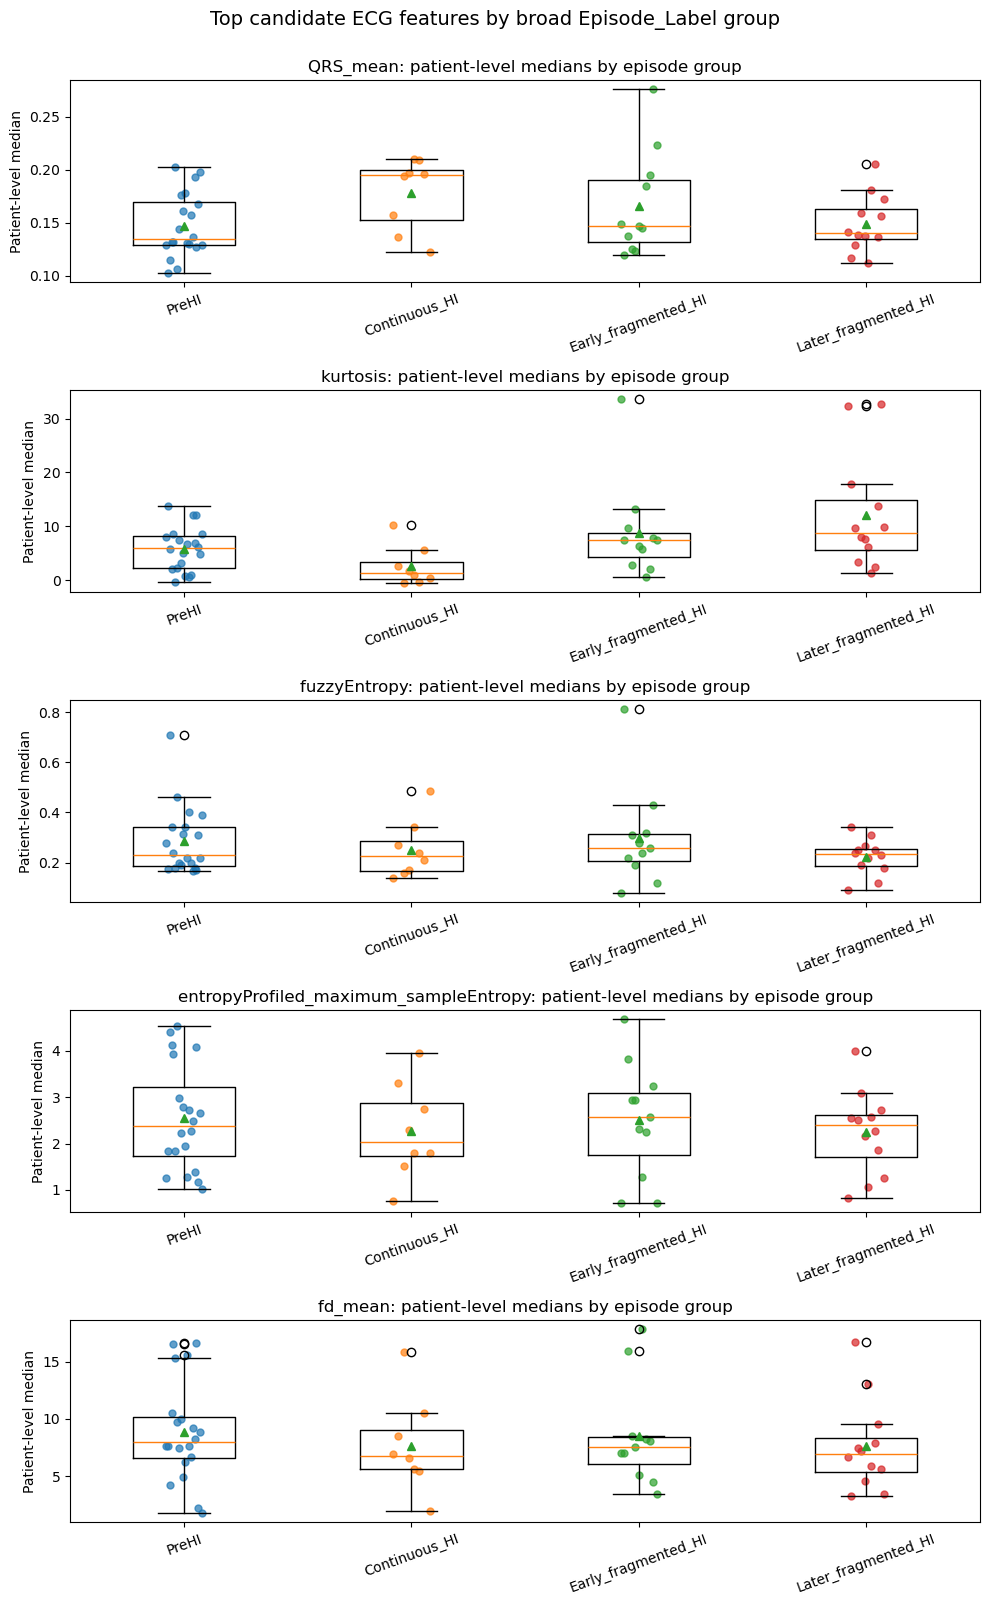

Section 12 complete: limited Episode_Label descriptive check finished.
Episode_Label is described but not used as a formal model term.
Requested table saved to: analysis_outputs/tables/33_episode_label_descriptive_summary_top_features.csv
Requested figure saved to: analysis_outputs/figures/07_top_features_by_episode_group.png

Episode group segment summary:


,episode_group,n_segments,n_patients
0,PreHI,593,20
1,Continuous_HI,241,8
2,Early_fragmented_HI,130,11
3,Later_fragmented_HI,296,12


Episode_Label descriptive summary for top features:


,feature,episode_group,n_patients,median_of_patient_medians,q1_patient_medians,q3_patient_medians,iqr_patient_medians,min_patient_median,max_patient_median,PreHI_reference_median_of_patient_medians,difference_vs_PreHI_reference,percent_difference_vs_PreHI_reference,direction_vs_PreHI_reference
0,QRS_mean,PreHI,20,0.134478,0.129281,0.169679,0.040398,0.103050,0.202810,0.134478,0.000000,0.000000,same_as_PreHI
1,QRS_mean,Continuous_HI,8,0.195153,0.152549,0.200129,0.047581,0.122286,0.210281,0.134478,0.060675,45.119167,higher_than_PreHI
2,QRS_mean,Early_fragmented_HI,11,0.147398,0.131874,0.190192,0.058318,0.120157,0.275788,0.134478,0.012920,9.607365,higher_than_PreHI
3,QRS_mean,Later_fragmented_HI,12,0.140272,0.134909,0.162737,0.027828,0.112070,0.205845,0.134478,0.005794,4.308296,higher_than_PreHI
4,entropyProfiled_maximum_sampleEntropy,PreHI,20,2.382500,1.725000,3.217500,1.492500,1.010000,4.540000,2.382500,0.000000,0.000000,same_as_PreHI
5,entropyProfiled_maximum_sampleEntropy,Continuous_HI,8,2.042500,1.722500,2.881250,1.158750,0.765000,3.965000,2.382500,-0.340000,-14.270724,lower_than_PreHI
6,entropyProfiled_maximum_sampleEntropy,Early_fragmented_HI,11,2.570000,1.760000,3.095000,1.335000,0.720000,4.680000,2.382500,0.187500,7.869885,higher_than_PreHI
7,entropyProfiled_maximum_sampleEntropy,Later_fragmented_HI,12,2.395000,1.716250,2.615000,0.898750,0.815000,4.010000,2.382500,0.012500,0.524659,higher_than_PreHI
8,fd_mean,PreHI,20,7.952500,6.590000,10.145000,3.555000,1.800000,16.650000,7.952500,0.000000,0.000000,same_as_PreHI
9,fd_mean,Continuous_HI,8,6.767500,5.582500,8.993750,3.411250,1.950000,15.810000,7.952500,-1.185000,-14.900975,lower_than_PreHI


Patient-level medians used for plotting:


,Patient_id,episode_group,feature,patient_episode_median
0,10013,PreHI,QRS_mean,0.129303
1,10013,Continuous_HI,QRS_mean,0.157877
2,1049,PreHI,QRS_mean,0.103050
3,1049,Early_fragmented_HI,QRS_mean,0.149303
4,1049,Later_fragmented_HI,QRS_mean,0.141891
5,1855,PreHI,QRS_mean,0.115074
6,1855,Early_fragmented_HI,QRS_mean,0.120157
7,1855,Later_fragmented_HI,QRS_mean,0.117183
8,26398,PreHI,QRS_mean,0.132104
9,26398,Continuous_HI,QRS_mean,0.136564


In [20]:
# -----------------------------
# Section 12 — Limited Episode_Label descriptive check
# -----------------------------
# This section continues from previous sections. It uses:
#   - df_quality: dataframe with Episode_Label and clinical/quality flags
#   - TABLES_DIR: output table directory
#   - FIGURES_DIR: output figure directory, if available
#
# Goal:
#   Describe how top candidate features behave across broad episode groups.
#
# Important:
#   This is descriptive only. Episode_Label is not used as a formal model term.

# -----------------------------
# 12.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "df_quality",
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 12 expects previous sections to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

if "Episode_Label" not in df_quality.columns:
    raise RuntimeError(
        "Episode_Label column is required for Section 12 but was not found."
    )

# Create FIGURES_DIR if not already defined.
if "FIGURES_DIR" not in globals():
    FIGURES_DIR = TABLES_DIR.parent / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

# Work on a copy.
df_episode = df_quality.copy()
df_episode["Patient_id"] = df_episode["Patient_id"].astype(str)
df_episode["Episode_Label"] = df_episode["Episode_Label"].astype(str)

# -----------------------------
# 12.2 Define top candidate features
# -----------------------------
# Current candidate features from Sections 7–11.
# Use top 5 for a compact descriptive figure.
top_episode_features = [
    "QRS_mean",
    "kurtosis",
    "fuzzyEntropy",
    "entropyProfiled_maximum_sampleEntropy",
    "fd_mean",
]

top_episode_features = [
    feature for feature in top_episode_features
    if feature in df_episode.columns
]

if len(top_episode_features) == 0:
    raise RuntimeError(
        "None of the requested top candidate features were found in df_quality."
    )

# -----------------------------
# 12.3 Create broad episode groups
# -----------------------------
def map_episode_group(label):
    """
    Map detailed Episode_Label values to broad descriptive episode groups.
    """
    label = str(label)

    if label == "PreHI":
        return "PreHI"

    if label == "HI":
        return "Continuous_HI"

    if label == "HI1":
        return "Early_fragmented_HI"

    if label in ["HI2", "HI3", "HI4", "HI5", "HI6"]:
        return "Later_fragmented_HI"

    return "Other_or_missing"


df_episode["episode_group"] = df_episode["Episode_Label"].apply(map_episode_group)

episode_group_order = [
    "PreHI",
    "Continuous_HI",
    "Early_fragmented_HI",
    "Later_fragmented_HI",
]

df_episode = df_episode[
    df_episode["episode_group"].isin(episode_group_order)
].copy()

df_episode["episode_group"] = pd.Categorical(
    df_episode["episode_group"],
    categories=episode_group_order,
    ordered=True,
)

# -----------------------------
# 12.4 Segment-level and patient-level episode summaries
# -----------------------------
episode_group_segment_summary = (
    df_episode
    .groupby("episode_group", observed=True)
    .agg(
        n_segments=("Patient_id", "size"),
        n_patients=("Patient_id", "nunique"),
    )
    .reset_index()
)

# Patient-level median by Patient_id, episode group, and feature.
patient_episode_feature_medians = (
    df_episode
    .groupby(["Patient_id", "episode_group"], observed=True)[top_episode_features]
    .median(numeric_only=True)
    .reset_index()
)

# Convert to long format.
patient_episode_feature_medians_long = patient_episode_feature_medians.melt(
    id_vars=["Patient_id", "episode_group"],
    value_vars=top_episode_features,
    var_name="feature",
    value_name="patient_episode_median",
)

# Descriptive summary across patient-level medians.
episode_label_descriptive_summary_top_features = (
    patient_episode_feature_medians_long
    .groupby(["feature", "episode_group"], observed=True)
    .agg(
        n_patients=("Patient_id", "nunique"),
        median_of_patient_medians=("patient_episode_median", "median"),
        q1_patient_medians=("patient_episode_median", lambda x: x.quantile(0.25)),
        q3_patient_medians=("patient_episode_median", lambda x: x.quantile(0.75)),
        iqr_patient_medians=("patient_episode_median", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        min_patient_median=("patient_episode_median", "min"),
        max_patient_median=("patient_episode_median", "max"),
    )
    .reset_index()
)

# Add comparison with PreHI median for each feature.
prehi_reference = (
    episode_label_descriptive_summary_top_features[
        episode_label_descriptive_summary_top_features["episode_group"] == "PreHI"
    ][
        ["feature", "median_of_patient_medians"]
    ]
    .rename(
        columns={
            "median_of_patient_medians": "PreHI_reference_median_of_patient_medians"
        }
    )
)

episode_label_descriptive_summary_top_features = (
    episode_label_descriptive_summary_top_features
    .merge(
        prehi_reference,
        on="feature",
        how="left",
    )
)

episode_label_descriptive_summary_top_features[
    "difference_vs_PreHI_reference"
] = (
    episode_label_descriptive_summary_top_features["median_of_patient_medians"]
    - episode_label_descriptive_summary_top_features[
        "PreHI_reference_median_of_patient_medians"
    ]
)

episode_label_descriptive_summary_top_features[
    "percent_difference_vs_PreHI_reference"
] = np.where(
    episode_label_descriptive_summary_top_features[
        "PreHI_reference_median_of_patient_medians"
    ].abs() > np.finfo(float).eps,
    100
    * episode_label_descriptive_summary_top_features[
        "difference_vs_PreHI_reference"
    ]
    / episode_label_descriptive_summary_top_features[
        "PreHI_reference_median_of_patient_medians"
    ].abs(),
    np.nan,
)

# Direction relative to PreHI.
episode_label_descriptive_summary_top_features[
    "direction_vs_PreHI_reference"
] = np.where(
    episode_label_descriptive_summary_top_features[
        "difference_vs_PreHI_reference"
    ] > 0,
    "higher_than_PreHI",
    np.where(
        episode_label_descriptive_summary_top_features[
            "difference_vs_PreHI_reference"
        ] < 0,
        "lower_than_PreHI",
        "same_as_PreHI",
    )
)

# -----------------------------
# 12.5 Save outputs
# -----------------------------
# Requested output name.
episode_label_descriptive_summary_top_features.to_csv(
    TABLES_DIR / "33_episode_label_descriptive_summary_top_features.csv",
    index=False,
)

# Additional traceability tables.
episode_group_segment_summary.to_csv(
    TABLES_DIR / "73_episode_group_segment_summary_section12.csv",
    index=False,
)

patient_episode_feature_medians_long.to_csv(
    TABLES_DIR / "74_patient_episode_feature_medians_long_section12.csv",
    index=False,
)

# -----------------------------
# 12.6 Plot feature distributions by episode group
# -----------------------------
# Plot patient-level medians, not raw segments, to avoid over-weighting patients
# with more 2-minute windows.

n_features = len(top_episode_features)

fig, axes = plt.subplots(
    nrows=n_features,
    ncols=1,
    figsize=(10, 3.2 * n_features),
    sharex=False,
)

if n_features == 1:
    axes = [axes]

for ax, feature in zip(axes, top_episode_features):
    plot_data = patient_episode_feature_medians_long[
        patient_episode_feature_medians_long["feature"] == feature
    ].copy()

    data_by_group = [
        plot_data.loc[
            plot_data["episode_group"] == group,
            "patient_episode_median",
        ].dropna().to_numpy()
        for group in episode_group_order
    ]

    ax.boxplot(
        data_by_group,
        labels=episode_group_order,
        showmeans=True,
    )

    # Overlay individual patient-level medians as points.
    for i, group in enumerate(episode_group_order, start=1):
        values = plot_data.loc[
            plot_data["episode_group"] == group,
            "patient_episode_median",
        ].dropna().to_numpy()

        if len(values) > 0:
            # deterministic small jitter for visibility
            jitter = np.linspace(-0.08, 0.08, len(values))
            ax.scatter(
                np.full(len(values), i) + jitter,
                values,
                alpha=0.7,
                s=25,
            )

    ax.set_title(f"{feature}: patient-level medians by episode group")
    ax.set_ylabel("Patient-level median")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle(
    "Top candidate ECG features by broad Episode_Label group",
    y=1.0,
    fontsize=14,
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "07_top_features_by_episode_group.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# -----------------------------
# 12.7 Display compact outputs
# -----------------------------
print("Section 12 complete: limited Episode_Label descriptive check finished.")
print("Episode_Label is described but not used as a formal model term.")
print(f"Requested table saved to: {TABLES_DIR / '33_episode_label_descriptive_summary_top_features.csv'}")
print(f"Requested figure saved to: {FIGURES_DIR / '07_top_features_by_episode_group.png'}\n")

print("Episode group segment summary:")
display(episode_group_segment_summary)

print("Episode_Label descriptive summary for top features:")
display(episode_label_descriptive_summary_top_features)

print("Patient-level medians used for plotting:")
display(patient_episode_feature_medians_long.head(30))

## Section 12 — Episode_Label descriptive check: findings and interpretation

Section 12 examined whether the top candidate ECG features showed similar descriptive behaviour across broad `Episode_Label` groups.

This section was intentionally descriptive only. `Episode_Label` was not used as a formal model term because the number of patients differs across episode groups and later fragmented HI labels are relatively sparse.

The broad episode groups were:

- `PreHI`
- `Continuous_HI`: Episode_Label = `HI`
- `Early_fragmented_HI`: Episode_Label = `HI1`
- `Later_fragmented_HI`: Episode_Label = `HI2`, `HI3`, `HI4`, `HI5`, `HI6`

The features examined were:

- `QRS_mean`
- `kurtosis`
- `fuzzyEntropy`
- `entropyProfiled_maximum_sampleEntropy`
- `fd_mean`

---

### 1. Episode group sample sizes

| Episode group | Segments | Patients |
|---|---:|---:|
| PreHI | 593 | 20 |
| Continuous_HI | 241 | 8 |
| Early_fragmented_HI | 130 | 11 |
| Later_fragmented_HI | 296 | 12 |

The episode groups are clearly imbalanced. All 20 patients contributed PreHI data, but only 8 patients contributed continuous HI data, 11 patients contributed early fragmented HI data, and 12 patients contributed later fragmented HI data.

This confirms that `Episode_Label` should not be used as a primary modelling variable in this dataset. The episode-group results should be treated as descriptive patterns only.

---

### 2. QRS_mean

| Episode group | Patients | Median of patient medians | Difference vs PreHI | Direction vs PreHI |
|---|---:|---:|---:|---|
| PreHI | 20 | 0.1345 | 0.0000 | Reference |
| Continuous_HI | 8 | 0.1952 | +0.0607 | Higher |
| Early_fragmented_HI | 11 | 0.1474 | +0.0129 | Higher |
| Later_fragmented_HI | 12 | 0.1403 | +0.0058 | Higher |

`QRS_mean` was higher than PreHI in all three HI episode groups.

The increase was largest in the continuous HI group and smaller in the early and later fragmented HI groups.

Interpretation:

This supports the earlier finding that `QRS_mean` increases during HI. The pattern is not limited to only one episode label; it appears across continuous, early fragmented, and later fragmented HI groups.

However, the magnitude varies across episode groups, and the continuous HI group contains only 8 patients. Therefore, this should be interpreted as supportive descriptive evidence rather than formal proof of episode-stage dependence.

---

### 3. Kurtosis

| Episode group | Patients | Median of patient medians | Difference vs PreHI | Direction vs PreHI |
|---|---:|---:|---:|---|
| PreHI | 20 | 5.9800 | 0.0000 | Reference |
| Continuous_HI | 8 | 1.3125 | -4.6675 | Lower |
| Early_fragmented_HI | 11 | 7.4600 | +1.4800 | Higher |
| Later_fragmented_HI | 12 | 8.7950 | +2.8150 | Higher |

`kurtosis` was higher than PreHI in the early fragmented and later fragmented HI groups, but lower in the continuous HI group.

This is an important nuance.

The patient-level paired analysis and sensitivity analysis suggested that kurtosis generally increases during HI. However, this descriptive episode-group check shows that the increase is more apparent in fragmented HI episodes than in the continuous HI group.

Interpretation:

`kurtosis` remains a strong candidate feature, but its behaviour may differ by HI episode type. The lower value in the continuous HI group suggests either:

- different physiology in continuous HI episodes,
- different patient composition in the continuous HI group,
- influence of specific patients with large decreases,
- or heterogeneity in signal morphology during prolonged HI.

Because the continuous HI group includes only 8 patients, this should not be overinterpreted. It should be described as a descriptive inconsistency rather than a reason to discard kurtosis.

---

### 4. fuzzyEntropy

| Episode group | Patients | Median of patient medians | Difference vs PreHI | Direction vs PreHI |
|---|---:|---:|---:|---|
| PreHI | 20 | 0.230 | 0.000 | Reference |
| Continuous_HI | 8 | 0.225 | -0.005 | Lower |
| Early_fragmented_HI | 11 | 0.260 | +0.030 | Higher |
| Later_fragmented_HI | 12 | 0.235 | +0.005 | Higher |

`fuzzyEntropy` showed only small differences across episode groups.

It was slightly lower in continuous HI, but slightly higher in early and later fragmented HI.

Interpretation:

This does not provide strong descriptive support for a consistent `fuzzyEntropy` decrease across all HI episode groups.

Although `fuzzyEntropy` represented the highly correlated entropy cluster in the redundancy analysis, its episode-label behaviour is mixed. This supports treating `fuzzyEntropy` as a moderate or secondary candidate rather than one of the strongest individual predictors.

---

### 5. entropyProfiled_maximum_sampleEntropy

| Episode group | Patients | Median of patient medians | Difference vs PreHI | Direction vs PreHI |
|---|---:|---:|---:|---|
| PreHI | 20 | 2.3825 | 0.0000 | Reference |
| Continuous_HI | 8 | 2.0425 | -0.3400 | Lower |
| Early_fragmented_HI | 11 | 2.5700 | +0.1875 | Higher |
| Later_fragmented_HI | 12 | 2.3950 | +0.0125 | Higher |

`entropyProfiled_maximum_sampleEntropy` was lower in continuous HI but slightly higher in early and later fragmented HI.

This is similar to the pattern observed for `fuzzyEntropy`.

Interpretation:

The feature showed useful support in earlier paired and leave-one-patient-out analyses, but the episode-label descriptive check shows that its behaviour is not uniform across broad episode groups.

This suggests that entropy-profile features may be sensitive to episode composition and patient heterogeneity. It should remain a candidate, but not as a standalone primary feature without further validation.

---

### 6. fd_mean

| Episode group | Patients | Median of patient medians | Difference vs PreHI | Direction vs PreHI |
|---|---:|---:|---:|---|
| PreHI | 20 | 7.9525 | 0.0000 | Reference |
| Continuous_HI | 8 | 6.7675 | -1.1850 | Lower |
| Early_fragmented_HI | 11 | 7.5100 | -0.4425 | Lower |
| Later_fragmented_HI | 12 | 6.9475 | -1.0050 | Lower |

`fd_mean` was lower than PreHI in all three HI episode groups.

This was the most consistent episode-label pattern among the complexity-related features.

Interpretation:

Although `fd_mean` had weaker statistical support in the paired and sensitivity analyses, the Episode_Label descriptive check supports a consistent decrease across HI episode groups.

This suggests that FD-summary behaviour may still capture a relevant reduction in ECG signal complexity during HI. However, because the effect was not strongly significant in sensitivity analyses, `fd_mean` should remain a secondary candidate rather than a top primary feature.

---

### 7. Cross-feature interpretation

The episode-label descriptive check gives the following overall pattern:

| Feature | Episode-label descriptive pattern | Interpretation |
|---|---|---|
| QRS_mean | Higher than PreHI in all HI groups | Strong supportive descriptive evidence |
| kurtosis | Higher in fragmented HI, lower in continuous HI | Strong candidate but heterogeneous across episode type |
| fd_mean | Lower than PreHI in all HI groups | Consistent descriptive complexity decrease, but weaker statistical support |
| fuzzyEntropy | Mixed pattern | Moderate/secondary candidate |
| entropyProfiled_maximum_sampleEntropy | Mixed pattern | Moderate/secondary derived entropy-profile candidate |

The clearest descriptive findings are:

- `QRS_mean` is consistently higher across HI episode groups.
- `fd_mean` is consistently lower across HI episode groups.
- `kurtosis` is higher in fragmented HI groups but lower in continuous HI.
- Entropy features show mixed behaviour by episode grouping.

---

### 8. Main conclusion from Section 12

The Episode_Label descriptive analysis supports the decision to keep the main statistical framework as a binary PreHI versus During-HI comparison.

The episode groups are imbalanced and contain different subsets of patients, so formal episode-order modelling would not be reliable in this 20-patient cohort.

However, the descriptive results are useful for interpretation:

- `QRS_mean` appears to be the most consistent feature across episode groupings.
- `fd_mean` shows a consistent descriptive decrease across all HI episode groups.
- `kurtosis` remains important, but its behaviour differs between continuous and fragmented HI episodes.
- `fuzzyEntropy` and `entropyProfiled_maximum_sampleEntropy` show mixed episode-group patterns and should be interpreted as secondary entropy-related candidates.

Overall, Section 12 strengthens the case for reporting `Episode_Label` descriptively in the paper, while keeping the primary analysis focused on the binary PreHI versus During-HI comparison.

# Section 13 — Candidate feature scoring and ranking

Section 13 integrates the outputs from the previous analyses into a final candidate feature scorecard.

The aim is to move from individual statistical results to a transparent, manuscript-ready feature selection table.

This section combines evidence from:

- primary patient-level paired analysis,
- HRV-valid subgroup analysis,
- supportive mixed-effects model analysis,
- within-subject centered redundancy analysis,
- sensitivity analyses,
- leave-one-patient-out robustness,
- signal-quality and missingness checks,
- and limited Episode_Label descriptive analysis.

The purpose of this scorecard is not to claim that the selected features are validated predictors. Instead, it ranks candidate ECG features according to how consistently they changed from Pre-HI to During-HI in this exploratory 20-patient cohort.

The scoring domains are:

| Domain | Meaning |
|---|---|
| Effect size | Magnitude of patient-level paired effect, using absolute rank-biserial effect size |
| Direction consistency | Proportion of patients changing in the same direction |
| Statistical support | Raw p-value, global FDR, and family-level FDR support |
| Bootstrap support | Whether the bootstrap confidence interval excludes zero |
| LMM agreement | Whether the segment-level mixed model agrees with the patient-level direction |
| HRV-valid support | For HRV features only, whether the HRV-valid subgroup preserves the signal |
| Sensitivity robustness | Whether the feature remains directionally stable after exclusions and subgroup analyses |
| Redundancy | Whether the feature is redundant with a stronger feature |
| Missingness | Whether the feature has low missingness |
| Clinical interpretability | Whether the feature is physiologically plausible and explainable |

Candidate categories are deliberately made non-overlapping:

## Strict candidate

A feature is categorized as a strict candidate if it shows:

- direction consistency of at least 85%, or very strong sensitivity/leave-one-out robustness,
- meaningful patient-level effect size,
- LMM direction agreement,
- strong bootstrap or FDR support,
- robustness in sensitivity analyses,
- low missingness,
- and acceptable interpretability.

Because this is a small exploratory cohort, strict candidacy can also be assigned when a feature has slightly lower direction consistency but has very strong robustness across sensitivity analyses and leave-one-patient-out testing.

## Secondary candidate

A feature is categorized as a secondary candidate if it shows:

- moderate direction consistency,
- meaningful or interpretable effect,
- supportive LMM or sensitivity evidence,
- but weaker statistical, sensitivity, or interpretability support than strict candidates.

Secondary candidates may be biologically interesting but should not be presented as final independent predictors without validation.

## Not prioritized

A feature is not prioritized if it shows:

- low patient-level direction consistency,
- weak effect size,
- lack of LMM agreement,
- weak sensitivity robustness,
- substantial redundancy with a stronger feature,
- HRV/rhythm confounding,
- artefact susceptibility,
- or limited clinical interpretability.

This section produces the final feature selection table for the manuscript.

In [21]:
# -----------------------------
# Section 13 — Candidate feature scoring and ranking
# -----------------------------
# This section integrates:
#   - Section 7: primary paired analysis
#   - Section 8: HRV-valid analysis
#   - Section 9: LMM analysis
#   - Section 10: redundancy filtering
#   - Section 11: sensitivity analysis
#   - Section 12: Episode_Label descriptive check
#
# Goal:
#   Create a manuscript-ready feature scorecard with non-overlapping
#   candidate categories:
#       - Strict candidate
#       - Secondary candidate
#       - Not prioritized

# -----------------------------
# 13.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 13 expects previous sections to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# -----------------------------
# 13.2 Load required output tables
# -----------------------------
def read_table_if_exists(path):
    """
    Read a CSV file if it exists; otherwise return an empty dataframe.
    """
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


primary_paired = read_table_if_exists(
    TABLES_DIR / "39_primary_paired_feature_results.csv"
)

hrv_valid_results = read_table_if_exists(
    TABLES_DIR / "46_hrv_valid_paired_results.csv"
)

lmm_results = read_table_if_exists(
    TABLES_DIR / "49_lmm_full_cohort_results.csv"
)

redundancy_filtered = read_table_if_exists(
    TABLES_DIR / "62_redundancy_filtered_features_rho_090.csv"
)

feature_priority = read_table_if_exists(
    TABLES_DIR / "61_feature_priority_for_representative_selection.csv"
)

cluster_members = read_table_if_exists(
    TABLES_DIR / "59_cluster_members_with_priority.csv"
)

cluster_representatives = read_table_if_exists(
    TABLES_DIR / "60_cluster_representatives.csv"
)

sensitivity_results = read_table_if_exists(
    TABLES_DIR / "67_sensitivity_vs_full_reference.csv"
)

candidate_robustness = read_table_if_exists(
    TABLES_DIR / "70_candidate_feature_robustness_matrix.csv"
)

loo_summary = read_table_if_exists(
    TABLES_DIR / "69_leave_one_patient_out_summary.csv"
)

episode_summary = read_table_if_exists(
    TABLES_DIR / "33_episode_label_descriptive_summary_top_features.csv"
)

feature_dictionary_loaded = read_table_if_exists(
    TABLES_DIR / "10_feature_dictionary.csv"
)

# Basic validation.
if primary_paired.empty:
    raise RuntimeError(
        "Primary paired analysis table was not found. "
        "Expected: 39_primary_paired_feature_results.csv"
    )

# -----------------------------
# 13.3 Define candidate universe
# -----------------------------
# Start with all informative features from the primary analysis.
scorecard = primary_paired.copy()

# Ensure expected columns exist.
required_primary_columns = [
    "feature",
    "direction_consistency",
    "rank_biserial_effect_size",
    "wilcoxon_p_value",
    "global_bh_fdr_p_value",
    "family_bh_fdr_p_value",
    "bootstrap_ci_excludes_zero",
    "median_difference",
    "dominant_direction",
    "n_subjects_available",
]

missing_primary_columns = [
    column for column in required_primary_columns
    if column not in scorecard.columns
]

if missing_primary_columns:
    raise RuntimeError(
        "Primary paired analysis table is missing expected columns: "
        f"{missing_primary_columns}"
    )

scorecard["absolute_rank_biserial_effect_size"] = (
    scorecard["rank_biserial_effect_size"].abs()
)

# -----------------------------
# 13.4 Add feature family — robust version
# -----------------------------
# This block avoids KeyError if the feature-family column has a different name
# or if merge creates feature_family_x / feature_family_y.

# Remove any existing feature-family-like columns before adding a clean one.
feature_family_like_columns = [
    col for col in scorecard.columns
    if col.lower() in ["feature_family", "feature_family_x", "feature_family_y", "family"]
]

if feature_family_like_columns:
    scorecard = scorecard.drop(columns=feature_family_like_columns)

# Default assignment.
scorecard["feature_family"] = "Unassigned"

if not feature_dictionary_loaded.empty:
    possible_feature_columns = [
        "feature",
        "Feature",
        "feature_name",
        "Feature_Name",
        "column_name",
    ]

    possible_family_columns = [
        "feature_family",
        "Feature_Family",
        "family",
        "Family",
        "feature_family_manual",
    ]

    feature_col = next(
        (
            column for column in possible_feature_columns
            if column in feature_dictionary_loaded.columns
        ),
        None,
    )

    family_col = next(
        (
            column for column in possible_family_columns
            if column in feature_dictionary_loaded.columns
        ),
        None,
    )

    if feature_col is not None and family_col is not None:
        family_map = (
            feature_dictionary_loaded[[feature_col, family_col]]
            .drop_duplicates()
            .rename(
                columns={
                    feature_col: "feature",
                    family_col: "feature_family_from_dictionary",
                }
            )
        )

        family_map["feature"] = family_map["feature"].astype(str)
        scorecard["feature"] = scorecard["feature"].astype(str)

        scorecard = scorecard.merge(
            family_map,
            on="feature",
            how="left",
        )

        scorecard["feature_family"] = scorecard[
            "feature_family_from_dictionary"
        ].fillna("Unassigned")

        scorecard = scorecard.drop(
            columns=["feature_family_from_dictionary"]
        )

# Final safety check.
if "feature_family" not in scorecard.columns:
    scorecard["feature_family"] = "Unassigned"

scorecard["feature_family"] = scorecard["feature_family"].fillna("Unassigned")

# -----------------------------
# 13.5 Add LMM support
# -----------------------------
if not lmm_results.empty:
    lmm_columns = [
        column for column in [
            "feature",
            "beta_Class",
            "p_value_Class",
            "lmm_global_bh_fdr_p_value",
            "lmm_global_bh_fdr_significant",
            "lmm_agrees_with_paired_direction",
            "converged",
        ]
        if column in lmm_results.columns
    ]

    lmm_compact = lmm_results[lmm_columns].copy()

    lmm_compact = lmm_compact.rename(
        columns={
            "beta_Class": "lmm_beta_Class",
            "p_value_Class": "lmm_p_value_Class",
            "converged": "lmm_converged",
        }
    )

    scorecard = scorecard.merge(
        lmm_compact,
        on="feature",
        how="left",
    )
else:
    scorecard["lmm_beta_Class"] = np.nan
    scorecard["lmm_p_value_Class"] = np.nan
    scorecard["lmm_global_bh_fdr_p_value"] = np.nan
    scorecard["lmm_global_bh_fdr_significant"] = False
    scorecard["lmm_agrees_with_paired_direction"] = False
    scorecard["lmm_converged"] = False

# Fill boolean LMM columns.
for column in [
    "lmm_global_bh_fdr_significant",
    "lmm_agrees_with_paired_direction",
    "lmm_converged",
]:
    if column in scorecard.columns:
        scorecard[column] = scorecard[column].fillna(False).astype(bool)

# -----------------------------
# 13.6 Add HRV-valid support
# -----------------------------
hrv_features = {
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
}

scorecard["is_HRV_feature"] = scorecard["feature"].isin(hrv_features)

if not hrv_valid_results.empty:
    hrv_compact_columns = [
        column for column in [
            "feature",
            "median_difference",
            "dominant_direction",
            "direction_consistency",
            "wilcoxon_p_value",
            "bh_fdr_p_value_within_analysis",
            "bootstrap_ci_excludes_zero",
            "rank_biserial_effect_size",
        ]
        if column in hrv_valid_results.columns
    ]

    hrv_compact = hrv_valid_results[hrv_compact_columns].copy()

    hrv_compact = hrv_compact.rename(
        columns={
            "median_difference": "hrv_valid_median_difference",
            "dominant_direction": "hrv_valid_dominant_direction",
            "direction_consistency": "hrv_valid_direction_consistency",
            "wilcoxon_p_value": "hrv_valid_wilcoxon_p_value",
            "bh_fdr_p_value_within_analysis": "hrv_valid_bh_fdr_p_value",
            "bootstrap_ci_excludes_zero": "hrv_valid_bootstrap_ci_excludes_zero",
            "rank_biserial_effect_size": "hrv_valid_rank_biserial_effect_size",
        }
    )

    scorecard = scorecard.merge(
        hrv_compact,
        on="feature",
        how="left",
    )

else:
    scorecard["hrv_valid_median_difference"] = np.nan
    scorecard["hrv_valid_dominant_direction"] = np.nan
    scorecard["hrv_valid_direction_consistency"] = np.nan
    scorecard["hrv_valid_wilcoxon_p_value"] = np.nan
    scorecard["hrv_valid_bh_fdr_p_value"] = np.nan
    scorecard["hrv_valid_bootstrap_ci_excludes_zero"] = False
    scorecard["hrv_valid_rank_biserial_effect_size"] = np.nan

scorecard["hrv_valid_direction_agrees_with_full"] = np.where(
    scorecard["is_HRV_feature"],
    scorecard["hrv_valid_dominant_direction"] == scorecard["dominant_direction"],
    np.nan,
)

scorecard["hrv_valid_support_flag"] = np.where(
    scorecard["is_HRV_feature"],
    (
        (scorecard["hrv_valid_direction_agrees_with_full"] == True)
        & (scorecard["hrv_valid_direction_consistency"] >= 0.75)
        & (
            (scorecard["hrv_valid_bootstrap_ci_excludes_zero"] == True)
            | (scorecard["hrv_valid_wilcoxon_p_value"] < 0.05)
        )
    ),
    np.nan,
)

# -----------------------------
# 13.7 Add redundancy filtering information
# -----------------------------
if not redundancy_filtered.empty:
    selected_redundancy_features = set(
        redundancy_filtered["feature"].astype(str).tolist()
    )

    scorecard["retained_after_rho_090_filtering"] = (
        scorecard["feature"].astype(str).isin(selected_redundancy_features)
    )

    selected_reason_map = dict(
        zip(
            redundancy_filtered["feature"].astype(str),
            redundancy_filtered.get(
                "selected_reason",
                pd.Series(["not_available"] * len(redundancy_filtered))
            ),
        )
    )

    scorecard["redundancy_selected_reason"] = (
        scorecard["feature"].astype(str).map(selected_reason_map)
    )

else:
    scorecard["retained_after_rho_090_filtering"] = True
    scorecard["redundancy_selected_reason"] = "not_available"

# Add cluster membership and representative status.
scorecard["rho_090_cluster_id"] = np.nan
scorecard["rho_090_cluster_features"] = np.nan
scorecard["is_rho_090_cluster_representative"] = False

if not cluster_members.empty:
    cluster_090 = cluster_members[
        cluster_members["threshold"] == 0.90
    ].copy()

    if not cluster_090.empty:
        cluster_id_map = (
            cluster_090
            .drop_duplicates("feature")
            .set_index("feature")["cluster_id"]
            .to_dict()
        )

        scorecard["rho_090_cluster_id"] = scorecard["feature"].map(cluster_id_map)

if not cluster_representatives.empty:
    reps_090 = cluster_representatives[
        cluster_representatives["threshold"] == 0.90
    ].copy()

    if not reps_090.empty:
        rep_features = set(reps_090["representative_feature"].astype(str).tolist())

        scorecard["is_rho_090_cluster_representative"] = (
            scorecard["feature"].astype(str).isin(rep_features)
        )

        cluster_feature_map = dict(
            zip(
                reps_090["cluster_id"],
                reps_090["features_in_cluster"],
            )
        )

        scorecard["rho_090_cluster_features"] = (
            scorecard["rho_090_cluster_id"].map(cluster_feature_map)
        )

# -----------------------------
# 13.8 Add sensitivity robustness
# -----------------------------
if not candidate_robustness.empty:
    robustness_compact = candidate_robustness.copy()

    scorecard = scorecard.merge(
        robustness_compact,
        on="feature",
        how="left",
    )
else:
    scorecard["percent_same_median_difference_sign_as_reference"] = np.nan
    scorecard["percent_same_dominant_direction_as_reference"] = np.nan
    scorecard["median_direction_consistency_across_essential_analyses"] = np.nan
    scorecard["n_essential_analyses_with_bootstrap_ci_excluding_zero"] = np.nan
    scorecard["n_essential_analyses_with_raw_p_less_0_05"] = np.nan

if not loo_summary.empty:
    loo_compact = loo_summary.copy()

    loo_compact = loo_compact.rename(
        columns={
            "percent_runs_same_dominant_direction_as_reference": "loo_percent_same_dominant_direction",
            "percent_runs_same_median_difference_sign_as_reference": "loo_percent_same_median_difference_sign",
            "n_runs_bootstrap_ci_excludes_zero": "loo_n_runs_bootstrap_ci_excludes_zero",
            "n_runs_raw_p_less_0_05": "loo_n_runs_raw_p_less_0_05",
            "median_direction_consistency": "loo_median_direction_consistency",
        }
    )

    loo_columns = [
        column for column in [
            "feature",
            "loo_percent_same_dominant_direction",
            "loo_percent_same_median_difference_sign",
            "loo_n_runs_bootstrap_ci_excludes_zero",
            "loo_n_runs_raw_p_less_0_05",
            "loo_median_direction_consistency",
        ]
        if column in loo_compact.columns
    ]

    scorecard = scorecard.merge(
        loo_compact[loo_columns],
        on="feature",
        how="left",
    )
else:
    scorecard["loo_percent_same_dominant_direction"] = np.nan
    scorecard["loo_percent_same_median_difference_sign"] = np.nan
    scorecard["loo_n_runs_bootstrap_ci_excludes_zero"] = np.nan
    scorecard["loo_n_runs_raw_p_less_0_05"] = np.nan
    scorecard["loo_median_direction_consistency"] = np.nan

# -----------------------------
# 13.9 Add Episode_Label descriptive support
# -----------------------------
# Episode support is descriptive:
# A feature is considered episode-descriptively consistent if all available HI groups
# move in the same direction as the full-cohort paired dominant direction.

if not episode_summary.empty:
    episode_hi = episode_summary[
        episode_summary["episode_group"].isin(
            [
                "Continuous_HI",
                "Early_fragmented_HI",
                "Later_fragmented_HI",
            ]
        )
    ].copy()

    episode_rows = []

    for feature, group in episode_hi.groupby("feature"):
        full_direction = scorecard.loc[
            scorecard["feature"] == feature,
            "dominant_direction",
        ]

        if len(full_direction) == 0:
            continue

        full_direction = full_direction.iloc[0]

        if full_direction == "increased_during_HI":
            expected_episode_direction = "higher_than_PreHI"
        elif full_direction == "decreased_during_HI":
            expected_episode_direction = "lower_than_PreHI"
        else:
            expected_episode_direction = "not_available"

        n_hi_episode_groups = group["episode_group"].nunique()

        n_groups_agree = int(
            (
                group["direction_vs_PreHI_reference"]
                == expected_episode_direction
            ).sum()
        )

        episode_rows.append({
            "feature": feature,
            "n_HI_episode_groups_available": n_hi_episode_groups,
            "n_HI_episode_groups_agree_with_full_direction": n_groups_agree,
            "episode_percent_HI_groups_agree": (
                100 * n_groups_agree / n_hi_episode_groups
                if n_hi_episode_groups > 0
                else np.nan
            ),
        })

    episode_support = pd.DataFrame(episode_rows)

    scorecard = scorecard.merge(
        episode_support,
        on="feature",
        how="left",
    )

else:
    scorecard["n_HI_episode_groups_available"] = np.nan
    scorecard["n_HI_episode_groups_agree_with_full_direction"] = np.nan
    scorecard["episode_percent_HI_groups_agree"] = np.nan

# -----------------------------
# 13.10 Add missingness and interpretability flags
# -----------------------------
if "df_quality" in globals():
    missingness_rows = []

    for feature in scorecard["feature"]:
        if feature in df_quality.columns:
            missingness_rows.append({
                "feature": feature,
                "n_missing": int(df_quality[feature].isna().sum()),
                "percent_missing": float(100 * df_quality[feature].isna().mean()),
            })
        else:
            missingness_rows.append({
                "feature": feature,
                "n_missing": np.nan,
                "percent_missing": np.nan,
            })

    missingness_table = pd.DataFrame(missingness_rows)

    scorecard = scorecard.merge(
        missingness_table,
        on="feature",
        how="left",
    )

else:
    scorecard["n_missing"] = np.nan
    scorecard["percent_missing"] = np.nan

# Interpretability and artefact-prone feature flags.
clinically_interpretable_features = {
    "QRS_mean",
    "QRS_std",
    "R_amp_mean",
    "R_amp_std",
    "signal_energy",
    "kurtosis",
    "skewness",
    "standardDeviation",
    "variance",
    "sampleEntropy",
    "approximateEntropy",
    "fuzzyEntropy",
    "spectralEntropy",
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
    "fd_mean",
    "fd_median",
}

known_artifact_or_rhythm_sensitive_features = {
    "QRS_mean",
    "QRS_std",
    "R_amp_mean",
    "R_amp_std",
    "signal_energy",
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_pNN50",
}

highly_derived_keywords = [
    "entropyProfiled_",
    "fd_",
]

scorecard["clinically_interpretable"] = (
    scorecard["feature"].isin(clinically_interpretable_features)
)

scorecard["known_artifact_or_rhythm_sensitive"] = (
    scorecard["feature"].isin(known_artifact_or_rhythm_sensitive_features)
)

scorecard["highly_derived_aggregate"] = scorecard["feature"].apply(
    lambda x: any(keyword in str(x) for keyword in highly_derived_keywords)
)

# -----------------------------
# 13.11 Create individual domain scores
# -----------------------------
# Scores are deliberately transparent and simple.
# They are designed for ranking/prioritization, not formal statistical inference.

# Effect size score.
scorecard["score_effect_size"] = np.select(
    [
        scorecard["absolute_rank_biserial_effect_size"] >= 0.50,
        scorecard["absolute_rank_biserial_effect_size"] >= 0.30,
        scorecard["absolute_rank_biserial_effect_size"] >= 0.20,
    ],
    [
        3,
        2,
        1,
    ],
    default=0,
)

# Direction consistency score.
scorecard["score_direction_consistency"] = np.select(
    [
        scorecard["direction_consistency"] >= 0.85,
        scorecard["direction_consistency"] >= 0.75,
        scorecard["direction_consistency"] >= 0.65,
    ],
    [
        3,
        2,
        1,
    ],
    default=0,
)

# Statistical support score.
scorecard["score_statistical_support"] = 0

scorecard.loc[
    scorecard["global_bh_fdr_p_value"] < 0.05,
    "score_statistical_support",
] = 3

scorecard.loc[
    (
        scorecard["score_statistical_support"] < 3
        & (scorecard["family_bh_fdr_p_value"] < 0.10)
    ),
    "score_statistical_support",
] = 2

scorecard.loc[
    (
        scorecard["score_statistical_support"] < 2
        & (scorecard["wilcoxon_p_value"] < 0.05)
    ),
    "score_statistical_support",
] = 1

# Bootstrap score.
scorecard["score_bootstrap_support"] = (
    scorecard["bootstrap_ci_excludes_zero"].fillna(False).astype(int) * 2
)

# LMM score.
scorecard["score_lmm_support"] = 0

scorecard.loc[
    (
        scorecard["lmm_agrees_with_paired_direction"]
        & scorecard["lmm_global_bh_fdr_significant"]
    ),
    "score_lmm_support",
] = 2

scorecard.loc[
    (
        scorecard["score_lmm_support"] < 2
        & scorecard["lmm_agrees_with_paired_direction"]
    ),
    "score_lmm_support",
] = 1

# HRV-valid score.
# Non-HRV features get neutral score 1.
# HRV features lose support if HRV-valid analysis does not support them.
scorecard["score_hrv_valid_support"] = 1

scorecard.loc[
    scorecard["is_HRV_feature"]
    & (scorecard["hrv_valid_support_flag"] == True),
    "score_hrv_valid_support",
] = 2

scorecard.loc[
    scorecard["is_HRV_feature"]
    & (scorecard["hrv_valid_support_flag"] != True),
    "score_hrv_valid_support",
] = -2

# Sensitivity robustness score.
scorecard["score_sensitivity_robustness"] = 0

scorecard.loc[
    (
        scorecard["percent_same_median_difference_sign_as_reference"] == 100
    )
    & (
        scorecard["percent_same_dominant_direction_as_reference"] == 100
    ),
    "score_sensitivity_robustness",
] = 3

scorecard.loc[
    (
        scorecard["score_sensitivity_robustness"] < 3
        & (scorecard["percent_same_median_difference_sign_as_reference"] >= 80)
    ),
    "score_sensitivity_robustness",
] = 2

scorecard.loc[
    (
        scorecard["score_sensitivity_robustness"] < 2
        & (scorecard["percent_same_median_difference_sign_as_reference"] >= 60)
    ),
    "score_sensitivity_robustness",
] = 1

# Leave-one-out score.
scorecard["score_leave_one_out"] = 0

scorecard.loc[
    (
        scorecard["loo_percent_same_median_difference_sign"] == 100
    )
    & (
        scorecard["loo_percent_same_dominant_direction"] == 100
    ),
    "score_leave_one_out",
] = 2

scorecard.loc[
    (
        scorecard["score_leave_one_out"] < 2
        & (scorecard["loo_percent_same_median_difference_sign"] >= 90)
    ),
    "score_leave_one_out",
] = 1

# Redundancy score.
scorecard["score_redundancy"] = 0

scorecard.loc[
    scorecard["retained_after_rho_090_filtering"] == True,
    "score_redundancy",
] = 1

scorecard.loc[
    scorecard["is_rho_090_cluster_representative"] == True,
    "score_redundancy",
] = 2

scorecard.loc[
    scorecard["retained_after_rho_090_filtering"] == False,
    "score_redundancy",
] = -2

# Missingness score.
scorecard["score_missingness"] = np.select(
    [
        scorecard["percent_missing"].fillna(100) == 0,
        scorecard["percent_missing"].fillna(100) <= 1,
        scorecard["percent_missing"].fillna(100) <= 5,
    ],
    [
        2,
        1,
        0,
    ],
    default=-1,
)

# -----------------------------
# Clinical interpretability score — fixed version
# -----------------------------
# Ensure these columns are clean booleans first.
scorecard["clinically_interpretable"] = (
    scorecard["clinically_interpretable"]
    .fillna(False)
    .astype(bool)
)

scorecard["highly_derived_aggregate"] = (
    scorecard["highly_derived_aggregate"]
    .fillna(False)
    .astype(bool)
)

scorecard["score_clinical_interpretability"] = 0

# Clearly interpretable features.
scorecard.loc[
    scorecard["clinically_interpretable"],
    "score_clinical_interpretability",
] = 2

# Features that are not explicitly in the interpretable list,
# but are also not highly derived, get partial interpretability credit.
scorecard.loc[
    (
        (~scorecard["clinically_interpretable"])
        & (~scorecard["highly_derived_aggregate"])
    ),
    "score_clinical_interpretability",
] = 1

# Highly derived aggregate features get no interpretability credit.
scorecard.loc[
    scorecard["highly_derived_aggregate"],
    "score_clinical_interpretability",
] = 0


# -----------------------------
# Safety block before 13.12 Total candidate score
# -----------------------------
# Create any missing score columns so total_candidate_score can always be computed.

# Artefact/rhythm penalty.
if "score_artifact_penalty" not in scorecard.columns:
    scorecard["score_artifact_penalty"] = 0

    if "known_artifact_or_rhythm_sensitive" in scorecard.columns:
        scorecard["known_artifact_or_rhythm_sensitive"] = (
            scorecard["known_artifact_or_rhythm_sensitive"]
            .fillna(False)
            .astype(bool)
        )

        scorecard.loc[
            scorecard["known_artifact_or_rhythm_sensitive"],
            "score_artifact_penalty",
        ] = -1

    if "is_HRV_feature" in scorecard.columns:
        scorecard["is_HRV_feature"] = (
            scorecard["is_HRV_feature"]
            .fillna(False)
            .astype(bool)
        )

        scorecard.loc[
            scorecard["is_HRV_feature"],
            "score_artifact_penalty",
        ] = -2


# Episode descriptive support.
if "score_episode_descriptive_support" not in scorecard.columns:
    if "episode_percent_HI_groups_agree" not in scorecard.columns:
        scorecard["episode_percent_HI_groups_agree"] = np.nan

    scorecard["score_episode_descriptive_support"] = np.select(
        [
            scorecard["episode_percent_HI_groups_agree"] == 100,
            scorecard["episode_percent_HI_groups_agree"] >= 67,
            scorecard["episode_percent_HI_groups_agree"] >= 34,
        ],
        [
            2,
            1,
            0,
        ],
        default=0,
    )


# Final guarantee: every score column exists.
score_columns = [
    "score_effect_size",
    "score_direction_consistency",
    "score_statistical_support",
    "score_bootstrap_support",
    "score_lmm_support",
    "score_hrv_valid_support",
    "score_sensitivity_robustness",
    "score_leave_one_out",
    "score_redundancy",
    "score_missingness",
    "score_clinical_interpretability",
    "score_artifact_penalty",
    "score_episode_descriptive_support",
]

for column in score_columns:
    if column not in scorecard.columns:
        scorecard[column] = 0

scorecard[score_columns] = scorecard[score_columns].apply(
    pd.to_numeric,
    errors="coerce",
).fillna(0)


# -----------------------------
# 13.12 Total candidate score
# -----------------------------
score_columns = [
    "score_effect_size",
    "score_direction_consistency",
    "score_statistical_support",
    "score_bootstrap_support",
    "score_lmm_support",
    "score_hrv_valid_support",
    "score_sensitivity_robustness",
    "score_leave_one_out",
    "score_redundancy",
    "score_missingness",
    "score_clinical_interpretability",
    "score_artifact_penalty",
    "score_episode_descriptive_support",
]

scorecard["total_candidate_score"] = scorecard[score_columns].sum(axis=1)

# -----------------------------
# 13.13 Candidate category assignment
# -----------------------------
# Non-overlapping categories:
#   1. Strict candidate
#   2. Secondary candidate
#   3. Not prioritized
#
# Important:
# The thresholds are intentionally conservative but allow robust small-cohort
# features like QRS_mean and kurtosis to be considered strict even if direction
# consistency is < 0.85, provided sensitivity/LOO/bootstrap/LMM evidence is strong.

scorecard["meaningful_effect_size"] = (
    scorecard["absolute_rank_biserial_effect_size"] >= 0.30
)

scorecard["strong_or_moderate_direction_consistency"] = (
    scorecard["direction_consistency"] >= 0.75
)

scorecard["acceptable_direction_consistency"] = (
    scorecard["direction_consistency"] >= 0.65
)

scorecard["strong_statistical_or_bootstrap_support"] = (
    (scorecard["global_bh_fdr_p_value"] < 0.05)
    | (scorecard["family_bh_fdr_p_value"] < 0.10)
    | (scorecard["bootstrap_ci_excludes_zero"] == True)
    | (
        (scorecard["wilcoxon_p_value"] < 0.05)
        & (scorecard["lmm_global_bh_fdr_significant"] == True)
    )
)

scorecard["strong_sensitivity_support"] = (
    (
        scorecard["percent_same_median_difference_sign_as_reference"] == 100
    )
    & (
        scorecard["loo_percent_same_median_difference_sign"] == 100
    )
)

scorecard["acceptable_sensitivity_support"] = (
    (
        scorecard["percent_same_median_difference_sign_as_reference"].fillna(0) >= 80
    )
    | (
        scorecard["loo_percent_same_median_difference_sign"].fillna(0) >= 90
    )
)

scorecard["acceptable_redundancy"] = (
    scorecard["retained_after_rho_090_filtering"] == True
)

scorecard["low_missingness"] = (
    scorecard["percent_missing"].fillna(100) <= 1
)

scorecard["hrv_not_disqualified"] = (
    (~scorecard["is_HRV_feature"])
    | (scorecard["hrv_valid_support_flag"] == True)
)

strict_condition = (
    scorecard["meaningful_effect_size"]
    & scorecard["lmm_agrees_with_paired_direction"]
    & scorecard["strong_statistical_or_bootstrap_support"]
    & scorecard["strong_sensitivity_support"]
    & scorecard["acceptable_redundancy"]
    & scorecard["low_missingness"]
    & scorecard["hrv_not_disqualified"]
    & (
        (scorecard["direction_consistency"] >= 0.75)
        | (
            (scorecard["direction_consistency"] >= 0.60)
            & (scorecard["score_sensitivity_robustness"] >= 3)
            & (scorecard["score_leave_one_out"] >= 2)
            & (
                (scorecard["bootstrap_ci_excludes_zero"] == True)
                | (scorecard["lmm_global_bh_fdr_significant"] == True)
            )
        )
    )
)

secondary_condition = (
    ~strict_condition
    & scorecard["meaningful_effect_size"]
    & scorecard["acceptable_direction_consistency"]
    & scorecard["acceptable_sensitivity_support"]
    & scorecard["acceptable_redundancy"]
    & scorecard["low_missingness"]
    & scorecard["hrv_not_disqualified"]
    & (
        scorecard["clinically_interpretable"]
        | scorecard["lmm_agrees_with_paired_direction"]
        | scorecard["bootstrap_ci_excludes_zero"]
    )
)

scorecard["candidate_category"] = np.select(
    [
        strict_condition,
        secondary_condition,
    ],
    [
        "Strict candidate",
        "Secondary candidate",
    ],
    default="Not prioritized",
)

# -----------------------------
# 13.14 Add interpretation notes
# -----------------------------
def make_feature_note(row):
    feature = row["feature"]

    notes = []

    if row["candidate_category"] == "Strict candidate":
        notes.append("meets strict scorecard criteria")

    elif row["candidate_category"] == "Secondary candidate":
        notes.append("retained as secondary candidate")

    else:
        notes.append("not prioritized by scorecard")

    if row["direction_consistency"] >= 0.75:
        notes.append("good patient-level direction consistency")
    elif row["direction_consistency"] < 0.65:
        notes.append("limited patient-level direction consistency")

    if row["bootstrap_ci_excludes_zero"]:
        notes.append("bootstrap CI excludes zero")

    if row["lmm_agrees_with_paired_direction"]:
        notes.append("LMM direction agrees with paired analysis")
    else:
        notes.append("LMM direction does not support paired direction")

    if row["is_HRV_feature"]:
        if row["hrv_valid_support_flag"] == True:
            notes.append("HRV-valid subgroup supports signal")
        else:
            notes.append("downgraded because HRV-valid subgroup does not strongly support signal")

    if not row["retained_after_rho_090_filtering"]:
        notes.append("removed by rho 0.90 redundancy filtering")

    if row["highly_derived_aggregate"]:
        notes.append("highly derived aggregate feature")

    if row["known_artifact_or_rhythm_sensitive"]:
        notes.append("potentially rhythm/artifact sensitive")

    if row["percent_missing"] > 1:
        notes.append("has non-trivial missingness")

    return "; ".join(notes)


scorecard["interpretation_note"] = scorecard.apply(
    make_feature_note,
    axis=1,
)

# -----------------------------
# 13.15 Create manuscript-focused feature selection table
# -----------------------------
# Safety checks before selecting final columns.

if "feature_family" not in scorecard.columns:
    scorecard["feature_family"] = "Unassigned"

if "interpretation_note" not in scorecard.columns:
    scorecard["interpretation_note"] = ""

# Ensure optional columns exist even if some previous outputs were missing.
optional_columns_with_defaults = {
    "percent_same_median_difference_sign_as_reference": np.nan,
    "loo_percent_same_median_difference_sign": np.nan,
    "rho_090_cluster_id": np.nan,
    "percent_missing": np.nan,
    "clinically_interpretable": False,
    "known_artifact_or_rhythm_sensitive": False,
    "lmm_agrees_with_paired_direction": False,
    "lmm_global_bh_fdr_significant": False,
    "retained_after_rho_090_filtering": True,
}

for column, default_value in optional_columns_with_defaults.items():
    if column not in scorecard.columns:
        scorecard[column] = default_value

scorecard_sorted = scorecard.sort_values(
    [
        "candidate_category",
        "total_candidate_score",
        "direction_consistency",
        "absolute_rank_biserial_effect_size",
        "feature",
    ],
    ascending=[
        True,
        False,
        False,
        False,
        True,
    ],
).reset_index(drop=True)

category_order = {
    "Strict candidate": 1,
    "Secondary candidate": 2,
    "Not prioritized": 3,
}

scorecard_sorted["candidate_category_order"] = (
    scorecard_sorted["candidate_category"].map(category_order)
)

scorecard_sorted = scorecard_sorted.sort_values(
    [
        "candidate_category_order",
        "total_candidate_score",
        "direction_consistency",
        "absolute_rank_biserial_effect_size",
        "feature",
    ],
    ascending=[
        True,
        False,
        False,
        False,
        True,
    ],
).reset_index(drop=True)

manuscript_feature_selection_columns = [
    "feature",
    "feature_family",
    "candidate_category",
    "total_candidate_score",
    "dominant_direction",
    "median_difference",
    "direction_consistency",
    "rank_biserial_effect_size",
    "wilcoxon_p_value",
    "global_bh_fdr_p_value",
    "family_bh_fdr_p_value",
    "bootstrap_ci_excludes_zero",
    "lmm_agrees_with_paired_direction",
    "lmm_global_bh_fdr_significant",
    "percent_same_median_difference_sign_as_reference",
    "loo_percent_same_median_difference_sign",
    "retained_after_rho_090_filtering",
    "rho_090_cluster_id",
    "percent_missing",
    "clinically_interpretable",
    "known_artifact_or_rhythm_sensitive",
    "interpretation_note",
]

# Keep only columns that exist, but all should now exist because of safety defaults.
manuscript_feature_selection_columns = [
    column for column in manuscript_feature_selection_columns
    if column in scorecard_sorted.columns
]

manuscript_feature_selection_table = scorecard_sorted[
    manuscript_feature_selection_columns
].copy()



# -----------------------------
# 13.16 Summary tables
# -----------------------------
candidate_category_summary = (
    manuscript_feature_selection_table
    .groupby("candidate_category")
    .agg(
        n_features=("feature", "count"),
        median_total_score=("total_candidate_score", "median"),
    )
    .reset_index()
)

strict_candidates = manuscript_feature_selection_table[
    manuscript_feature_selection_table["candidate_category"] == "Strict candidate"
].copy()

secondary_candidates = manuscript_feature_selection_table[
    manuscript_feature_selection_table["candidate_category"] == "Secondary candidate"
].copy()

not_prioritized_features = manuscript_feature_selection_table[
    manuscript_feature_selection_table["candidate_category"] == "Not prioritized"
].copy()

final_candidate_features_for_manuscript = pd.concat(
    [
        strict_candidates,
        secondary_candidates,
    ],
    ignore_index=True,
)

section_13_summary = pd.DataFrame([
    {
        "item": "Features scored",
        "value": len(scorecard),
    },
    {
        "item": "Strict candidates",
        "value": len(strict_candidates),
    },
    {
        "item": "Secondary candidates",
        "value": len(secondary_candidates),
    },
    {
        "item": "Not prioritized",
        "value": len(not_prioritized_features),
    },
    {
        "item": "Final candidate features carried forward",
        "value": len(final_candidate_features_for_manuscript),
    },
])

# -----------------------------
# 13.17 Save outputs
# -----------------------------
scorecard_sorted.to_csv(
    TABLES_DIR / "75_candidate_feature_scorecard_all_features.csv",
    index=False,
)

manuscript_feature_selection_table.to_csv(
    TABLES_DIR / "76_manuscript_feature_selection_table.csv",
    index=False,
)

strict_candidates.to_csv(
    TABLES_DIR / "77_strict_candidate_features.csv",
    index=False,
)

secondary_candidates.to_csv(
    TABLES_DIR / "78_secondary_candidate_features.csv",
    index=False,
)

final_candidate_features_for_manuscript.to_csv(
    TABLES_DIR / "79_final_candidate_features_for_manuscript.csv",
    index=False,
)

candidate_category_summary.to_csv(
    TABLES_DIR / "80_candidate_category_summary.csv",
    index=False,
)

section_13_summary.to_csv(
    TABLES_DIR / "81_section_13_summary.csv",
    index=False,
)

# -----------------------------
# 13.18 Display compact outputs
# -----------------------------
print("Section 13 complete: candidate feature scoring and ranking finished.")
print("The candidate categories are non-overlapping.")
print(f"Tables saved to: {TABLES_DIR}\n")

display(section_13_summary)

print("Candidate category summary:")
display(candidate_category_summary)

print("Strict candidates:")
display(
    strict_candidates[
        [
            "feature",
            "feature_family",
            "total_candidate_score",
            "dominant_direction",
            "direction_consistency",
            "rank_biserial_effect_size",
            "wilcoxon_p_value",
            "bootstrap_ci_excludes_zero",
            "lmm_agrees_with_paired_direction",
            "percent_same_median_difference_sign_as_reference",
            "loo_percent_same_median_difference_sign",
            "interpretation_note",
        ]
    ]
)

print("Secondary candidates:")
display(
    secondary_candidates[
        [
            "feature",
            "feature_family",
            "total_candidate_score",
            "dominant_direction",
            "direction_consistency",
            "rank_biserial_effect_size",
            "wilcoxon_p_value",
            "bootstrap_ci_excludes_zero",
            "lmm_agrees_with_paired_direction",
            "percent_same_median_difference_sign_as_reference",
            "loo_percent_same_median_difference_sign",
            "interpretation_note",
        ]
    ]
)

print("Top 20 features by score:")
display(
    manuscript_feature_selection_table[
        [
            "feature",
            "feature_family",
            "candidate_category",
            "total_candidate_score",
            "dominant_direction",
            "direction_consistency",
            "rank_biserial_effect_size",
            "wilcoxon_p_value",
            "bootstrap_ci_excludes_zero",
            "lmm_agrees_with_paired_direction",
            "retained_after_rho_090_filtering",
            "interpretation_note",
        ]
    ].head(20)
)

Section 13 complete: candidate feature scoring and ranking finished.
The candidate categories are non-overlapping.
Tables saved to: analysis_outputs/tables



,item,value
0,Features scored,52
1,Strict candidates,2
2,Secondary candidates,4
3,Not prioritized,46
4,Final candidate features carried forward,6


Candidate category summary:


,candidate_category,n_features,median_total_score
0,Not prioritized,46,5.0
1,Secondary candidate,4,14.5
2,Strict candidate,2,17.0


Strict candidates:


,feature,feature_family,total_candidate_score,dominant_direction,direction_consistency,rank_biserial_effect_size,wilcoxon_p_value,bootstrap_ci_excludes_zero,lmm_agrees_with_paired_direction,percent_same_median_difference_sign_as_reference,loo_percent_same_median_difference_sign,interpretation_note
0,kurtosis,Time-domain statistics,18,increased_during_HI,0.75,0.533333,0.036234,True,True,100.0,100.0,meets strict scorecard criteria; good patient-...
1,QRS_mean,Morphology / signal quality,16,increased_during_HI,0.60,0.571429,0.023951,False,True,100.0,100.0,meets strict scorecard criteria; limited patie...


Secondary candidates:


,feature,feature_family,total_candidate_score,dominant_direction,direction_consistency,rank_biserial_effect_size,wilcoxon_p_value,bootstrap_ci_excludes_zero,lmm_agrees_with_paired_direction,percent_same_median_difference_sign_as_reference,loo_percent_same_median_difference_sign,interpretation_note
2,fuzzyEntropy,Entropy / complexity,16,decreased_during_HI,0.65,-0.497076,0.063996,False,True,80.0,100.0,retained as secondary candidate; LMM direction...
3,fd_mean,FD-summary aggregates,15,decreased_during_HI,0.65,-0.409524,0.113987,False,True,100.0,100.0,retained as secondary candidate; LMM direction...
4,entropyProfiled_maximum_sampleEntropy,Entropy-profile aggregates,14,decreased_during_HI,0.65,-0.567251,0.034670,False,True,100.0,100.0,retained as secondary candidate; LMM direction...
5,fd_median,FD-summary aggregates,13,decreased_during_HI,0.65,-0.438095,0.089695,False,True,80.0,100.0,retained as secondary candidate; LMM direction...


Top 20 features by score:


,feature,feature_family,candidate_category,total_candidate_score,dominant_direction,direction_consistency,rank_biserial_effect_size,wilcoxon_p_value,bootstrap_ci_excludes_zero,lmm_agrees_with_paired_direction,retained_after_rho_090_filtering,interpretation_note
0,kurtosis,Time-domain statistics,Strict candidate,18,increased_during_HI,0.75,0.533333,0.036234,True,True,True,meets strict scorecard criteria; good patient-...
1,QRS_mean,Morphology / signal quality,Strict candidate,16,increased_during_HI,0.60,0.571429,0.023951,False,True,True,meets strict scorecard criteria; limited patie...
2,fuzzyEntropy,Entropy / complexity,Secondary candidate,16,decreased_during_HI,0.65,-0.497076,0.063996,False,True,True,retained as secondary candidate; LMM direction...
3,fd_mean,FD-summary aggregates,Secondary candidate,15,decreased_during_HI,0.65,-0.409524,0.113987,False,True,True,retained as secondary candidate; LMM direction...
4,entropyProfiled_maximum_sampleEntropy,Entropy-profile aggregates,Secondary candidate,14,decreased_during_HI,0.65,-0.567251,0.034670,False,True,True,retained as secondary candidate; LMM direction...
5,fd_median,FD-summary aggregates,Secondary candidate,13,decreased_during_HI,0.65,-0.438095,0.089695,False,True,True,retained as secondary candidate; LMM direction...
6,katzFd,Fractal / nonlinear,Not prioritized,9,decreased_during_HI,0.60,-0.342105,0.190872,False,True,True,not prioritized by scorecard; limited patient-...
7,numberOfZeroCrossing,Time-domain statistics,Not prioritized,9,decreased_during_HI,0.60,-0.304762,0.245487,False,True,True,not prioritized by scorecard; limited patient-...
8,maximum,Time-domain statistics,Not prioritized,9,decreased_during_HI,0.60,-0.300000,0.251134,False,True,True,not prioritized by scorecard; limited patient-...
9,entropyProfiled_standardDeviation_sampleEntropy,Entropy-profile aggregates,Not prioritized,9,decreased_during_HI,0.55,-0.504762,0.095787,False,True,True,not prioritized by scorecard; limited patient-...


## Section 13 — Candidate feature scoring and ranking: findings and interpretation

Section 13 integrated evidence from the primary paired analysis, HRV-valid subgroup analysis, LMM analysis, redundancy filtering, sensitivity analyses, leave-one-patient-out testing, missingness checks, and Episode_Label descriptive analysis.

The purpose of this section was to create a final manuscript-facing feature selection table.

---

### 1. Overall scorecard summary

| Result | Count |
|---|---:|
| Features scored | 52 |
| Strict candidates | 2 |
| Secondary candidates | 4 |
| Not prioritized | 46 |
| Final candidate features carried forward | 6 |

The final selected candidate features were:

| Feature | Category | Direction during HI | Total score |
|---|---|---|---:|
| kurtosis | Strict candidate | Increased | 18 |
| QRS_mean | Strict candidate | Increased | 16 |
| fuzzyEntropy | Secondary candidate | Decreased | 16 |
| fd_mean | Secondary candidate | Decreased | 15 |
| entropyProfiled_maximum_sampleEntropy | Secondary candidate | Decreased | 14 |
| fd_median | Secondary candidate | Decreased | 13 |

Thus, the final candidate set contains two strict candidates and four secondary candidates.

---

### 2. Strict candidates

#### 2.1 Kurtosis

`kurtosis` was the highest-ranked feature.

| Metric | Result |
|---|---:|
| Total candidate score | 18 |
| Direction during HI | Increased |
| Median difference | +0.9925 |
| Direction consistency | 0.75 |
| Rank-biserial effect size | +0.533 |
| Wilcoxon p-value | 0.0362 |
| Bootstrap CI excludes zero | Yes |
| LMM direction agrees with paired analysis | Yes |
| LMM FDR significant | No |
| Same sign across essential sensitivity analyses | 100% |
| Same sign across leave-one-patient-out analyses | 100% |
| Missingness | 0% |

Interpretation:

`kurtosis` is the strongest patient-level candidate feature. It had a meaningful paired effect size, good direction consistency, bootstrap support, and excellent sensitivity robustness. It also remained stable in leave-one-patient-out analysis, suggesting that the effect is not driven by one influential patient.

Although the LMM did not show FDR-significant support for kurtosis, the LMM direction agreed with the paired analysis. Since the patient-level paired analysis is the primary analysis in this study, kurtosis remains a strict candidate.

Physiologically, increased kurtosis may reflect a more peaked or heavy-tailed ECG signal distribution during HI, possibly related to altered morphology, sharper waveform components, or changes in amplitude distribution. This interpretation should remain cautious because kurtosis can also be affected by signal artefact.

---

#### 2.2 QRS_mean

`QRS_mean` was the second strict candidate.

| Metric | Result |
|---|---:|
| Total candidate score | 16 |
| Direction during HI | Increased |
| Median difference | +0.0104 s |
| Direction consistency | 0.60 |
| Rank-biserial effect size | +0.571 |
| Wilcoxon p-value | 0.0240 |
| Bootstrap CI excludes zero | No |
| LMM direction agrees with paired analysis | Yes |
| LMM FDR significant | Yes |
| Same sign across essential sensitivity analyses | 100% |
| Same sign across leave-one-patient-out analyses | 100% |
| Missingness | 0.397% |

Interpretation:

`QRS_mean` is the strongest morphology candidate. It showed a meaningful effect size, raw paired significance, strong LMM support, and excellent sensitivity robustness. It was also stable in leave-one-patient-out analysis.

Its direction consistency was lower than kurtosis, with only 60% of patients showing the dominant direction. However, it was retained as a strict candidate because its sign was stable across all essential sensitivity analyses and leave-one-patient-out analyses, and because the LMM strongly supported an increase during HI.

Clinically, increased QRS duration during HI is plausible because conduction and depolarization morphology can be affected during acute haemodynamic compromise, ischemia, medications, pacing, and conduction disease. However, QRS_mean is also rhythm- and artefact-sensitive. It should be interpreted as a candidate morphology marker, not as a validated standalone predictor.

---

### 3. Secondary candidates

#### 3.1 fuzzyEntropy

| Metric | Result |
|---|---:|
| Total candidate score | 16 |
| Direction during HI | Decreased |
| Median difference | -0.0200 |
| Direction consistency | 0.65 |
| Rank-biserial effect size | -0.497 |
| Wilcoxon p-value | 0.0640 |
| Bootstrap CI excludes zero | No |
| LMM direction agrees with paired analysis | Yes |
| LMM FDR significant | Yes |
| Same sign across essential sensitivity analyses | 80% |
| Same sign across leave-one-patient-out analyses | 100% |
| Missingness | 0% |

Interpretation:

`fuzzyEntropy` was selected as the representative of the highly correlated entropy cluster that included approximateEntropy, sampleEntropy, and fuzzyEntropy.

It showed a moderate-to-large paired effect size and LMM support, with a general decrease during HI. However, its patient-level direction consistency was only moderate and its sensitivity robustness was weaker than the strict candidates. It also showed mixed behaviour in the Episode_Label descriptive analysis.

Therefore, `fuzzyEntropy` should be treated as a secondary candidate representing the broader entropy/complexity feature group.

---

#### 3.2 fd_mean

| Metric | Result |
|---|---:|
| Total candidate score | 15 |
| Direction during HI | Decreased |
| Median difference | -0.3650 |
| Direction consistency | 0.65 |
| Rank-biserial effect size | -0.410 |
| Wilcoxon p-value | 0.1140 |
| Bootstrap CI excludes zero | No |
| LMM direction agrees with paired analysis | Yes |
| LMM FDR significant | Yes |
| Same sign across essential sensitivity analyses | 100% |
| Same sign across leave-one-patient-out analyses | 100% |
| Missingness | 0% |

Interpretation:

`fd_mean` was retained as a secondary fractal-dimension summary candidate. It showed stable decrease during HI across sensitivity and leave-one-patient-out analyses, and the LMM supported the same direction.

However, the primary paired statistical support was weak, with a non-significant Wilcoxon p-value and no bootstrap CI exclusion of zero. It is also a derived FD-summary feature. Therefore, it should not be placed above kurtosis or QRS_mean.

`fd_mean` is useful as a secondary marker of reduced ECG signal complexity during HI.

---

#### 3.3 entropyProfiled_maximum_sampleEntropy

| Metric | Result |
|---|---:|
| Total candidate score | 14 |
| Direction during HI | Decreased |
| Median difference | -0.2550 |
| Direction consistency | 0.65 |
| Rank-biserial effect size | -0.567 |
| Wilcoxon p-value | 0.0347 |
| Bootstrap CI excludes zero | No |
| LMM direction agrees with paired analysis | Yes |
| LMM FDR significant | Yes |
| Same sign across essential sensitivity analyses | 100% |
| Same sign across leave-one-patient-out analyses | 100% |
| Missingness | 0% |

Interpretation:

`entropyProfiled_maximum_sampleEntropy` had one of the strongest paired effect sizes and showed raw paired significance. It also had LMM support and strong sensitivity robustness.

However, it was categorized as secondary because patient-level direction consistency was only moderate and the feature is a highly derived entropy-profile aggregate. Its Episode_Label descriptive behaviour was also mixed.

This feature should be reported as a promising secondary entropy-profile candidate, but not as the most clinically interpretable primary feature.

---

#### 3.4 fd_median

| Metric | Result |
|---|---:|
| Total candidate score | 13 |
| Direction during HI | Decreased |
| Median difference | -0.1625 |
| Direction consistency | 0.65 |
| Rank-biserial effect size | -0.438 |
| Wilcoxon p-value | 0.0897 |
| Bootstrap CI excludes zero | No |
| LMM direction agrees with paired analysis | Yes |
| LMM FDR significant | Yes |
| Same sign across essential sensitivity analyses | 80% |
| Same sign across leave-one-patient-out analyses | 100% |
| Missingness | 0% |

Interpretation:

`fd_median` was retained as a secondary FD-summary candidate. It was directionally stable in leave-one-patient-out analysis and had LMM support.

However, it was weaker than `fd_mean` because its sign was less stable across essential sensitivity analyses and it changed direction in the clean sinus subgroup. Since `fd_mean` and `fd_median` are related FD-summary measures, `fd_mean` should probably be preferred if only one FD-summary feature is retained.

---

### 4. Why HRV features were not prioritized

No HRV feature was selected as a strict or secondary candidate.

| HRV feature | Category | Main reason |
|---|---|---|
| HRV_MeanNN | Not prioritized | HRV-valid subgroup did not strongly support the full-cohort signal |
| HRV_pNN50 | Not prioritized | Full-cohort signal weakened in HRV-valid subgroup |
| HRV_SDNN | Not prioritized | Low direction consistency and HRV-valid weakness |
| HRV_RMSSD | Not prioritized | Low direction consistency, redundancy, and HRV-valid weakness |

This is an important result.

Some HRV features looked promising in the full cohort, especially HRV_MeanNN and HRV_pNN50. However, after applying the HRV-valid subgroup analysis, the evidence weakened. This suggests that the full-cohort HRV findings were likely influenced by rhythm, pacing, or outlier effects.

Therefore, HRV features should be described as exploratory and not carried forward as primary candidate predictors.

---

### 5. Why many LMM-significant features were not prioritized

Many features had strong LMM significance but were still not selected.

Examples include:

- katzFd
- numberOfZeroCrossing
- maximum
- spectralEntropy
- signal_energy
- R_amp_mean
- approximateEntropy
- sampleEntropy

These were not selected because the scorecard required more than segment-level LMM significance. Features also needed sufficient patient-level direction consistency, effect size, sensitivity robustness, redundancy status, and interpretability.

This is appropriate because the LMM uses all segment rows and can detect segment-level differences that may not translate into consistent patient-level changes.

---

### 6. Redundancy interpretation

The redundancy filtering had an important effect on entropy features.

For example:

- `fuzzyEntropy` was retained as the representative of the entropy cluster.
- `sampleEntropy` and `approximateEntropy` were not prioritized because they were removed by rho 0.90 redundancy filtering.

This does not mean sampleEntropy or approximateEntropy are unimportant. It means they were highly correlated with fuzzyEntropy, and the scorecard selected one representative entropy/complexity feature to avoid over-counting the same signal.

Similarly, `fd_mean` and `fd_median` were both retained, but they should still be interpreted as related FD-summary candidates. If the final manuscript needs a smaller feature set, `fd_mean` is preferable to `fd_median`.

---

### 7. Final manuscript candidate feature list

The final candidate feature set for the manuscript is:

| Tier | Feature | Direction during HI | Interpretation |
|---|---|---|---|
| Strict | kurtosis | Increased | Strongest patient-level distributional feature |
| Strict | QRS_mean | Increased | Strongest morphology/conduction feature |
| Secondary | fuzzyEntropy | Decreased | Representative entropy/complexity feature |
| Secondary | fd_mean | Decreased | FD-summary complexity feature |
| Secondary | entropyProfiled_maximum_sampleEntropy | Decreased | Derived entropy-profile candidate |
| Secondary | fd_median | Decreased | Secondary FD-summary feature |

A more conservative 4-feature manuscript set would be:

- kurtosis
- QRS_mean
- fuzzyEntropy
- fd_mean

A broader exploratory 6-feature set would be:

- kurtosis
- QRS_mean
- fuzzyEntropy
- fd_mean
- entropyProfiled_maximum_sampleEntropy
- fd_median

---

### 8. Main conclusion from Section 13

The integrated scorecard supports a tiered final feature interpretation.

The strongest evidence is for:

- increased `kurtosis`
- increased `QRS_mean`

These should be presented as the two leading candidate ECG features associated with HI in this exploratory cohort.

Secondary evidence supports a decrease in ECG complexity-related features, represented by:

- `fuzzyEntropy`
- `fd_mean`
- `entropyProfiled_maximum_sampleEntropy`
- `fd_median`

HRV features should not be prioritized as final candidate predictors because their full-cohort signals were not robust in the HRV-valid subgroup.

Overall, Section 13 provides a transparent and defensible final feature selection table for the manuscript, while preserving the distinction between strict candidates and secondary exploratory candidates.

# Section 14 — Publication-ready figures

Section 14 generates the final publication-ready figures for the exploratory ECG feature analysis.

The aim is to create a compact set of figures that communicate:

1. how the analysis was performed,
2. the balance of Pre-HI and During-HI segments across patients,
3. how the top candidate features changed within patients,
4. whether patient-level changes are consistent across features,
5. how redundant the feature space is,
6. how robust the candidate features are across sensitivity analyses,
7. and how the top features behave descriptively across broad Episode_Label groups.

The figures generated in this section are:

| Figure | File name | Purpose |
|---|---|---|
| Figure 1 | `final_figure_1_workflow.png` | Study workflow and analysis pipeline |
| Figure 2 | `final_figure_2_patient_counts.png` | Patient-wise Pre-HI and During-HI segment counts |
| Figure 3 | `final_figure_3_top_feature_paired_plots.png` | Patient-linked paired plots for top candidate features |
| Figure 4 | `final_figure_4_patient_feature_change_heatmap.png` | Heatmap of patient-level feature changes |
| Figure 5 | `final_figure_5_correlation_heatmap.png` | Within-subject centered Spearman correlation heatmap |
| Figure 6 | `final_figure_6_robustness_heatmap.png` | Candidate feature robustness across sensitivity analyses |
| Figure 7 | `final_figure_7_episode_descriptive_plot.png` | Descriptive Episode_Label plot for top features |

These figures are intended for manuscript drafting. They may still require final formatting adjustments depending on the target journal requirements.

In [22]:
# -----------------------------
# Section 14 — Publication-ready figures
# -----------------------------
# This section uses outputs from previous sections:
#   - df_quality
#   - TABLES_DIR
#   - FIGURES_DIR
#   - subject-level medians from Section 7
#   - sensitivity outputs from Section 11
#   - correlation matrix from Section 10
#   - episode descriptive outputs from Section 12
#   - candidate feature scorecard from Section 13
#
# Output:
#   figures/final_figure_1_workflow.png
#   figures/final_figure_2_patient_counts.png
#   figures/final_figure_3_top_feature_paired_plots.png
#   figures/final_figure_4_patient_feature_change_heatmap.png
#   figures/final_figure_5_correlation_heatmap.png
#   figures/final_figure_6_robustness_heatmap.png
#   figures/final_figure_7_episode_descriptive_plot.png

# -----------------------------
# 14.1 Validate required objects and paths
# -----------------------------
required_previous_objects = [
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 14 expects previous sections to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = TABLES_DIR.parent / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import textwrap

# General figure settings.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# -----------------------------
# 14.2 Helper functions
# -----------------------------
def read_csv_if_exists(path):
    """
    Read a CSV if it exists; otherwise return an empty dataframe.
    """
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def wrap_label(text, width=18):
    """
    Wrap a long label for plotting.
    """
    return "\n".join(textwrap.wrap(str(text), width=width))


def save_figure(fig, filename):
    """
    Save a figure to FIGURES_DIR and close it.
    """
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {path}")


def sort_patient_ids(patient_ids):
    """
    Sort patient ids numerically when possible.
    """
    def key_func(x):
        try:
            return int(x)
        except Exception:
            return str(x)

    return sorted(patient_ids, key=key_func)


def get_candidate_features():
    """
    Get final candidate features from Section 13 if available.
    Fallback to the working 6-feature candidate set.
    """
    final_candidates = read_csv_if_exists(
        TABLES_DIR / "79_final_candidate_features_for_manuscript.csv"
    )

    if not final_candidates.empty and "feature" in final_candidates.columns:
        features = final_candidates["feature"].dropna().astype(str).tolist()
        return list(dict.fromkeys(features))

    fallback_features = [
        "kurtosis",
        "QRS_mean",
        "fuzzyEntropy",
        "fd_mean",
        "entropyProfiled_maximum_sampleEntropy",
        "fd_median",
    ]

    return fallback_features


candidate_features = get_candidate_features()

# Prefer a compact display order for figures.
preferred_feature_order = [
    "kurtosis",
    "QRS_mean",
    "fuzzyEntropy",
    "fd_mean",
    "entropyProfiled_maximum_sampleEntropy",
    "fd_median",
]

candidate_features = [
    feature for feature in preferred_feature_order
    if feature in candidate_features
] + [
    feature for feature in candidate_features
    if feature not in preferred_feature_order
]

# -----------------------------
# 14.3 Load required tables
# -----------------------------
subject_level_medians = read_csv_if_exists(
    TABLES_DIR / "38_subject_level_feature_medians_long.csv"
)

primary_results = read_csv_if_exists(
    TABLES_DIR / "39_primary_paired_feature_results.csv"
)

patient_counts = read_csv_if_exists(
    TABLES_DIR / "27_patient_class_counts_section6.csv"
)

within_subject_corr = read_csv_if_exists(
    TABLES_DIR / "54_within_subject_spearman_correlation_matrix.csv"
)

sensitivity_vs_reference = read_csv_if_exists(
    TABLES_DIR / "67_sensitivity_vs_full_reference.csv"
)

candidate_robustness = read_csv_if_exists(
    TABLES_DIR / "70_candidate_feature_robustness_matrix.csv"
)

episode_summary = read_csv_if_exists(
    TABLES_DIR / "33_episode_label_descriptive_summary_top_features.csv"
)

patient_episode_medians = read_csv_if_exists(
    TABLES_DIR / "74_patient_episode_feature_medians_long_section12.csv"
)

feature_selection_table = read_csv_if_exists(
    TABLES_DIR / "76_manuscript_feature_selection_table.csv"
)

# If patient_counts table is missing, reconstruct from df_quality.
if patient_counts.empty and "df_quality" in globals():
    df_counts = df_quality.copy()
    df_counts["Patient_id"] = df_counts["Patient_id"].astype(str)
    df_counts["Class"] = pd.to_numeric(df_counts["Class"], errors="coerce")

    patient_counts = (
        df_counts
        .groupby(["Patient_id", "Class"])
        .size()
        .reset_index(name="n_segments")
    )

    patient_counts["Condition"] = np.where(
        patient_counts["Class"] == 0,
        "PreHI",
        "HI",
    )

# -----------------------------
# 14.4 Figure 1 — Study workflow
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")

workflow_steps = [
    ("Data extraction", "20 ICU patients\n2-min ECG windows\nPre-HI and During-HI"),
    ("Feature audit", "56 numeric ECG features\n52 informative retained"),
    ("Primary analysis", "Patient-level paired medians\nDuring-HI − Pre-HI"),
    ("Supportive models", "Mixed-effects models\nfeature_z ~ Class + (1|Patient)"),
    ("Redundancy mapping", "Within-subject centered\nSpearman correlations"),
    ("Robustness checks", "Clinical exclusions\nsignal-quality filtering\nleave-one-patient-out"),
    ("Final scorecard", "Strict and secondary\ncandidate features"),
]

x_positions = np.linspace(0.04, 0.96, len(workflow_steps))
box_width = 0.12
box_height = 0.45
y_box = 0.42

for i, (title, subtitle) in enumerate(workflow_steps):
    x = x_positions[i] - box_width / 2

    box = FancyBboxPatch(
        (x, y_box),
        box_width,
        box_height,
        boxstyle="round,pad=0.02",
        linewidth=1.2,
        facecolor="white",
        edgecolor="black",
        transform=ax.transAxes,
    )

    ax.add_patch(box)

    ax.text(
        x_positions[i],
        y_box + box_height * 0.68,
        title,
        ha="center",
        va="center",
        weight="bold",
        transform=ax.transAxes,
    )

    ax.text(
        x_positions[i],
        y_box + box_height * 0.32,
        subtitle,
        ha="center",
        va="center",
        fontsize=8,
        transform=ax.transAxes,
    )

    if i < len(workflow_steps) - 1:
        arrow = FancyArrowPatch(
            (x_positions[i] + box_width / 2 + 0.005, y_box + box_height / 2),
            (x_positions[i + 1] - box_width / 2 - 0.005, y_box + box_height / 2),
            arrowstyle="->",
            mutation_scale=12,
            linewidth=1,
            transform=ax.transAxes,
        )
        ax.add_patch(arrow)

ax.set_title(
    "Figure 1. Study workflow for exploratory ECG feature analysis",
    fontsize=14,
    weight="bold",
    pad=15,
)

save_figure(fig, "final_figure_1_workflow.png")


# -----------------------------
# 14.5 Figure 2 — Patient-wise PreHI/HI segment counts
# -----------------------------
if not patient_counts.empty:
    counts_raw = patient_counts.copy()
    counts_raw.columns = [str(col) for col in counts_raw.columns]

    # Standardize patient ID column name.
    possible_patient_cols = [
        "Patient_id",
        "patient_id",
        "Patient ID",
        "subject_id",
        "Subject_id",
    ]

    patient_col = next(
        (col for col in possible_patient_cols if col in counts_raw.columns),
        None,
    )

    if patient_col is None:
        raise RuntimeError(
            "Could not find a patient ID column in the patient counts table. "
            f"Available columns: {counts_raw.columns.tolist()}"
        )

    counts_raw[patient_col] = counts_raw[patient_col].astype(str)

    # Case A: table is already wide, with PreHI and HI columns.
    prehi_col = next(
        (
            col for col in counts_raw.columns
            if col.lower() in ["prehi", "pre_hi", "pre-hi", "class_0", "0"]
        ),
        None,
    )

    hi_col = next(
        (
            col for col in counts_raw.columns
            if col.lower() in ["hi", "during_hi", "during-hi", "class_1", "1"]
        ),
        None,
    )

    if prehi_col is not None and hi_col is not None:
        counts_pivot = counts_raw[[patient_col, prehi_col, hi_col]].copy()

        counts_pivot = counts_pivot.rename(
            columns={
                patient_col: "Patient_id",
                prehi_col: "PreHI",
                hi_col: "HI",
            }
        )

        counts_pivot["PreHI"] = pd.to_numeric(
            counts_pivot["PreHI"],
            errors="coerce",
        ).fillna(0)

        counts_pivot["HI"] = pd.to_numeric(
            counts_pivot["HI"],
            errors="coerce",
        ).fillna(0)

        counts_pivot = counts_pivot.set_index("Patient_id")

    # Case B: table is long with Condition column.
    elif "Condition" in counts_raw.columns:
        value_col = next(
            (
                col for col in ["n_segments", "count", "segment_count", "n"]
                if col in counts_raw.columns
            ),
            None,
        )

        if value_col is None:
            numeric_cols = counts_raw.select_dtypes(include=[np.number]).columns.tolist()
            numeric_cols = [
                col for col in numeric_cols
                if col not in ["Class"]
            ]

            if not numeric_cols:
                raise RuntimeError(
                    "Could not infer count column from patient counts table. "
                    f"Available columns: {counts_raw.columns.tolist()}"
                )

            value_col = numeric_cols[-1]

        counts_pivot = (
            counts_raw
            .pivot_table(
                index=patient_col,
                columns="Condition",
                values=value_col,
                aggfunc="sum",
                fill_value=0,
            )
        )

        # Standardize possible condition labels.
        rename_condition_cols = {}

        for col in counts_pivot.columns:
            col_str = str(col).lower()

            if col_str in ["prehi", "pre_hi", "pre-hi", "class 0", "0"]:
                rename_condition_cols[col] = "PreHI"

            elif col_str in ["hi", "during_hi", "during-hi", "class 1", "1"]:
                rename_condition_cols[col] = "HI"

        counts_pivot = counts_pivot.rename(columns=rename_condition_cols)

        for col in ["PreHI", "HI"]:
            if col not in counts_pivot.columns:
                counts_pivot[col] = 0

        counts_pivot = counts_pivot[["PreHI", "HI"]]

    # Case C: table is long with Class column.
    elif "Class" in counts_raw.columns:
        value_col = next(
            (
                col for col in ["n_segments", "count", "segment_count", "n"]
                if col in counts_raw.columns
            ),
            None,
        )

        if value_col is None:
            numeric_cols = counts_raw.select_dtypes(include=[np.number]).columns.tolist()
            numeric_cols = [
                col for col in numeric_cols
                if col != "Class"
            ]

            if not numeric_cols:
                raise RuntimeError(
                    "Could not infer count column from patient counts table. "
                    f"Available columns: {counts_raw.columns.tolist()}"
                )

            value_col = numeric_cols[-1]

        counts_raw["Condition_tmp"] = np.where(
            pd.to_numeric(counts_raw["Class"], errors="coerce") == 0,
            "PreHI",
            "HI",
        )

        counts_pivot = (
            counts_raw
            .pivot_table(
                index=patient_col,
                columns="Condition_tmp",
                values=value_col,
                aggfunc="sum",
                fill_value=0,
            )
        )

        for col in ["PreHI", "HI"]:
            if col not in counts_pivot.columns:
                counts_pivot[col] = 0

        counts_pivot = counts_pivot[["PreHI", "HI"]]

    # Case D: reconstruct from df_quality.
    elif "df_quality" in globals():
        df_counts = df_quality.copy()
        df_counts["Patient_id"] = df_counts["Patient_id"].astype(str)
        df_counts["Class"] = pd.to_numeric(df_counts["Class"], errors="coerce")

        counts_pivot = (
            df_counts
            .groupby(["Patient_id", "Class"])
            .size()
            .reset_index(name="n_segments")
        )

        counts_pivot["Condition_tmp"] = np.where(
            counts_pivot["Class"] == 0,
            "PreHI",
            "HI",
        )

        counts_pivot = (
            counts_pivot
            .pivot_table(
                index="Patient_id",
                columns="Condition_tmp",
                values="n_segments",
                aggfunc="sum",
                fill_value=0,
            )
        )

        for col in ["PreHI", "HI"]:
            if col not in counts_pivot.columns:
                counts_pivot[col] = 0

        counts_pivot = counts_pivot[["PreHI", "HI"]]

    else:
        raise RuntimeError(
            "Could not parse patient_counts table and df_quality is not available. "
            f"Available columns: {counts_raw.columns.tolist()}"
        )

    counts_pivot.index = counts_pivot.index.astype(str)

    counts_pivot = counts_pivot.loc[
        sort_patient_ids(counts_pivot.index.astype(str))
    ]

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(counts_pivot))
    width = 0.4

    ax.bar(
        x - width / 2,
        counts_pivot["PreHI"],
        width=width,
        label="Pre-HI",
    )

    ax.bar(
        x + width / 2,
        counts_pivot["HI"],
        width=width,
        label="During-HI",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(counts_pivot.index.astype(str), rotation=45, ha="right")
    ax.set_ylabel("Number of 2-minute segments")
    ax.set_xlabel("Patient ID")
    ax.set_title("Figure 2. Patient-wise Pre-HI and During-HI segment counts")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    save_figure(fig, "final_figure_2_patient_counts.png")

else:
    print("Skipping Figure 2: patient counts table not available.")

# -----------------------------
# 14.6 Figure 3 — Patient-linked paired plots for top features
# -----------------------------
if not subject_level_medians.empty:
    plot_features = [
        feature for feature in candidate_features
        if feature in subject_level_medians["feature"].unique()
    ]

    n_features = len(plot_features)

    if n_features > 0:
        fig, axes = plt.subplots(
            nrows=2,
            ncols=int(np.ceil(n_features / 2)),
            figsize=(4.3 * int(np.ceil(n_features / 2)), 7.5),
            squeeze=False,
        )

        axes_flat = axes.flatten()

        for ax, feature in zip(axes_flat, plot_features):
            feature_data = subject_level_medians[
                subject_level_medians["feature"] == feature
            ].copy()

            feature_data["Patient_id"] = feature_data["Patient_id"].astype(str)

            for _, row in feature_data.iterrows():
                ax.plot(
                    [0, 1],
                    [row["PreHI_median"], row["HI_median"]],
                    marker="o",
                    linewidth=1,
                    alpha=0.65,
                )

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["Pre-HI", "During-HI"])
            ax.set_title(wrap_label(feature, width=24))
            ax.set_ylabel("Patient-level median")
            ax.grid(axis="y", alpha=0.25)

            if not primary_results.empty:
                result_row = primary_results[
                    primary_results["feature"] == feature
                ]

                if len(result_row) > 0:
                    med_diff = result_row.iloc[0].get("median_difference", np.nan)
                    p_val = result_row.iloc[0].get("wilcoxon_p_value", np.nan)
                    direction_consistency = result_row.iloc[0].get(
                        "direction_consistency",
                        np.nan,
                    )

                    annotation = (
                        f"Median Δ={med_diff:.3g}\n"
                        f"p={p_val:.3g}\n"
                        f"Dir={direction_consistency:.2f}"
                    )

                    ax.text(
                        0.03,
                        0.97,
                        annotation,
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=8,
                        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75),
                    )

        # Hide unused axes.
        for ax in axes_flat[n_features:]:
            ax.axis("off")

        fig.suptitle(
            "Figure 3. Patient-linked paired plots for final candidate features",
            fontsize=14,
            weight="bold",
            y=1.02,
        )

        fig.tight_layout()
        save_figure(fig, "final_figure_3_top_feature_paired_plots.png")

    else:
        print("Skipping Figure 3: no candidate features found in subject-level medians.")

else:
    print("Skipping Figure 3: subject-level medians table not available.")

# -----------------------------
# 14.7 Figure 4 — Heatmap of patient-level feature changes
# -----------------------------
if not subject_level_medians.empty:
    heatmap_features = [
        feature for feature in candidate_features
        if feature in subject_level_medians["feature"].unique()
    ]

    change_data = subject_level_medians[
        subject_level_medians["feature"].isin(heatmap_features)
    ].copy()

    if not change_data.empty:
        change_data["Patient_id"] = change_data["Patient_id"].astype(str)

        if "difference_HI_minus_PreHI" not in change_data.columns:
            change_data["difference_HI_minus_PreHI"] = (
                change_data["HI_median"] - change_data["PreHI_median"]
            )

        # Z-scale changes within each feature for heatmap comparability.
        change_data["z_change"] = change_data.groupby("feature")[
            "difference_HI_minus_PreHI"
        ].transform(
            lambda x: (
                (x - x.mean()) / x.std(ddof=0)
                if x.std(ddof=0) > 0
                else 0
            )
        )

        change_pivot = (
            change_data
            .pivot(
                index="Patient_id",
                columns="feature",
                values="z_change",
            )
        )

        change_pivot = change_pivot.loc[
            sort_patient_ids(change_pivot.index.astype(str))
        ]

        change_pivot = change_pivot[
            [feature for feature in heatmap_features if feature in change_pivot.columns]
        ]

        fig, ax = plt.subplots(figsize=(9, 7))

        im = ax.imshow(
            change_pivot.values,
            aspect="auto",
            vmin=-2,
            vmax=2,
        )

        ax.set_xticks(np.arange(change_pivot.shape[1]))
        ax.set_xticklabels(
            [wrap_label(col, width=16) for col in change_pivot.columns],
            rotation=45,
            ha="right",
        )

        ax.set_yticks(np.arange(change_pivot.shape[0]))
        ax.set_yticklabels(change_pivot.index.astype(str))
        ax.set_xlabel("Candidate feature")
        ax.set_ylabel("Patient ID")
        ax.set_title(
            "Figure 4. Patient-level standardized feature changes\n"
            "(During-HI median − Pre-HI median)"
        )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Feature-wise z-scored paired change")

        fig.tight_layout()
        save_figure(fig, "final_figure_4_patient_feature_change_heatmap.png")

    else:
        print("Skipping Figure 4: no candidate feature change data available.")

else:
    print("Skipping Figure 4: subject-level medians table not available.")

# -----------------------------
# 14.8 Figure 5 — Within-subject feature correlation heatmap
# -----------------------------
if not within_subject_corr.empty:
    corr_df = within_subject_corr.copy()

    # If first column is an unnamed feature index, restore it.
    if corr_df.columns[0].lower().startswith("unnamed"):
        corr_df = corr_df.set_index(corr_df.columns[0])
    elif corr_df.columns[0] not in corr_df.columns[1:]:
        # When saved with index=True, pandas may read index as first column.
        possible_index_col = corr_df.columns[0]
        if corr_df[possible_index_col].dtype == object:
            corr_df = corr_df.set_index(possible_index_col)

    # Convert to numeric.
    corr_df = corr_df.apply(pd.to_numeric, errors="coerce")

    # Prefer candidate features first, then the rest.
    ordered_corr_features = [
        feature for feature in candidate_features
        if feature in corr_df.columns and feature in corr_df.index
    ]

    remaining_features = [
        feature for feature in corr_df.columns
        if feature not in ordered_corr_features and feature in corr_df.index
    ]

    ordered_corr_features = ordered_corr_features + remaining_features

    corr_ordered = corr_df.loc[
        ordered_corr_features,
        ordered_corr_features,
    ]

    fig, ax = plt.subplots(figsize=(12, 10))

    im = ax.imshow(
        corr_ordered.values,
        aspect="auto",
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(np.arange(corr_ordered.shape[1]))
    ax.set_xticklabels(
        corr_ordered.columns,
        rotation=90,
        fontsize=6,
    )

    ax.set_yticks(np.arange(corr_ordered.shape[0]))
    ax.set_yticklabels(
        corr_ordered.index,
        fontsize=6,
    )

    ax.set_title(
        "Figure 5. Within-subject centered Spearman feature correlation heatmap"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Spearman rho")

    fig.tight_layout()
    save_figure(fig, "final_figure_5_correlation_heatmap.png")

else:
    print("Skipping Figure 5: correlation matrix table not available.")

# -----------------------------
# 14.9 Figure 6 — Candidate feature robustness heatmap
# -----------------------------
if not sensitivity_vs_reference.empty:
    robustness_features = [
        feature for feature in candidate_features
        if feature in sensitivity_vs_reference["feature"].unique()
    ]

    essential_analysis_names = [
        "full_cohort_reference_top_features",
        "exclude_patient_906",
        "exclude_atypical_HI_patients",
        "clean_sinus_subgroup",
        "fixed_signal_quality_filtered",
        "exclude_mechanical_support",
        "exclude_antiarrhythmic_exposure",
    ]

    robustness_data = sensitivity_vs_reference[
        sensitivity_vs_reference["feature"].isin(robustness_features)
        & sensitivity_vs_reference["analysis_name"].isin(essential_analysis_names)
    ].copy()

    if not robustness_data.empty:
        # Encode sign agreement:
        #   1 = agrees with full reference sign
        #   0 = not available / no agreement
        #  -1 = opposite sign
        robustness_data["robustness_code"] = np.where(
            robustness_data["sign_agrees_with_full_reference"] == True,
            1,
            -1,
        )

        robustness_pivot = (
            robustness_data
            .pivot_table(
                index="feature",
                columns="analysis_name",
                values="robustness_code",
                aggfunc="first",
            )
        )

        robustness_pivot = robustness_pivot.loc[
            [feature for feature in robustness_features if feature in robustness_pivot.index],
            [name for name in essential_analysis_names if name in robustness_pivot.columns],
        ]

        fig, ax = plt.subplots(figsize=(11, 5.5))

        im = ax.imshow(
            robustness_pivot.values,
            aspect="auto",
            vmin=-1,
            vmax=1,
        )

        ax.set_xticks(np.arange(robustness_pivot.shape[1]))
        ax.set_xticklabels(
            [
                wrap_label(col.replace("_", " "), width=18)
                for col in robustness_pivot.columns
            ],
            rotation=45,
            ha="right",
        )

        ax.set_yticks(np.arange(robustness_pivot.shape[0]))
        ax.set_yticklabels(robustness_pivot.index)

        ax.set_title(
            "Figure 6. Candidate feature robustness across sensitivity analyses\n"
            "(agreement of median-difference sign with full-cohort reference)"
        )

        # Add text labels.
        for i in range(robustness_pivot.shape[0]):
            for j in range(robustness_pivot.shape[1]):
                value = robustness_pivot.iloc[i, j]

                if pd.isna(value):
                    label = "NA"
                elif value == 1:
                    label = "Same"
                elif value == -1:
                    label = "Opp."
                else:
                    label = str(value)

                ax.text(
                    j,
                    i,
                    label,
                    ha="center",
                    va="center",
                    fontsize=7,
                )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Sign agreement code")

        fig.tight_layout()
        save_figure(fig, "final_figure_6_robustness_heatmap.png")

    else:
        print("Skipping Figure 6: no robustness rows for candidate features.")

else:
    print("Skipping Figure 6: sensitivity_vs_reference table not available.")

# -----------------------------
# 14.10 Figure 7 — Episode-label descriptive plot
# -----------------------------
if not patient_episode_medians.empty:
    episode_plot_features = [
        feature for feature in candidate_features
        if feature in patient_episode_medians["feature"].unique()
    ]

    # Keep the plot compact.
    episode_plot_features = episode_plot_features[:5]

    episode_group_order = [
        "PreHI",
        "Continuous_HI",
        "Early_fragmented_HI",
        "Later_fragmented_HI",
    ]

    n_features = len(episode_plot_features)

    if n_features > 0:
        fig, axes = plt.subplots(
            nrows=n_features,
            ncols=1,
            figsize=(10, 3.0 * n_features),
            sharex=False,
        )

        if n_features == 1:
            axes = [axes]

        for ax, feature in zip(axes, episode_plot_features):
            plot_data = patient_episode_medians[
                patient_episode_medians["feature"] == feature
            ].copy()

            data_by_group = [
                plot_data.loc[
                    plot_data["episode_group"] == group,
                    "patient_episode_median",
                ].dropna().to_numpy()
                for group in episode_group_order
            ]

            ax.boxplot(
                data_by_group,
                labels=[
                    "Pre-HI",
                    "Continuous HI",
                    "Early fragmented HI",
                    "Later fragmented HI",
                ],
                showmeans=True,
            )

            for i, group in enumerate(episode_group_order, start=1):
                values = plot_data.loc[
                    plot_data["episode_group"] == group,
                    "patient_episode_median",
                ].dropna().to_numpy()

                if len(values) > 0:
                    jitter = np.linspace(-0.08, 0.08, len(values))
                    ax.scatter(
                        np.full(len(values), i) + jitter,
                        values,
                        alpha=0.75,
                        s=25,
                    )

            ax.set_title(wrap_label(feature, width=35))
            ax.set_ylabel("Patient-level median")
            ax.tick_params(axis="x", rotation=15)
            ax.grid(axis="y", alpha=0.25)

        fig.suptitle(
            "Figure 7. Candidate features by broad Episode_Label group",
            fontsize=14,
            weight="bold",
            y=1.01,
        )

        fig.tight_layout()
        save_figure(fig, "final_figure_7_episode_descriptive_plot.png")

    else:
        print("Skipping Figure 7: no candidate features found in episode medians.")

else:
    print("Skipping Figure 7: patient episode medians table not available.")

# -----------------------------
# 14.11 Save figure manifest
# -----------------------------
figure_manifest = pd.DataFrame([
    {
        "figure": "Figure 1",
        "filename": "final_figure_1_workflow.png",
        "description": "Study workflow and analysis pipeline",
    },
    {
        "figure": "Figure 2",
        "filename": "final_figure_2_patient_counts.png",
        "description": "Patient-wise Pre-HI and During-HI segment counts",
    },
    {
        "figure": "Figure 3",
        "filename": "final_figure_3_top_feature_paired_plots.png",
        "description": "Patient-linked paired plots for final candidate features",
    },
    {
        "figure": "Figure 4",
        "filename": "final_figure_4_patient_feature_change_heatmap.png",
        "description": "Heatmap of patient-level feature changes",
    },
    {
        "figure": "Figure 5",
        "filename": "final_figure_5_correlation_heatmap.png",
        "description": "Within-subject centered Spearman correlation heatmap",
    },
    {
        "figure": "Figure 6",
        "filename": "final_figure_6_robustness_heatmap.png",
        "description": "Candidate feature robustness heatmap",
    },
    {
        "figure": "Figure 7",
        "filename": "final_figure_7_episode_descriptive_plot.png",
        "description": "Episode_Label descriptive plot for candidate features",
    },
])

figure_manifest["path"] = figure_manifest["filename"].apply(
    lambda x: str(FIGURES_DIR / x)
)

figure_manifest.to_csv(
    TABLES_DIR / "82_publication_figure_manifest.csv",
    index=False,
)

print("\nSection 14 complete: publication-ready figures generated.")
print(f"Figure manifest saved to: {TABLES_DIR / '82_publication_figure_manifest.csv'}")
display(figure_manifest)

Saved: analysis_outputs/figures/final_figure_1_workflow.png
Saved: analysis_outputs/figures/final_figure_2_patient_counts.png
Saved: analysis_outputs/figures/final_figure_3_top_feature_paired_plots.png
Saved: analysis_outputs/figures/final_figure_4_patient_feature_change_heatmap.png
Saved: analysis_outputs/figures/final_figure_5_correlation_heatmap.png
Saved: analysis_outputs/figures/final_figure_6_robustness_heatmap.png


/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/1282619341.py:945: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/1282619341.py:945: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/1282619341.py:945: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/ts/bm8fz83j41bccpy06hpj6kym0000gp/T/ipykernel_11880/1282619341.py:945: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3

Saved: analysis_outputs/figures/final_figure_7_episode_descriptive_plot.png

Section 14 complete: publication-ready figures generated.
Figure manifest saved to: analysis_outputs/tables/82_publication_figure_manifest.csv


,figure,filename,description,path
0,Figure 1,final_figure_1_workflow.png,Study workflow and analysis pipeline,analysis_outputs/figures/final_figure_1_workfl...
1,Figure 2,final_figure_2_patient_counts.png,Patient-wise Pre-HI and During-HI segment counts,analysis_outputs/figures/final_figure_2_patien...
2,Figure 3,final_figure_3_top_feature_paired_plots.png,Patient-linked paired plots for final candidat...,analysis_outputs/figures/final_figure_3_top_fe...
3,Figure 4,final_figure_4_patient_feature_change_heatmap.png,Heatmap of patient-level feature changes,analysis_outputs/figures/final_figure_4_patien...
4,Figure 5,final_figure_5_correlation_heatmap.png,Within-subject centered Spearman correlation h...,analysis_outputs/figures/final_figure_5_correl...
5,Figure 6,final_figure_6_robustness_heatmap.png,Candidate feature robustness heatmap,analysis_outputs/figures/final_figure_6_robust...
6,Figure 7,final_figure_7_episode_descriptive_plot.png,Episode_Label descriptive plot for candidate f...,analysis_outputs/figures/final_figure_7_episod...


# Section 15 — Manuscript interpretation summary

Section 15 creates a concise interpretation table for manuscript writing.

This table integrates the final candidate feature scorecard with the primary paired analysis and sensitivity results. The aim is to convert the statistical output into a clinically interpretable summary that can be used directly while drafting the Results and Discussion sections.

For each final candidate feature, the table summarizes:

- direction of change during HI,
- evidence strength,
- clinical or signal-processing interpretation,
- caution or likely confounders,
- and recommendation for manuscript reporting.

This section does not perform new statistical testing. It translates the evidence from previous sections into a publication-facing summary.

The output table is saved as:

`tables/38_feature_interpretation_summary.csv`

In [23]:
# -----------------------------
# Section 15 — Manuscript interpretation summary
# -----------------------------
# This section uses:
#   - Section 13 final candidate feature scorecard
#   - Section 7 primary paired results
#   - Section 11 sensitivity results
#
# Output:
#   tables/38_feature_interpretation_summary.csv
#
# Purpose:
#   Create a concise feature interpretation table for manuscript Results
#   and Discussion drafting.

# -----------------------------
# 15.1 Validate required objects
# -----------------------------
required_previous_objects = [
    "TABLES_DIR",
]

missing_previous_objects = [
    name for name in required_previous_objects
    if name not in globals()
]

if missing_previous_objects:
    raise RuntimeError(
        "Section 15 expects previous sections to be run first. "
        f"Missing objects: {missing_previous_objects}"
    )

# -----------------------------
# 15.2 Helper function
# -----------------------------
def read_csv_if_exists(path):
    """
    Read a CSV file if it exists; otherwise return an empty dataframe.
    """
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


# -----------------------------
# 15.3 Load required tables
# -----------------------------
final_candidates = read_csv_if_exists(
    TABLES_DIR / "79_final_candidate_features_for_manuscript.csv"
)

manuscript_feature_selection = read_csv_if_exists(
    TABLES_DIR / "76_manuscript_feature_selection_table.csv"
)

primary_paired_results = read_csv_if_exists(
    TABLES_DIR / "39_primary_paired_feature_results.csv"
)

sensitivity_vs_reference = read_csv_if_exists(
    TABLES_DIR / "67_sensitivity_vs_full_reference.csv"
)

candidate_robustness = read_csv_if_exists(
    TABLES_DIR / "70_candidate_feature_robustness_matrix.csv"
)

loo_summary = read_csv_if_exists(
    TABLES_DIR / "69_leave_one_patient_out_summary.csv"
)

episode_summary = read_csv_if_exists(
    TABLES_DIR / "33_episode_label_descriptive_summary_top_features.csv"
)

section_13_summary = read_csv_if_exists(
    TABLES_DIR / "81_section_13_summary.csv"
)

if final_candidates.empty:
    raise RuntimeError(
        "Final candidate feature table was not found. "
        "Expected: 79_final_candidate_features_for_manuscript.csv"
    )

# -----------------------------
# 15.4 Prepare candidate table
# -----------------------------
candidate_table = final_candidates.copy()

# Ensure required columns exist.
required_candidate_columns = [
    "feature",
    "candidate_category",
    "dominant_direction",
    "median_difference",
    "direction_consistency",
    "rank_biserial_effect_size",
    "wilcoxon_p_value",
    "bootstrap_ci_excludes_zero",
    "lmm_agrees_with_paired_direction",
    "lmm_global_bh_fdr_significant",
]

for column in required_candidate_columns:
    if column not in candidate_table.columns:
        candidate_table[column] = np.nan

# Add category ordering.
category_order = {
    "Strict candidate": 1,
    "Secondary candidate": 2,
    "Not prioritized": 3,
}

candidate_table["category_order"] = (
    candidate_table["candidate_category"]
    .map(category_order)
    .fillna(99)
)

# -----------------------------
# 15.5 Add robustness and leave-one-out summaries
# -----------------------------
if not candidate_robustness.empty:
    robustness_cols = [
        col for col in [
            "feature",
            "percent_same_median_difference_sign_as_reference",
            "percent_same_dominant_direction_as_reference",
            "median_direction_consistency_across_essential_analyses",
            "n_essential_analyses_with_bootstrap_ci_excluding_zero",
            "n_essential_analyses_with_raw_p_less_0_05",
        ]
        if col in candidate_robustness.columns
    ]

    candidate_table = candidate_table.merge(
        candidate_robustness[robustness_cols],
        on="feature",
        how="left",
    )

else:
    candidate_table["percent_same_median_difference_sign_as_reference"] = np.nan
    candidate_table["percent_same_dominant_direction_as_reference"] = np.nan
    candidate_table["median_direction_consistency_across_essential_analyses"] = np.nan
    candidate_table["n_essential_analyses_with_bootstrap_ci_excluding_zero"] = np.nan
    candidate_table["n_essential_analyses_with_raw_p_less_0_05"] = np.nan


if not loo_summary.empty:
    loo_cols = [
        col for col in [
            "feature",
            "percent_runs_same_dominant_direction_as_reference",
            "percent_runs_same_median_difference_sign_as_reference",
            "n_runs_bootstrap_ci_excludes_zero",
            "n_runs_raw_p_less_0_05",
            "median_direction_consistency",
        ]
        if col in loo_summary.columns
    ]

    loo_compact = loo_summary[loo_cols].copy()

    loo_compact = loo_compact.rename(
        columns={
            "percent_runs_same_dominant_direction_as_reference": "loo_percent_same_dominant_direction",
            "percent_runs_same_median_difference_sign_as_reference": "loo_percent_same_median_difference_sign",
            "n_runs_bootstrap_ci_excludes_zero": "loo_n_runs_bootstrap_ci_excludes_zero",
            "n_runs_raw_p_less_0_05": "loo_n_runs_raw_p_less_0_05",
            "median_direction_consistency": "loo_median_direction_consistency",
        }
    )

    candidate_table = candidate_table.merge(
        loo_compact,
        on="feature",
        how="left",
    )

else:
    candidate_table["loo_percent_same_dominant_direction"] = np.nan
    candidate_table["loo_percent_same_median_difference_sign"] = np.nan
    candidate_table["loo_n_runs_bootstrap_ci_excludes_zero"] = np.nan
    candidate_table["loo_n_runs_raw_p_less_0_05"] = np.nan
    candidate_table["loo_median_direction_consistency"] = np.nan


# -----------------------------
# 15.6 Add Episode_Label descriptive support
# -----------------------------
if not episode_summary.empty:
    episode_hi = episode_summary[
        episode_summary["episode_group"].isin(
            [
                "Continuous_HI",
                "Early_fragmented_HI",
                "Later_fragmented_HI",
            ]
        )
    ].copy()

    episode_rows = []

    for feature, group in episode_hi.groupby("feature"):
        feature_direction = candidate_table.loc[
            candidate_table["feature"] == feature,
            "dominant_direction",
        ]

        if len(feature_direction) == 0:
            continue

        feature_direction = feature_direction.iloc[0]

        if feature_direction == "increased_during_HI":
            expected_episode_direction = "higher_than_PreHI"
        elif feature_direction == "decreased_during_HI":
            expected_episode_direction = "lower_than_PreHI"
        else:
            expected_episode_direction = "not_available"

        n_groups = group["episode_group"].nunique()

        n_agree = int(
            (
                group["direction_vs_PreHI_reference"]
                == expected_episode_direction
            ).sum()
        )

        episode_rows.append({
            "feature": feature,
            "episode_label_summary": (
                f"{n_agree}/{n_groups} broad HI episode groups followed "
                f"the full-cohort direction"
            ),
            "episode_label_support_fraction": (
                n_agree / n_groups if n_groups > 0 else np.nan
            ),
        })

    episode_support = pd.DataFrame(episode_rows)

    candidate_table = candidate_table.merge(
        episode_support,
        on="feature",
        how="left",
    )

else:
    candidate_table["episode_label_summary"] = "Not available"
    candidate_table["episode_label_support_fraction"] = np.nan

candidate_table["episode_label_summary"] = (
    candidate_table["episode_label_summary"]
    .fillna("Not available")
)

# -----------------------------
# 15.7 Interpretation helper functions
# -----------------------------
def direction_label(direction):
    """
    Convert internal direction string into manuscript-friendly wording.
    """
    if direction == "increased_during_HI":
        return "Increased during HI"
    if direction == "decreased_during_HI":
        return "Decreased during HI"
    if direction == "tied":
        return "No dominant direction"
    return "Not available"


def evidence_strength(row):
    """
    Assign simple evidence-strength wording based on final category and support.
    """
    category = row.get("candidate_category", "")

    bootstrap = bool(row.get("bootstrap_ci_excludes_zero", False))
    lmm_agree = bool(row.get("lmm_agrees_with_paired_direction", False))
    lmm_fdr = bool(row.get("lmm_global_bh_fdr_significant", False))

    sensitivity_same = row.get(
        "percent_same_median_difference_sign_as_reference",
        np.nan,
    )

    loo_same = row.get(
        "loo_percent_same_median_difference_sign",
        np.nan,
    )

    if category == "Strict candidate":
        if bootstrap or lmm_fdr:
            return "Strong exploratory evidence"
        return "Moderate-to-strong exploratory evidence"

    if category == "Secondary candidate":
        if (
            lmm_agree
            and (
                lmm_fdr
                or pd.notna(sensitivity_same)
                and sensitivity_same >= 80
            )
            and (
                pd.notna(loo_same)
                and loo_same >= 90
            )
        ):
            return "Moderate exploratory evidence"

        return "Limited-to-moderate exploratory evidence"

    return "Not prioritized"


def clinical_interpretation(feature):
    """
    Manuscript-facing clinical or signal-processing interpretation.
    """
    interpretation_map = {
        "QRS_mean": (
            "Suggests a change in ventricular depolarization morphology or conduction "
            "during HI. This may reflect haemodynamic compromise, ischemia-related "
            "conduction changes, medication effects, or altered QRS morphology."
        ),
        "kurtosis": (
            "Suggests that the ECG amplitude distribution becomes more peaked or "
            "heavy-tailed during HI, potentially reflecting sharper waveform components, "
            "altered morphology, or concentrated signal variability."
        ),
        "fuzzyEntropy": (
            "Represents the entropy/complexity feature group. A decrease suggests "
            "reduced ECG signal irregularity or complexity during HI."
        ),
        "entropyProfiled_maximum_sampleEntropy": (
            "Represents a derived entropy-profile measure. A decrease suggests that "
            "the maximum local sample entropy observed across the signal profile is "
            "lower during HI."
        ),
        "fd_mean": (
            "Represents a fractal-dimension summary feature. A decrease suggests "
            "reduced signal complexity or lower fractal structure during HI."
        ),
        "fd_median": (
            "Represents a fractal-dimension summary feature. A decrease suggests "
            "a shift toward lower median fractal complexity during HI."
        ),
    }

    return interpretation_map.get(
        feature,
        "Candidate ECG feature showing exploratory change during HI."
    )


def caution_or_confounder(feature, row):
    """
    Manuscript-facing cautions and likely confounders.
    """
    caution_map = {
        "QRS_mean": (
            "Potentially confounded by pacing, bundle branch block, antiarrhythmic "
            "exposure, ischemia, electrolyte disturbance, and signal-quality effects. "
            "Should not be interpreted as a standalone diagnostic marker."
        ),
        "kurtosis": (
            "Can be influenced by artefact, noise, ectopy, amplitude scaling, and "
            "waveform outliers. Requires signal-quality review and external validation."
        ),
        "fuzzyEntropy": (
            "Entropy features are correlated with other complexity measures and may "
            "be sensitive to rhythm irregularity, noise, filtering, and segment quality."
        ),
        "entropyProfiled_maximum_sampleEntropy": (
            "Highly derived feature with lower direct clinical interpretability. "
            "May overlap with other entropy measures and requires validation."
        ),
        "fd_mean": (
            "Derived nonlinear feature with moderate interpretability. Statistical "
            "support was weaker than for strict candidates."
        ),
        "fd_median": (
            "Related to fd_mean and may be redundant. It was less robust than fd_mean "
            "in sensitivity analysis."
        ),
    }

    base_caution = caution_map.get(
        feature,
        "Requires cautious interpretation and independent validation."
    )

    if feature.startswith("HRV_"):
        base_caution += (
            " HRV features are additionally confounded by rhythm, pacing, AF, "
            "and ectopy."
        )

    return base_caution


def recommendation_text(feature, row):
    """
    Final recommendation for manuscript reporting.
    """
    category = row.get("candidate_category", "")

    if category == "Strict candidate":
        if feature == "kurtosis":
            return (
                "Report as a leading patient-level distributional candidate feature. "
                "Emphasize robustness in paired and sensitivity analyses."
            )
        if feature == "QRS_mean":
            return (
                "Report as a leading morphology/conduction candidate feature. "
                "Discuss clinical confounding explicitly."
            )
        return (
            "Report as a leading candidate feature, while emphasizing exploratory status."
        )

    if category == "Secondary candidate":
        if feature == "fuzzyEntropy":
            return (
                "Report as the representative entropy/complexity candidate rather than "
                "as an isolated standalone biomarker."
            )
        if feature == "entropyProfiled_maximum_sampleEntropy":
            return (
                "Report as a secondary derived entropy-profile candidate. Avoid "
                "overstating clinical interpretability."
            )
        if feature == "fd_mean":
            return (
                "Report as the preferred secondary FD-summary candidate if one FD "
                "feature is retained."
            )
        if feature == "fd_median":
            return (
                "Report as exploratory and potentially redundant with fd_mean. "
                "Consider omitting if a smaller final feature set is required."
            )
        return (
            "Report as a secondary exploratory candidate requiring validation."
        )

    return (
        "Do not prioritize for the main manuscript candidate feature set."
    )


def concise_numeric_summary(row):
    """
    Create a compact numeric evidence summary string.
    """
    parts = []

    direction_consistency = row.get("direction_consistency", np.nan)
    rank_biserial = row.get("rank_biserial_effect_size", np.nan)
    p_value = row.get("wilcoxon_p_value", np.nan)
    median_difference = row.get("median_difference", np.nan)

    if pd.notna(median_difference):
        parts.append(f"median Δ={median_difference:.4g}")

    if pd.notna(direction_consistency):
        parts.append(f"direction consistency={direction_consistency:.2f}")

    if pd.notna(rank_biserial):
        parts.append(f"rank-biserial={rank_biserial:.3f}")

    if pd.notna(p_value):
        parts.append(f"paired p={p_value:.3g}")

    if bool(row.get("bootstrap_ci_excludes_zero", False)):
        parts.append("bootstrap CI excludes zero")

    if bool(row.get("lmm_agrees_with_paired_direction", False)):
        parts.append("LMM direction agrees")

    if bool(row.get("lmm_global_bh_fdr_significant", False)):
        parts.append("LMM FDR significant")

    sensitivity_same = row.get(
        "percent_same_median_difference_sign_as_reference",
        np.nan,
    )

    if pd.notna(sensitivity_same):
        parts.append(f"sensitivity sign stability={sensitivity_same:.0f}%")

    loo_same = row.get(
        "loo_percent_same_median_difference_sign",
        np.nan,
    )

    if pd.notna(loo_same):
        parts.append(f"LOO sign stability={loo_same:.0f}%")

    return "; ".join(parts)


# -----------------------------
# 15.8 Generate interpretation summary
# -----------------------------
interpretation_rows = []

candidate_table = candidate_table.sort_values(
    [
        "category_order",
        "total_candidate_score",
        "feature",
    ],
    ascending=[
        True,
        False,
        True,
    ],
)

for _, row in candidate_table.iterrows():
    feature = row["feature"]

    interpretation_rows.append({
        "Feature": feature,
        "Candidate category": row.get("candidate_category", "Not available"),
        "Direction during HI": direction_label(row.get("dominant_direction", "")),
        "Evidence strength": evidence_strength(row),
        "Evidence summary": concise_numeric_summary(row),
        "Clinical interpretation": clinical_interpretation(feature),
        "Caution/confounder": caution_or_confounder(feature, row),
        "Recommendation": recommendation_text(feature, row),
        "Episode_Label descriptive support": row.get(
            "episode_label_summary",
            "Not available",
        ),
    })

feature_interpretation_summary = pd.DataFrame(interpretation_rows)

# -----------------------------
# 15.9 Save output
# -----------------------------
feature_interpretation_summary.to_csv(
    TABLES_DIR / "38_feature_interpretation_summary.csv",
    index=False,
)

section_15_summary = pd.DataFrame([
    {
        "item": "Features included in interpretation summary",
        "value": len(feature_interpretation_summary),
    },
    {
        "item": "Strict candidates summarized",
        "value": int(
            (
                feature_interpretation_summary["Candidate category"]
                == "Strict candidate"
            ).sum()
        ),
    },
    {
        "item": "Secondary candidates summarized",
        "value": int(
            (
                feature_interpretation_summary["Candidate category"]
                == "Secondary candidate"
            ).sum()
        ),
    },
])

section_15_summary.to_csv(
    TABLES_DIR / "83_section_15_summary.csv",
    index=False,
)

# -----------------------------
# 15.10 Display outputs
# -----------------------------
print("Section 15 complete: manuscript interpretation summary generated.")
print(f"Saved to: {TABLES_DIR / '38_feature_interpretation_summary.csv'}")
print(f"Section summary saved to: {TABLES_DIR / '83_section_15_summary.csv'}\n")

display(section_15_summary)

display(feature_interpretation_summary)

Section 15 complete: manuscript interpretation summary generated.
Saved to: analysis_outputs/tables/38_feature_interpretation_summary.csv
Section summary saved to: analysis_outputs/tables/83_section_15_summary.csv



,item,value
0,Features included in interpretation summary,6
1,Strict candidates summarized,2
2,Secondary candidates summarized,4


,Feature,Candidate category,Direction during HI,Evidence strength,Evidence summary,Clinical interpretation,Caution/confounder,Recommendation,Episode_Label descriptive support
0,kurtosis,Strict candidate,Increased during HI,Strong exploratory evidence,median Δ=0.9925; direction consistency=0.75; r...,Suggests that the ECG amplitude distribution b...,"Can be influenced by artefact, noise, ectopy, ...",Report as a leading patient-level distribution...,2/3 broad HI episode groups followed the full-...
1,QRS_mean,Strict candidate,Increased during HI,Strong exploratory evidence,median Δ=0.01036; direction consistency=0.60; ...,Suggests a change in ventricular depolarizatio...,"Potentially confounded by pacing, bundle branc...",Report as a leading morphology/conduction cand...,3/3 broad HI episode groups followed the full-...
2,fuzzyEntropy,Secondary candidate,Decreased during HI,Limited-to-moderate exploratory evidence,median Δ=-0.02; direction consistency=0.65; ra...,Represents the entropy/complexity feature grou...,Entropy features are correlated with other com...,Report as the representative entropy/complexit...,1/3 broad HI episode groups followed the full-...
3,fd_mean,Secondary candidate,Decreased during HI,Limited-to-moderate exploratory evidence,median Δ=-0.365; direction consistency=0.65; r...,Represents a fractal-dimension summary feature...,Derived nonlinear feature with moderate interp...,Report as the preferred secondary FD-summary c...,3/3 broad HI episode groups followed the full-...
4,entropyProfiled_maximum_sampleEntropy,Secondary candidate,Decreased during HI,Limited-to-moderate exploratory evidence,median Δ=-0.255; direction consistency=0.65; r...,Represents a derived entropy-profile measure. ...,Highly derived feature with lower direct clini...,Report as a secondary derived entropy-profile ...,1/3 broad HI episode groups followed the full-...
5,fd_median,Secondary candidate,Decreased during HI,Limited-to-moderate exploratory evidence,median Δ=-0.1625; direction consistency=0.65; ...,Represents a fractal-dimension summary feature...,Related to fd_mean and may be redundant. It wa...,Report as exploratory and potentially redundan...,Not available
